# CELL 1: Install Ollama + Pull Models (qwen2.5:7b + qwen2.5:72b)

In [ ]:
import os, time, shutil

# Step 1: Install zstd if needed
if not shutil.which("zstd"):
    print("📦 Installing zstd...")
    !sudo apt-get install -y -qq zstd > /dev/null 2>&1
else:
    print("✅ zstd already installed")

# Step 2: Install Ollama if needed
if not shutil.which("ollama"):
    print("📦 Installing Ollama...")
    !curl -fsSL https://ollama.com/install.sh | sh
else:
    print("✅ Ollama already installed")

# Step 3: Stop systemd service (Colab can't use it)
!sudo systemctl stop ollama 2>/dev/null; true

# Step 4: Set GPU environment
os.environ['LD_LIBRARY_PATH'] = '/usr/lib64-nvidia'
os.environ['PATH'] += ':/usr/local/cuda/bin'

# Step 5: Start server if not already running
import requests
server_ok = False
try:
    r = requests.get("http://localhost:11434/api/tags", timeout=3)
    if r.status_code == 200:
        server_ok = True
        print("✅ Ollama server already running")
except:
    pass

if not server_ok:
    print("🚀 Starting Ollama server...")
    os.system("pkill -f 'ollama serve' 2>/dev/null; true")
    time.sleep(1)
    os.system("nohup ollama serve > /tmp/ollama.log 2>&1 &")
    time.sleep(5)
    for attempt in range(15):
        try:
            r = requests.get("http://localhost:11434/api/tags", timeout=3)
            if r.status_code == 200:
                print("✅ Ollama server started!")
                server_ok = True
                break
        except:
            pass
        time.sleep(2)
    if not server_ok:
        print("❌ Server failed to start. Logs:")
        !cat /tmp/ollama.log | tail -20

# Step 6: Pull models
MODELS = ["qwen2.5:7b", "qwen2.5:72b"]

if server_ok:
    r = requests.get("http://localhost:11434/api/tags", timeout=5)
    existing = [m["name"] for m in r.json().get("models", [])]

    for model in MODELS:
        if any(model in m for m in existing):
            print("✅ {} already downloaded".format(model))
        else:
            print("📥 Pulling {} ...".format(model))
            !ollama pull {model}
            print("✅ {} ready!".format(model))

    !ollama list


✅ zstd already installed
✅ Ollama already installed
🚀 Starting Ollama server...
✅ Ollama server started!
✅ qwen2.5:7b already downloaded
✅ qwen2.5:72b already downloaded
NAME           ID              SIZE      MODIFIED    
qwen2.5:72b    424bad2cc13f    47 GB     4 hours ago    
qwen2.5:7b     845dbda0ea48    4.7 GB    4 hours ago    


# CELL 2: Project Structure + Aquatic Environment

In [ ]:
# @title
# CELL 2: Project Structure + Aquatic Environment
import os

BASE = "/content/AquaLLM"

# Create directories
for d in [f"{BASE}/core", f"{BASE}/agent", f"{BASE}/logs", f"{BASE}/plots"]:
    os.makedirs(d, exist_ok=True)

# Create __init__.py files
for pkg in ["core", "agent"]:
    init_path = f"{BASE}/{pkg}/__init__.py"
    if not os.path.exists(init_path):
        with open(init_path, "w") as f:
            f.write("")

# ═══════════════════════════════════════════════════════════════
# FILE 1: entities.py
# ═══════════════════════════════════════════════════════════════

ENTITIES_PY = r'''#!/usr/bin/env python3
"""
entities.py -- Simulation entity dataclasses (3D).
PondGenotype is a pure data container -- EA operations live in ea.py.
"""

from dataclasses import dataclass
from typing import Tuple

from constants import (
    FOOD_PRICE, PROBIOTIC_PRICE, OXYGEN_PRICE,
    VELOCITY_HEALTH_THRESHOLD, VELOCITY_FULLNESS_THRESHOLD,
    PARASITE_VELOCITY_MULT, FLOOR_HAZARD_HEIGHT,
)


@dataclass
class PondGenotype:
    fish_count: int = 30
    food_interval: int = 6
    food_quantity: int = 3
    food_location: int = 0
    probiotic_interval: int = 24
    probiotic_quantity: int = 2
    probiotic_location: int = 0
    oxygen_interval: int = 8
    oxygen_duration: int = 2
    oxygen_location: int = 0

    def total_cost(self, runtime: int) -> float:
        fc = (runtime / self.food_interval) * self.food_quantity * FOOD_PRICE
        pc = (runtime / self.probiotic_interval) * self.probiotic_quantity * PROBIOTIC_PRICE
        oc = (runtime / self.oxygen_interval) * self.oxygen_duration * OXYGEN_PRICE
        return fc + pc + oc

    def per_cycle_cost(self) -> float:
        return (self.food_quantity * FOOD_PRICE +
                self.probiotic_quantity * PROBIOTIC_PRICE +
                self.oxygen_duration * OXYGEN_PRICE)

    def to_dict(self) -> dict:
        return {k: getattr(self, k) for k in [
            'fish_count',
            'food_interval', 'food_quantity', 'food_location',
            'probiotic_interval', 'probiotic_quantity', 'probiotic_location',
            'oxygen_interval', 'oxygen_duration', 'oxygen_location']}


@dataclass
class Obstacle:
    x: float; y: float; z: float; w: float; h: float; d: float

    def contains(self, px, py, pz) -> bool:
        return (self.x <= px <= self.x + self.w and
                self.y <= py <= self.y + self.h and
                self.z <= pz <= self.z + self.d)

    def nearest_surface(self, px, py, pz) -> Tuple[float, float, float]:
        cx = max(self.x, min(px, self.x + self.w))
        cy = max(self.y, min(py, self.y + self.h))
        cz = max(self.z, min(pz, self.z + self.d))
        return cx, cy, cz

    def center(self) -> Tuple[float, float, float]:
        return self.x + self.w / 2, self.y + self.h / 2, self.z + self.d / 2

    def top_z(self) -> float:
        return self.z

    def xy_contains(self, px, py) -> bool:
        return self.x <= px <= self.x + self.w and self.y <= py <= self.y + self.h


@dataclass
class DynObj:
    x: float; y: float; z: float; kind: str; value: float = 5.0
    age: int = 0; max_age: int = 30
    vx: float = 0.0; vy: float = 0.0; vz: float = 0.0
    alive: bool = True
    on_floor: bool = False
    float_timer: int = 0
    obj_id: int = -1


@dataclass
class Hazard:
    x: float; y: float; z: float; radius: float; kind: str
    age: int = 0; max_age: int = 50; alive: bool = True
    vx: float = 0.0; vy: float = 0.0; vz: float = 0.0
    is_floor: bool = False
    follow_dead_fish: bool = False
    follow_id: int = -1

    def contains(self, px, py, pz) -> bool:
        if self.is_floor:
            if pz < self.z - FLOOR_HAZARD_HEIGHT:
                return False
            return (px - self.x) ** 2 + (py - self.y) ** 2 <= self.radius ** 2
        return ((px - self.x) ** 2 + (py - self.y) ** 2 +
                (pz - self.z) ** 2) <= self.radius ** 2


@dataclass
class Fish:
    fid: int = 0
    x: float = 0.0; y: float = 0.0; z: float = 0.0
    vx: float = 0.0; vy: float = 0.0; vz: float = 0.0
    mouth_size: float = 5.0; body_size: float = 6.0
    health: float = 100.0; max_health: float = 100.0
    fullness: float = 60.0; max_fullness: float = 60.0
    immunity: float = 80.0; max_immunity: float = 80.0
    oxygen: float = 90.0; max_oxygen: float = 90.0
    base_velocity: float = 2.0
    is_infected: bool = False; has_parasite: bool = False
    alive: bool = True; fecal_timer: int = 0

    def eff_vel(self) -> float:
        v = self.base_velocity
        if self.health <= self.max_health * VELOCITY_HEALTH_THRESHOLD: v *= 0.5
        if self.fullness <= self.max_fullness * VELOCITY_FULLNESS_THRESHOLD: v *= 0.5
        if self.has_parasite: v *= PARASITE_VELOCITY_MULT
        return v

    def norm_stats(self) -> float:
        h_n = max(0, self.health) / self.max_health
        fu_n = max(0, self.fullness) / self.max_fullness
        im_n = max(0, self.immunity) / self.max_immunity
        vl_n = min(1.0, self.eff_vel() / (self.base_velocity + 1e-9))
        return (h_n + fu_n + im_n + vl_n) / 4.0

    def snapshot(self) -> dict:
        return {
            'id': self.fid,
            'x': round(self.x, 1), 'y': round(self.y, 1), 'z': round(self.z, 1),
            'health': round(self.health, 1), 'max_health': round(self.max_health, 1),
            'fullness': round(self.fullness, 1), 'max_fullness': round(self.max_fullness, 1),
            'immunity': round(self.immunity, 1), 'max_immunity': round(self.max_immunity, 1),
            'oxygen': round(self.oxygen, 1), 'max_oxygen': round(self.max_oxygen, 1),
            'alive': self.alive,
            'is_infected': self.is_infected, 'has_parasite': self.has_parasite,
            'body_size': round(self.body_size, 1), 'mouth_size': round(self.mouth_size, 1),
            'base_velocity': round(self.base_velocity, 2),
            'vx': round(self.vx, 2), 'vy': round(self.vy, 2), 'vz': round(self.vz, 2),
        }
'''

# ═══════════════════════════════════════════════════════════════
# FILE 2: helpers.py
# ═══════════════════════════════════════════════════════════════

HELPERS_PY = r'''#!/usr/bin/env python3
"""
helpers.py -- Pure utility functions and fish factory (3D).
"""

import math
import random

from constants import (
    POND_WIDTH, POND_HEIGHT, POND_DEPTH, DropLocation,
    MOUTH_SIZE_RANGE, BODY_SIZE_RANGE,
    HEALTH_RANGE, FULLNESS_RANGE, IMMUNITY_RANGE, OXYGEN_RANGE,
    VELOCITY_RANGE,
)
from entities import Fish


def _dist(x1, y1, z1, x2, y2, z2):
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2 + (z1 - z2) ** 2)


def _clamp(v, lo, hi):
    return max(lo, min(hi, v))


def _norm(vx, vy, vz):
    m = math.sqrt(vx * vx + vy * vy + vz * vz)
    return (vx / m, vy / m, vz / m) if m > 1e-8 else (0.0, 0.0, 0.0)


def _drop_pos(loc: int):
    """Return (x, y) for a drop location. Z is handled by caller."""
    W, H = POND_WIDTH, POND_HEIGHT
    mx, my = W * 0.15, H * 0.15
    jx = random.uniform(-mx * 0.3, mx * 0.3)
    jy = random.uniform(-my * 0.3, my * 0.3)

    if loc == DropLocation.CENTER:
        return W / 2 + jx, H / 2 + jy
    elif loc == DropLocation.TOP_LEFT:
        return mx + jx, my + jy
    elif loc == DropLocation.TOP_RIGHT:
        return W - mx + jx, my + jy
    elif loc == DropLocation.BOT_LEFT:
        return mx + jx, H - my + jy
    elif loc == DropLocation.BOT_RIGHT:
        return W - mx + jx, H - my + jy
    elif loc == DropLocation.TOP_CENTER:
        return W / 2 + jx, my + jy
    elif loc == DropLocation.BOT_CENTER:
        return W / 2 + jx, H - my + jy
    elif loc == DropLocation.LEFT_CENTER:
        return mx + jx, H / 2 + jy
    elif loc == DropLocation.RIGHT_CENTER:
        return W - mx + jx, H / 2 + jy
    else:
        return random.uniform(10, W - 10), random.uniform(5, H - 5)


def _make_fish(fid: int) -> Fish:
    f = Fish(fid=fid)
    f.x = random.uniform(15, POND_WIDTH - 15)
    f.y = random.uniform(10, POND_HEIGHT - 10)
    f.z = random.uniform(5, POND_DEPTH - 5)
    f.mouth_size = random.uniform(*MOUTH_SIZE_RANGE)
    f.body_size = random.uniform(*BODY_SIZE_RANGE)
    f.max_health = random.uniform(*HEALTH_RANGE); f.health = f.max_health
    f.max_fullness = random.uniform(*FULLNESS_RANGE); f.fullness = f.max_fullness * 0.8
    f.max_immunity = random.uniform(*IMMUNITY_RANGE); f.immunity = f.max_immunity
    f.max_oxygen = random.uniform(*OXYGEN_RANGE); f.oxygen = f.max_oxygen
    f.base_velocity = random.uniform(*VELOCITY_RANGE)
    f.vx = random.uniform(-1, 1)
    f.vy = random.uniform(-1, 1)
    f.vz = random.uniform(-0.5, 0.5)
    return f


FISH_DICT_KEYS = [
    'fid', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'mouth_size', 'body_size',
    'health', 'max_health', 'fullness', 'max_fullness',
    'immunity', 'max_immunity', 'oxygen', 'max_oxygen', 'base_velocity',
    'is_infected', 'has_parasite', 'alive', 'fecal_timer']


def _fish_to_dict(f: Fish) -> dict:
    return {s: getattr(f, s) for s in FISH_DICT_KEYS}


def _dict_to_fish(d: dict) -> Fish:
    f = Fish()
    for k, v in d.items():
        if hasattr(f, k):
            setattr(f, k, v)
    return f


class SpatialGrid:
    """3D spatial hash grid for fast neighbor lookups."""

    def __init__(self, cell_size=30.0):
        self.cell_size = cell_size
        self.cells = {}

    def clear(self):
        self.cells.clear()

    def _key(self, x, y, z):
        return (int(x // self.cell_size),
                int(y // self.cell_size),
                int(z // self.cell_size))

    def insert(self, obj):
        k = self._key(obj.x, obj.y, obj.z)
        if k not in self.cells:
            self.cells[k] = []
        self.cells[k].append(obj)

    def insert_all(self, objects):
        self.clear()
        for obj in objects:
            self.insert(obj)

    def get_nearby(self, x, y, z, radius):
        cs = self.cell_size
        r_cells = int(radius // cs) + 1
        cx, cy, cz = int(x // cs), int(y // cs), int(z // cs)
        r2 = radius * radius
        for dx in range(-r_cells, r_cells + 1):
            for dy in range(-r_cells, r_cells + 1):
                for dz in range(-r_cells, r_cells + 1):
                    cell = self.cells.get((cx + dx, cy + dy, cz + dz))
                    if cell:
                        for obj in cell:
                            ddx = obj.x - x
                            ddy = obj.y - y
                            ddz = obj.z - z
                            if ddx * ddx + ddy * ddy + ddz * ddz <= r2:
                                yield obj
'''

# ═══════════════════════════════════════════════════════════════
# FILE 3: physics.py
# ═══════════════════════════════════════════════════════════════

PHYSICS_PY = r'''#!/usr/bin/env python3
"""
physics.py -- Environment physics: object movement, hazard updates,
              pollutant transformation, floor stacking.
"""

import random, math

from constants import (
    POND_WIDTH, POND_HEIGHT, POND_DEPTH,
    OXYGEN_BUBBLE_SPEED, NH3_BUBBLE_SPEED, NH3_AREA_RADIUS_RANGE,
    NH3_EXPIRE_TIMESTEPS, DISEASE_AREA_DECAY, PARASITE_AREA_DECAY,
    POLLUTANT_TO_HAZARD_TIMESTEPS, DISEASE_AREA_RADIUS_DECAY,
    POLLUTANT_TO_NH3_CHANCE, POLLUTANT_TO_DISEASE_CHANCE,
    POLLUTANT_TO_PARASITE_CHANCE, POLLUTANT_TO_BOTH_CHANCE,
    POLLUTANT_TO_PLANT_CHANCE, POLLUTANT_TO_OBSTACLE_CHANCE,
    POLLUTANT_RADIUS_SCALE, DEAD_FISH_POLLUTANT_MULT,
    POLLUTANT_OBSTACLE_AREA_RANGE,
    OBSTACLE_MAX_WIDTH, OBSTACLE_MAX_HEIGHT, OBSTACLE_MAX_DEPTH,
    SINK_SPEED, SINK_SPEED_HEAVY,
    DEAD_FISH_NH3_RADIUS, DEAD_FISH_FLOAT_SPEED,
    FECAL_SINK_SPEED,
    STACK_RADIUS,
)
from entities import Obstacle, DynObj, Hazard
from helpers import _dist, _clamp

_WALL = 2.0
_FLOOR_Z = POND_DEPTH - _WALL


def upd_objs(sim):
    """Move/age all dynamic objects. Handles sinking, drifting, expiry, pollutant conversion."""
    keep = []
    for o in sim.objs:
        if o.kind == 'oxygen':
            o.age += 1
            o.x += o.vx; o.y += o.vy; o.z += o.vz
            if o.x < _WALL or o.x > POND_WIDTH-_WALL: o.vx *= -1
            if o.y < _WALL or o.y > POND_HEIGHT-_WALL: o.vy *= -1
            if o.z < _WALL or o.z > POND_DEPTH-_WALL: o.vz *= -1
            o.x, o.y, o.z = sim._cp(o.x, o.y, o.z)
            if any(h.contains(o.x, o.y, o.z) and h.kind == 'nh3' and h.alive for h in sim.hazards):
                continue
            keep.append(o); continue

        if o.kind == 'plant':
            keep.append(o); continue

        if o.kind in ('food', 'probiotic'):
            rest_z = sim._resting_z(o.x, o.y)
            if not o.on_floor:
                o.x += o.vx; o.y += o.vy; o.z += o.vz
                if o.x < _WALL or o.x > POND_WIDTH-_WALL: o.vx *= -1
                if o.y < _WALL or o.y > POND_HEIGHT-_WALL: o.vy *= -1
                o.x = _clamp(o.x, _WALL, POND_WIDTH-_WALL)
                o.y = _clamp(o.y, _WALL, POND_HEIGHT-_WALL)
                o.z = max(o.z, _WALL)
                if o.z >= rest_z:
                    o.z = rest_z
                    o.on_floor = True
                    o.vx = 0.0; o.vy = 0.0; o.vz = 0.0
            if o.on_floor: o.age += 1

            if o.age >= o.max_age and o.alive:
                if o.value > 0:
                    keep.append(DynObj(o.x, o.y, o.z, 'pollutant', o.value,
                                       max_age=POLLUTANT_TO_HAZARD_TIMESTEPS, on_floor=True))
                continue
            if o.alive: keep.append(o)
            continue

        if o.kind == 'dead_fish':
            rest_z = sim._resting_z(o.x, o.y)

            if o.float_timer > 0:
                o.z = max(_WALL, o.z - DEAD_FISH_FLOAT_SPEED)
                if o.z <= _WALL:
                    o.z = _WALL
                o.float_timer -= 1
            elif o.z < rest_z:
                o.z = min(o.z + SINK_SPEED_HEAVY, rest_z)

            # Follower NH3 tracks this specific body via matching ID
            for h in sim.hazards:
                if h.follow_dead_fish and h.kind == 'nh3' and h.follow_id == o.obj_id:
                    h.x, h.y, h.z = o.x, o.y, o.z

            o.on_floor = o.z >= rest_z - 0.1
            if o.on_floor: o.age += 1

            if o.age >= o.max_age and o.alive:
                # Kill the linked follower NH3
                for h in sim.hazards:
                    if h.follow_dead_fish and h.kind == 'nh3' and h.follow_id == o.obj_id:
                        h.alive = False
                if o.value > 0:
                    pv = o.value * DEAD_FISH_POLLUTANT_MULT
                    if not any(h.contains(o.x, o.y, o.z) and h.kind == 'nh3' and h.alive for h in sim.hazards):
                        keep.append(DynObj(o.x, o.y, o.z, 'pollutant', pv,
                                           max_age=POLLUTANT_TO_HAZARD_TIMESTEPS, on_floor=True))
                continue
            if o.alive: keep.append(o)
            continue

        if o.kind == 'fecal':
            rest_z = sim._resting_z(o.x, o.y)
            if not o.on_floor:
                o.z = min(o.z + FECAL_SINK_SPEED, rest_z)
                if o.z >= rest_z:
                    o.z = rest_z
                    o.on_floor = True

            if o.on_floor: o.age += 1

            if o.age >= o.max_age and o.alive:
                if o.value > 0:
                    if not any(h.contains(o.x, o.y, o.z) and h.kind == 'nh3' and h.alive for h in sim.hazards):
                        keep.append(DynObj(o.x, o.y, o.z, 'pollutant', o.value,
                                           max_age=POLLUTANT_TO_HAZARD_TIMESTEPS, on_floor=True))
                continue
            if o.alive: keep.append(o)
            continue

        # pollutant and other kinds
        o.on_floor = o.z >= sim._resting_z(o.x, o.y) - 0.1
        if o.on_floor: o.age += 1

        if o.age >= o.max_age and o.alive:
            if o.kind == 'pollutant':
                transform_pollutant(sim, o)
                continue
        if o.alive: keep.append(o)
    sim.objs = keep


def transform_pollutant(sim, o):
    """Convert an expired pollutant into a hazard, plant, obstacle, or nothing."""
    r = o.value * POLLUTANT_RADIUS_SCALE
    roll = random.random()
    cumul = 0.0
    cumul += POLLUTANT_TO_NH3_CHANCE
    if roll < cumul:
        sim.hazards.append(Hazard(o.x, o.y, o.z, r, 'nh3', max_age=NH3_EXPIRE_TIMESTEPS,
            vx=random.uniform(-NH3_BUBBLE_SPEED, NH3_BUBBLE_SPEED),
            vy=random.uniform(-NH3_BUBBLE_SPEED, NH3_BUBBLE_SPEED),
            vz=random.uniform(-NH3_BUBBLE_SPEED*0.5, NH3_BUBBLE_SPEED*0.5)))
        return
    cumul += POLLUTANT_TO_DISEASE_CHANCE
    if roll < cumul:
        sim.hazards.append(Hazard(o.x, o.y, _FLOOR_Z, r, 'disease', max_age=DISEASE_AREA_DECAY, is_floor=True))
        return
    cumul += POLLUTANT_TO_PARASITE_CHANCE
    if roll < cumul:
        sim.hazards.append(Hazard(o.x, o.y, _FLOOR_Z, r, 'parasite', max_age=PARASITE_AREA_DECAY, is_floor=True))
        return
    cumul += POLLUTANT_TO_BOTH_CHANCE
    if roll < cumul:
        sim.hazards.append(Hazard(o.x, o.y, _FLOOR_Z, r, 'disease', max_age=DISEASE_AREA_DECAY, is_floor=True))
        sim.hazards.append(Hazard(o.x, o.y, _FLOOR_Z, r*0.8, 'parasite', max_age=PARASITE_AREA_DECAY, is_floor=True))
        return
    cumul += POLLUTANT_TO_PLANT_CHANCE
    if roll < cumul:
        sim.objs.append(DynObj(o.x, o.y, _FLOOR_Z, 'plant', 0, max_age=999999))
        return
    cumul += POLLUTANT_TO_OBSTACLE_CHANCE
    if roll < cumul:
        area = random.uniform(*POLLUTANT_OBSTACLE_AREA_RANGE)
        aspect = random.uniform(0.5, 2.0)
        w = math.sqrt(area * aspect)
        h = area / w if w > 0 else math.sqrt(area)
        w = min(w, OBSTACLE_MAX_WIDTH); h = min(h, OBSTACLE_MAX_HEIGHT)
        d = random.uniform(2, 5); d = min(d, OBSTACLE_MAX_DEPTH)
        ox = _clamp(o.x - w/2, _WALL, POND_WIDTH - _WALL - w)
        oy = _clamp(o.y - h/2, _WALL, POND_HEIGHT - _WALL - h)
        oz = _FLOOR_Z - d
        sim.obstacles.append(Obstacle(ox, oy, oz, w, h, d))
        return
    # Remaining POLLUTANT_TO_NOTHING_CHANCE: harmless decomposition


def upd_haz(sim):
    """Move/age all hazards. Expired NH3 becomes pollutant."""
    keep = []
    for h in sim.hazards:
        if not h.alive:
            continue
        h.age += 1
        if h.kind == 'nh3' and not h.follow_dead_fish:
            h.x += h.vx; h.y += h.vy; h.z += h.vz
            if h.x < 5 or h.x > POND_WIDTH-5: h.vx *= -1
            if h.y < 3 or h.y > POND_HEIGHT-3: h.vy *= -1
            if h.z < 3 or h.z > POND_DEPTH-3: h.vz *= -1
            h.x = _clamp(h.x, 5, POND_WIDTH-5)
            h.y = _clamp(h.y, 3, POND_HEIGHT-3)
            h.z = _clamp(h.z, 3, POND_DEPTH-3)
        if h.age >= h.max_age:
            if h.kind == 'nh3':
                sim.objs.append(DynObj(h.x, h.y, _FLOOR_Z, 'pollutant', h.radius*0.5,
                                        max_age=POLLUTANT_TO_HAZARD_TIMESTEPS, on_floor=True))
            continue
        if h.kind in ('disease', 'parasite'):
            h.radius = max(0.5, h.radius * DISEASE_AREA_RADIUS_DECAY)
        keep.append(h)
    sim.hazards = keep


def stack_floor_objs(sim):
    """Merge stackable objects (food, probiotic, fecal) on the floor within STACK_RADIUS."""
    floor_objs = [o for o in sim.objs if o.alive and o.on_floor and o.kind in ('food', 'probiotic', 'fecal')]
    if not floor_objs:
        return
    by_kind = {}
    for o in floor_objs:
        by_kind.setdefault(o.kind, []).append(o)

    for kind, group in by_kind.items():
        for i in range(len(group)):
            a = group[i]
            if not a.alive:
                continue
            for j in range(i + 1, len(group)):
                b = group[j]
                if not b.alive:
                    continue
                if _dist(a.x, a.y, a.z, b.x, b.y, b.z) < STACK_RADIUS:
                    a.value += b.value
                    b.alive = False
'''

# ═══════════════════════════════════════════════════════════════
# FILE 4: behavior.py
# ═══════════════════════════════════════════════════════════════

BEHAVIOR_PY = r'''#!/usr/bin/env python3
"""
behavior.py -- Fish behavior: PSO movement, eating, decay, cannibalism,
               fecal production, death.
"""

import random, math

from constants import (
    POND_WIDTH, POND_HEIGHT, POND_DEPTH, BODY_SIZE_RANGE,
    OXYGEN_DECAY, OXYGEN_DECAY_NH3_MULT, OXYGEN_PASSIVE_REGEN,
    FULLNESS_DECAY, FULLNESS_COST_MOVE,
    HEALTH_DECAY_NO_FULLNESS, HEALTH_DECAY_INFECTED, HEALTH_DECAY_PARASITE,
    HEALTH_DECAY_IN_NH3, HEALTH_REGEN, DISEASE_SELF_CURE_CHANCE,
    IMMUNITY_DECAY_IN_DISEASE, IMMUNITY_DECAY_IN_NH3, IMMUNITY_REGEN,
    PARASITE_CONTACT_CHANCE,
    PARASITE_FULLNESS_EFFICIENCY, PARASITE_EXTRA_FULLNESS_DRAIN,
    FOOD_FULLNESS_GAIN, PROBIOTIC_IMMUNITY_GAIN, OXYGEN_BUBBLE_GAIN,
    FISH_EAT_RANGE, INFECTED_FISH_DISEASE_RADIUS_MULT,
    SENSITIVE_DISTANCE, SOCIAL_DISTANCE, SELFISH_DISTANCE,
    PSO_INERTIA, PSO_FOOD_WEIGHT, PSO_FOOD_URGENT_MULT,
    PSO_FOOD_URGENT_THRESHOLD,
    PSO_PROBIOTIC_WEIGHT,
    PSO_OXYGEN_WEIGHT, PSO_OXYGEN_CRITICAL_MULT,
    PSO_OXYGEN_THRESHOLD, PSO_OXYGEN_CRITICAL_THRESHOLD,
    PSO_SOCIAL_WEIGHT, PSO_SELFISH_WEIGHT,
    PSO_NH3_WEIGHT, PSO_NH3_HUNGRY_OVERRIDE,
    PSO_DISEASE_WEIGHT, PSO_PARASITE_WEIGHT,
    PSO_RUN_WEIGHT, PSO_OBSTACLE_WEIGHT,
    PSO_SWARM_HUNGRY_WEIGHT, PSO_SWARM_HUNGRY_THRESHOLD,
    CANNIBAL_FULLNESS_THRESHOLD, CANNIBAL_BASE_CHANCE, CANNIBAL_HUNGER_MULT,
    CANNIBAL_FULLNESS_GAIN_MULT, CANNIBAL_COLLISION_RADIUS_MULT,
    FECAL_DROP_INTERVAL, FECAL_BASE_CHANCE, FECAL_VALUE, FECAL_SINK_SPEED,
    FECAL_EXPIRE_TIMESTEPS, MAX_SINKING_FECAL,
    DEAD_FISH_DECAY_TIMESTEPS, DEAD_FISH_NH3_RADIUS,
    DEAD_FISH_FLOAT_CHANCE, DEAD_FISH_FLOAT_DURATION_RANGE,
    DISEASE_AREA_DECAY, PARASITE_AREA_DECAY,
    PARASITE_VELOCITY_MULT,
)
from entities import DynObj, Hazard
from helpers import _dist, _clamp, _norm

_WALL = 2.0
_FLOOR_Z = POND_DEPTH - _WALL


def decay(sim):
    """Apply per-tick stat decay, environmental effects, disease/parasite mechanics."""
    for f in sim.fish:
        if not f.alive: continue

        f.oxygen -= OXYGEN_DECAY
        f.fullness -= FULLNESS_DECAY * (PARASITE_EXTRA_FULLNESS_DRAIN if f.has_parasite else 1.0)

        in_nh3 = any(h.kind == 'nh3' and h.contains(f.x, f.y, f.z) for h in sim.hazards)
        if not in_nh3 and f.oxygen < f.max_oxygen:
            f.oxygen = min(f.max_oxygen, f.oxygen + OXYGEN_PASSIVE_REGEN)

        for h in sim.hazards:
            if h.kind == 'nh3' and h.contains(f.x, f.y, f.z):
                f.oxygen -= OXYGEN_DECAY * OXYGEN_DECAY_NH3_MULT
                f.health -= HEALTH_DECAY_IN_NH3
                f.immunity -= IMMUNITY_DECAY_IN_NH3

        if f.fullness <= 0: f.health -= HEALTH_DECAY_NO_FULLNESS
        if f.is_infected: f.health -= HEALTH_DECAY_INFECTED
        if f.has_parasite and sim.ts % 3 == 0: f.health -= HEALTH_DECAY_PARASITE

        fr = f.fullness / f.max_fullness
        or_ = f.oxygen / f.max_oxygen
        ir = f.immunity / f.max_immunity
        if (not f.is_infected and not f.has_parasite and
                fr >= 0.7 and or_ >= 0.7 and ir > 0.7):
            f.health = min(f.max_health, f.health + HEALTH_REGEN)

        if not f.is_infected and f.immunity < f.max_immunity:
            f.immunity = min(f.max_immunity, f.immunity + IMMUNITY_REGEN)

        if f.is_infected:
            if fr >= 0.8 and or_ >= 0.8 and ir >= 0.9:
                if random.random() < DISEASE_SELF_CURE_CHANCE:
                    f.is_infected = False

        for h in sim.hazards:
            if h.kind == 'disease' and h.contains(f.x, f.y, f.z):
                f.immunity -= IMMUNITY_DECAY_IN_DISEASE
                if f.immunity <= 0: f.is_infected = True; f.immunity = 0
            if h.kind == 'parasite' and h.contains(f.x, f.y, f.z):
                if random.random() < PARASITE_CONTACT_CHANCE: f.has_parasite = True

        f.health = max(0, f.health)
        f.oxygen = max(0, f.oxygen)
        f.fullness = max(0, f.fullness)
        f.immunity = max(0, f.immunity)


def eat(sim):
    """Fish consume nearby food, probiotic, and oxygen objects."""
    sim._obj_grid.insert_all([o for o in sim.objs if o.alive and o.kind != 'plant'])
    for f in sim.fish:
        if not f.alive: continue
        for o in sim._obj_grid.get_nearby(f.x, f.y, f.z, f.body_size + FISH_EAT_RANGE):
            if not o.alive or o.value <= 0: continue
            if o.kind == 'food' and f.fullness < f.max_fullness:
                o.value -= 1
                g = FOOD_FULLNESS_GAIN * (PARASITE_FULLNESS_EFFICIENCY if f.has_parasite else 1.0)
                f.fullness = min(f.max_fullness, f.fullness + g)
                if o.value <= 0: o.alive = False
            elif o.kind == 'probiotic' and f.immunity < f.max_immunity:
                o.value -= 1
                f.immunity = min(f.max_immunity, f.immunity + PROBIOTIC_IMMUNITY_GAIN)
                if o.value <= 0: o.alive = False
            elif o.kind == 'oxygen':
                f.oxygen = min(f.max_oxygen, f.oxygen + OXYGEN_BUBBLE_GAIN)
                o.alive = False


def _intercept_pos(f, o):
    """Predict where a moving object will be when the fish can reach it."""
    vel = f.eff_vel()
    if vel < 0.01:
        return o.x, o.y, o.z
    tx, ty, tz = o.x, o.y, o.z
    for _ in range(2):
        d = math.sqrt((f.x - tx)**2 + (f.y - ty)**2 + (f.z - tz)**2)
        eta = d / vel
        tx = o.x + o.vx * eta
        ty = o.y + o.vy * eta
        tz = o.z + o.vz * eta
        tx = _clamp(tx, _WALL, POND_WIDTH - _WALL)
        ty = _clamp(ty, _WALL, POND_HEIGHT - _WALL)
        tz = _clamp(tz, _WALL, POND_DEPTH - _WALL)
    return tx, ty, tz


def _vecs(f, sim, alive, swarm_cx, swarm_cy, swarm_cz):
    """Compute all PSO steering vectors for a single fish."""
    vecs = []; fr = max(0, f.fullness) / f.max_fullness

    if fr < 1.0:
        fw = PSO_FOOD_WEIGHT * math.sqrt(1.0 - fr)
        if fr < PSO_FOOD_URGENT_THRESHOLD: fw *= PSO_FOOD_URGENT_MULT
        nd, no = float('inf'), None
        for o in sim._obj_grid.get_nearby(f.x, f.y, f.z, SENSITIVE_DISTANCE):
            if o.alive and o.kind == 'food' and o.value > 0:
                tx, ty, tz = _intercept_pos(f, o)
                d = _dist(f.x, f.y, f.z, tx, ty, tz)
                if d < nd: nd, no = d, o
        if no:
            tx, ty, tz = _intercept_pos(f, no)
            dx,dy,dz = _norm(tx-f.x,ty-f.y,tz-f.z); vecs.append((fw,dx,dy,dz))

    ir = max(0, f.immunity)/f.max_immunity
    if ir < 1.0:
        pw = PSO_PROBIOTIC_WEIGHT*(1.0-ir)
        nd, no = float('inf'), None
        for o in sim._obj_grid.get_nearby(f.x, f.y, f.z, SENSITIVE_DISTANCE):
            if o.alive and o.kind == 'probiotic' and o.value > 0:
                tx, ty, tz = _intercept_pos(f, o)
                d = _dist(f.x, f.y, f.z, tx, ty, tz)
                if d < nd: nd, no = d, o
        if no:
            tx, ty, tz = _intercept_pos(f, no)
            dx,dy,dz = _norm(tx-f.x,ty-f.y,tz-f.z); vecs.append((pw,dx,dy,dz))

    orr = max(0, f.oxygen)/f.max_oxygen
    if orr < PSO_OXYGEN_THRESHOLD:
        ow = PSO_OXYGEN_WEIGHT*(1.0-orr)
        if orr < PSO_OXYGEN_CRITICAL_THRESHOLD: ow *= PSO_OXYGEN_CRITICAL_MULT
        nd, no = float('inf'), None
        for o in sim._obj_grid.get_nearby(f.x, f.y, f.z, SENSITIVE_DISTANCE):
            if o.alive and o.kind == 'oxygen':
                tx, ty, tz = _intercept_pos(f, o)
                d = _dist(f.x, f.y, f.z, tx, ty, tz)
                if d < nd: nd, no = d, o
        if no:
            tx, ty, tz = _intercept_pos(f, no)
            dx,dy,dz = _norm(tx-f.x,ty-f.y,tz-f.z); vecs.append((ow,dx,dy,dz))

    svx,svy,svz,sc = 0,0,0,0; rvx,rvy,rvz,rc = 0,0,0,0
    for o in sim._fish_grid.get_nearby(f.x, f.y, f.z, SOCIAL_DISTANCE):
        if o.fid == f.fid: continue
        d = _dist(f.x,f.y,f.z,o.x,o.y,o.z)
        if d < SELFISH_DISTANCE and d > 0.1:
            dx,dy,dz = _norm(f.x-o.x,f.y-o.y,f.z-o.z)
            rvx += dx/d; rvy += dy/d; rvz += dz/d; rc += 1
        elif d < SOCIAL_DISTANCE:
            svx += o.x-f.x; svy += o.y-f.y; svz += o.z-f.z; sc += 1
    if sc > 0:
        dx,dy,dz = _norm(svx/sc,svy/sc,svz/sc); vecs.append((PSO_SOCIAL_WEIGHT,dx,dy,dz))
    if rc > 0:
        dx,dy,dz = _norm(rvx,rvy,rvz); vecs.append((PSO_SELFISH_WEIGHT,dx,dy,dz))

    for h in sim.hazards:
        if h.kind == 'nh3':
            d = _dist(f.x,f.y,f.z,h.x,h.y,h.z)
            if d < h.radius+SENSITIVE_DISTANCE*0.5:
                w = PSO_NH3_WEIGHT
                if fr < 0.1 and any(o.alive and o.kind=='food' and h.contains(o.x,o.y,o.z) for o in sim.objs):
                    w = PSO_NH3_HUNGRY_OVERRIDE
                dx,dy,dz = _norm(f.x-h.x,f.y-h.y,f.z-h.z); vecs.append((w,dx,dy,dz))
    for h in sim.hazards:
        if h.kind == 'disease':
            d = _dist(f.x,f.y,f.z,h.x,h.y,h.z)
            if d < h.radius+SENSITIVE_DISTANCE*0.5:
                dx,dy,dz = _norm(f.x-h.x,f.y-h.y,f.z-h.z); vecs.append((PSO_DISEASE_WEIGHT,dx,dy,dz))
    for h in sim.hazards:
        if h.kind == 'parasite':
            d = _dist(f.x,f.y,f.z,h.x,h.y,h.z)
            if d < h.radius+SENSITIVE_DISTANCE*0.5:
                dx,dy,dz = _norm(f.x-h.x,f.y-h.y,f.z-h.z); vecs.append((PSO_PARASITE_WEIGHT,dx,dy,dz))

    for o in sim._fish_grid.get_nearby(f.x, f.y, f.z, SENSITIVE_DISTANCE):
        if o.fid == f.fid: continue
        if o.mouth_size > f.body_size:
            d = _dist(f.x,f.y,f.z,o.x,o.y,o.z)
            if 0.1 < d < SENSITIVE_DISTANCE:
                w = PSO_RUN_WEIGHT*(SENSITIVE_DISTANCE/(d+1))
                dx,dy,dz = _norm(f.x-o.x,f.y-o.y,f.z-o.z); vecs.append((w,dx,dy,dz))

    for obs in sim.obstacles:
        ssx,ssy,ssz = obs.nearest_surface(f.x,f.y,f.z)
        d = _dist(f.x,f.y,f.z,ssx,ssy,ssz)
        if 0 < d < SENSITIVE_DISTANCE:
            w = PSO_OBSTACLE_WEIGHT*(1.0-d/SENSITIVE_DISTANCE)
            dx,dy,dz = _norm(f.x-ssx,f.y-ssy,f.z-ssz); vecs.append((w,dx,dy,dz))
        elif d < 0.01:
            ocx,ocy,ocz = obs.center()
            dx,dy,dz = _norm(f.x-ocx,f.y-ocy,f.z-ocz); vecs.append((PSO_OBSTACLE_WEIGHT,dx,dy,dz))

    if sc == 0 and rc == 0:
        if fr < PSO_SWARM_HUNGRY_THRESHOLD:
            urgency = PSO_SWARM_HUNGRY_WEIGHT * math.sqrt(1.0 - fr)
            dx,dy,dz = _norm(swarm_cx - f.x, swarm_cy - f.y, swarm_cz - f.z)
            vecs.append((urgency, dx, dy, dz))
        else:
            cx, cy, cz = POND_WIDTH/2, POND_HEIGHT/2, POND_DEPTH*0.4
            dx,dy,dz = _norm(cx-f.x, cy-f.y, cz-f.z)
            vecs.append((PSO_SOCIAL_WEIGHT * 0.5, dx, dy, dz))
        wx = random.uniform(-1, 1)
        wy = random.uniform(-1, 1)
        wz = random.uniform(-0.5, 0.5)
        dx,dy,dz = _norm(wx, wy, wz)
        vecs.append((0.3, dx, dy, dz))

    return vecs


def pso(sim):
    """PSO-based fish movement with obstacle/wall collision."""
    alive = [f for f in sim.fish if f.alive]
    if not alive: return
    sim._fish_grid.insert_all(alive)
    sim._obj_grid.insert_all([o for o in sim.objs if o.alive and o.kind != 'plant'])

    n = len(alive)
    swarm_cx = sum(a.x for a in alive) / n
    swarm_cy = sum(a.y for a in alive) / n
    swarm_cz = sum(a.z for a in alive) / n

    for f in alive:
        vel = f.eff_vel()
        nvx, nvy, nvz = PSO_INERTIA*f.vx, PSO_INERTIA*f.vy, PSO_INERTIA*f.vz
        for w, dx, dy, dz in _vecs(f, sim, alive, swarm_cx, swarm_cy, swarm_cz):
            nvx += w*dx; nvy += w*dy; nvz += w*dz
        m = math.sqrt(nvx**2 + nvy**2 + nvz**2)
        if m > 0.01: nvx = nvx/m*vel; nvy = nvy/m*vel; nvz = nvz/m*vel
        f.vx, f.vy, f.vz = nvx, nvy, nvz
        nx, ny, nz = f.x+f.vx, f.y+f.vy, f.z+f.vz

        for obs in sim.obstacles:
            if obs.contains(nx, ny, nz):
                ssx, ssy, ssz = obs.nearest_surface(nx, ny, nz)
                norm_x, norm_y, norm_z = _norm(nx-ssx, ny-ssy, nz-ssz)
                if abs(norm_x)<1e-8 and abs(norm_y)<1e-8 and abs(norm_z)<1e-8:
                    ocx, ocy, ocz = obs.center()
                    norm_x, norm_y, norm_z = _norm(f.x-ocx, f.y-ocy, f.z-ocz)
                    if abs(norm_x)<1e-8 and abs(norm_y)<1e-8 and abs(norm_z)<1e-8:
                        norm_x, norm_y, norm_z = _norm(random.uniform(-1,1), random.uniform(-1,1), random.uniform(-1,1))
                nx = ssx+norm_x*0.5; ny = ssy+norm_y*0.5; nz = ssz+norm_z*0.5
                dot = f.vx*norm_x + f.vy*norm_y + f.vz*norm_z
                f.vx -= dot*norm_x; f.vy -= dot*norm_y; f.vz -= dot*norm_z

        if nx < _WALL:
            nx = _WALL; f.vx = 0
        elif nx > POND_WIDTH-_WALL:
            nx = POND_WIDTH-_WALL; f.vx = 0
        if ny < _WALL:
            ny = _WALL; f.vy = 0
        elif ny > POND_HEIGHT-_WALL:
            ny = POND_HEIGHT-_WALL; f.vy = 0
        if nz < _WALL:
            nz = _WALL; f.vz = 0
        elif nz > POND_DEPTH-_WALL:
            nz = POND_DEPTH-_WALL; f.vz = 0

        f.x, f.y, f.z = sim._cp(nx, ny, nz)
        mc = FULLNESS_COST_MOVE * vel
        if f.has_parasite: mc *= PARASITE_EXTRA_FULLNESS_DRAIN
        f.fullness -= mc


def cannibal(sim):
    """Hungry fish may eat smaller fish."""
    alive = [f for f in sim.fish if f.alive]
    sim._fish_grid.insert_all(alive)
    for f in alive:
        if not f.alive: continue
        fr = f.fullness / f.max_fullness if f.max_fullness > 0 else 1.0
        if fr >= CANNIBAL_FULLNESS_THRESHOLD: continue
        eat_range = f.body_size + FISH_EAT_RANGE
        has_food = False
        for o in sim._obj_grid.get_nearby(f.x, f.y, f.z, eat_range * 2):
            if o.alive and o.kind == 'food' and o.value > 0:
                has_food = True; break
        if has_food: continue
        chance = CANNIBAL_BASE_CHANCE + (1.0 - fr) * CANNIBAL_HUNGER_MULT
        if random.random() > chance: continue
        for t in sim._fish_grid.get_nearby(f.x, f.y, f.z,
                    max(BODY_SIZE_RANGE[1] * CANNIBAL_COLLISION_RADIUS_MULT, 20)):
            if t.fid == f.fid or not t.alive: continue
            if f.mouth_size > t.body_size:
                d = _dist(f.x, f.y, f.z, t.x, t.y, t.z)
                if d <= t.body_size * CANNIBAL_COLLISION_RADIUS_MULT:
                    t.health = 0; t.alive = False
                    f.fullness = min(f.max_fullness, f.fullness + t.body_size * CANNIBAL_FULLNESS_GAIN_MULT)
                    sim.cannibal_events.append({'x':t.x,'y':t.y,'z':t.z,'predator':f.fid,'prey':t.fid})
                    break


def fecal(sim):
    """Fish produce fecal waste, capped by MAX_SINKING_FECAL."""
    sinking_count = sum(1 for o in sim.objs if o.alive and o.kind == 'fecal' and not o.on_floor)

    for f in sim.fish:
        if not f.alive: continue
        f.fecal_timer += 1
        if f.fecal_timer >= FECAL_DROP_INTERVAL and f.fullness > 0:
            f.fecal_timer = 0
            if sinking_count >= MAX_SINKING_FECAL:
                continue
            if random.random() < (f.fullness/f.max_fullness)*FECAL_BASE_CHANCE:
                sim.objs.append(DynObj(
                    f.x + random.uniform(-3, 3),
                    f.y + random.uniform(-2, 2),
                    f.z + random.uniform(-1, 1),
                    'fecal', FECAL_VALUE,
                    max_age=FECAL_EXPIRE_TIMESTEPS,
                    vz=FECAL_SINK_SPEED))
                sinking_count += 1


def death(sim):
    """Detect dead fish, spawn dead body + NH3 + disease/parasite zones."""
    for f in sim.fish:
        if not f.alive: continue
        if f.health <= 0 or f.oxygen <= 0:
            f.alive = False

            will_float = random.random() < DEAD_FISH_FLOAT_CHANCE
            ft = random.randint(*DEAD_FISH_FLOAT_DURATION_RANGE) if will_float else 0

            link_id = sim._new_obj_id()

            sim.objs.append(DynObj(f.x, f.y, f.z, 'dead_fish', f.body_size,
                                    max_age=DEAD_FISH_DECAY_TIMESTEPS,
                                    float_timer=ft,
                                    obj_id=link_id))

            sim.hazards.append(Hazard(f.x, f.y, f.z, DEAD_FISH_NH3_RADIUS, 'nh3',
                max_age=999999, follow_dead_fish=True, follow_id=link_id))

            if f.is_infected:
                sim.hazards.append(Hazard(f.x, f.y, f.z,
                    f.body_size*INFECTED_FISH_DISEASE_RADIUS_MULT, 'disease',
                    max_age=DISEASE_AREA_DECAY, is_floor=True))

            if f.has_parasite:
                sim.hazards.append(Hazard(f.x, f.y, f.z,
                    f.body_size*INFECTED_FISH_DISEASE_RADIUS_MULT*0.8, 'parasite',
                    max_age=PARASITE_AREA_DECAY, is_floor=True))
'''

# ═══════════════════════════════════════════════════════════════
# FILE 5: pond.py
# ═══════════════════════════════════════════════════════════════

POND_PY = r'''#!/usr/bin/env python3
"""
pond.py -- PondSim: the aquaculture simulation orchestrator (3D).
Delegates physics to physics.py and fish behavior to behavior.py.
"""

import random, math, copy

from constants import (
    POND_WIDTH, POND_HEIGHT, POND_DEPTH,
    W1_YIELD, W2_SAVING, W3_HEALTHINESS, MAX_FISH_COUNT,
    NUM_OBSTACLES, OBSTACLE_AREA_RANGE, OBSTACLE_ASPECT_RANGE,
    OBSTACLE_MAX_WIDTH, OBSTACLE_MAX_HEIGHT, OBSTACLE_MAX_DEPTH,
    OBSTACLE_DEPTH_RANGE,
    OXYGEN_BUBBLE_SPEED, NH3_BUBBLE_SPEED, NH3_AREA_RADIUS_RANGE,
    FOOD_PRICE, PROBIOTIC_PRICE, OXYGEN_PRICE,
    FOOD_VALUE, PROBIOTIC_VALUE,
    FOOD_EXPIRE_TIMESTEPS, PROBIOTIC_EXPIRE_TIMESTEPS,
    NH3_EXPIRE_TIMESTEPS,
    NATURAL_OXYGEN_SPAWN_RATE, NATURAL_NH3_SPAWN_RATE, OXYGEN_BUBBLES_PER_PUMP,
    SINK_SPEED,
    SENSITIVE_DISTANCE, SOCIAL_DISTANCE,
    FOOD_DRIFT_SPEED, PROBIOTIC_DRIFT_SPEED,
)
from entities import Obstacle, DynObj, Hazard
from helpers import _clamp, _drop_pos, SpatialGrid
from physics import upd_objs, upd_haz, stack_floor_objs
from behavior import decay, eat, pso, cannibal, fecal, death

_WALL = 2.0
_FLOOR_Z = POND_DEPTH - _WALL


class PondSim:
    __slots__ = ('geno', 'runtime', 'max_budget', 'record', 'fskip',
                 'fish', 'n0', 'ts', 'objs', 'hazards', 'obstacles',
                 'oxy_pump', 'frames', 'accum_cost', 'budget_exceeded',
                 'cannibal_events', '_fish_grid', '_obj_grid', '_next_obj_id')

    def __init__(self, geno, fish_templates, runtime, max_budget, record=False, fskip=1):
        self.geno = geno; self.runtime = runtime; self.max_budget = max_budget
        self.record = record; self.fskip = fskip
        self.fish = copy.deepcopy(fish_templates); self.n0 = len(self.fish)
        self.ts = 0; self.objs = []; self.hazards = []; self.obstacles = []
        self.oxy_pump = 0; self.frames = []; self.accum_cost = 0.0
        self.budget_exceeded = False; self.cannibal_events = []
        self._fish_grid = SpatialGrid(cell_size=max(SOCIAL_DISTANCE, SENSITIVE_DISTANCE))
        self._obj_grid = SpatialGrid(cell_size=SENSITIVE_DISTANCE)
        self._make_obs()
        self._next_obj_id = 0

    def _new_obj_id(self):
        self._next_obj_id += 1
        return self._next_obj_id

    def _make_obs(self):
        for _ in range(NUM_OBSTACLES):
            area = random.uniform(*OBSTACLE_AREA_RANGE)
            aspect = random.uniform(*OBSTACLE_ASPECT_RANGE)
            w = math.sqrt(area * aspect)
            h = area / w if w > 0 else math.sqrt(area)
            w = min(w, OBSTACLE_MAX_WIDTH); h = min(h, OBSTACLE_MAX_HEIGHT)
            d = random.uniform(*OBSTACLE_DEPTH_RANGE); d = min(d, OBSTACLE_MAX_DEPTH)
            x = random.uniform(5, POND_WIDTH - 5 - w)
            y = random.uniform(3, POND_HEIGHT - 3 - h)
            z = _FLOOR_Z - d
            self.obstacles.append(Obstacle(x, y, z, w, h, d))

    def _cp(self, x, y, z):
        return (_clamp(x, _WALL, POND_WIDTH - _WALL),
                _clamp(y, _WALL, POND_HEIGHT - _WALL),
                _clamp(z, _WALL, POND_DEPTH - _WALL))

    def _resting_z(self, ox, oy):
        best_z = _FLOOR_Z
        for obs in self.obstacles:
            if obs.xy_contains(ox, oy):
                top = obs.top_z()
                if top < best_z:
                    best_z = top
        return best_z

    def run(self):
        for t in range(self.runtime):
            self.ts = t; self.cannibal_events = []
            self._step()
            if self.record and t % self.fskip == 0:
                self.frames.append(self._frame())
            if self.budget_exceeded: break
            if not any(f.alive for f in self.fish): break
        alive = [f for f in self.fish if f.alive]
        sr = len(alive) / self.n0 if self.n0 else 0
        hlth = sum(f.norm_stats() for f in alive) / len(alive) if alive else 0
        cost = self.accum_cost
        saving = max(0, self.max_budget - cost) if not self.budget_exceeded else 0
        saving_ratio = saving / self.max_budget if self.max_budget > 0 else 0
        yld = len(alive) / MAX_FISH_COUNT
        fit = (W1_YIELD * yld + W2_SAVING * saving_ratio + W3_HEALTHINESS * hlth) if not self.budget_exceeded else 0
        return {'survival_rate': sr, 'avg_healthiness': hlth, 'saving': saving,
                'fitness': fit, 'cost': cost, 'alive_count': len(alive),
                'initial_count': self.n0, 'yield': yld, 'frames': self.frames,
                'genotype': self.geno.to_dict(), 'budget_exceeded': self.budget_exceeded}

    def _step(self):
        t = self.ts
        self._spawn_food(t); self._spawn_prob(t); self._pump_oxy(t); self._nat_spawn()
        upd_objs(self); upd_haz(self)
        decay(self); eat(self); pso(self); cannibal(self); fecal(self); death(self)
        stack_floor_objs(self)

    def _add_cost(self, a):
        self.accum_cost += a
        if self.accum_cost > self.max_budget: self.budget_exceeded = True

    def _spawn_food(self, t):
        if t % self.geno.food_interval == 0:
            self._add_cost(self.geno.food_quantity * FOOD_PRICE)
            if self.budget_exceeded: return
            for _ in range(self.geno.food_quantity):
                x, y = _drop_pos(self.geno.food_location)
                self.objs.append(DynObj(x, y, _WALL, 'food', FOOD_VALUE,
                    max_age=FOOD_EXPIRE_TIMESTEPS,
                    vx=random.uniform(-FOOD_DRIFT_SPEED, FOOD_DRIFT_SPEED),
                    vy=random.uniform(-FOOD_DRIFT_SPEED, FOOD_DRIFT_SPEED),
                    vz=SINK_SPEED))

    def _spawn_prob(self, t):
        if t % self.geno.probiotic_interval == 0:
            self._add_cost(self.geno.probiotic_quantity * PROBIOTIC_PRICE)
            if self.budget_exceeded: return
            for _ in range(self.geno.probiotic_quantity):
                x, y = _drop_pos(self.geno.probiotic_location)
                self.objs.append(DynObj(x, y, _WALL, 'probiotic', PROBIOTIC_VALUE,
                    max_age=PROBIOTIC_EXPIRE_TIMESTEPS,
                    vx=random.uniform(-PROBIOTIC_DRIFT_SPEED, PROBIOTIC_DRIFT_SPEED),
                    vy=random.uniform(-PROBIOTIC_DRIFT_SPEED, PROBIOTIC_DRIFT_SPEED),
                    vz=SINK_SPEED))

    def _pump_oxy(self, t):
        if t % self.geno.oxygen_interval == 0:
            self.oxy_pump = self.geno.oxygen_duration
        if self.oxy_pump > 0:
            self._add_cost(OXYGEN_PRICE)
            if self.budget_exceeded: return
            for _ in range(OXYGEN_BUBBLES_PER_PUMP):
                x, y = _drop_pos(self.geno.oxygen_location)
                z = random.uniform(_WALL, POND_DEPTH * 0.5)
                self.objs.append(DynObj(x, y, z, 'oxygen', 1.0, max_age=99999,
                    vx=random.uniform(-OXYGEN_BUBBLE_SPEED, OXYGEN_BUBBLE_SPEED),
                    vy=random.uniform(-OXYGEN_BUBBLE_SPEED, OXYGEN_BUBBLE_SPEED),
                    vz=random.uniform(-OXYGEN_BUBBLE_SPEED*0.5, OXYGEN_BUBBLE_SPEED*0.5)))
            self.oxy_pump -= 1

    def _nat_spawn(self):
        if random.random() < NATURAL_OXYGEN_SPAWN_RATE:
            x, y = random.uniform(10, POND_WIDTH-10), random.uniform(5, POND_HEIGHT-5)
            z = random.uniform(5, POND_DEPTH-5)
            self.objs.append(DynObj(x, y, z, 'oxygen', 1.0, max_age=99999,
                vx=random.uniform(-OXYGEN_BUBBLE_SPEED, OXYGEN_BUBBLE_SPEED),
                vy=random.uniform(-OXYGEN_BUBBLE_SPEED, OXYGEN_BUBBLE_SPEED),
                vz=random.uniform(-OXYGEN_BUBBLE_SPEED*0.5, OXYGEN_BUBBLE_SPEED*0.5)))
        if random.random() < NATURAL_NH3_SPAWN_RATE:
            x, y = random.uniform(10, POND_WIDTH-10), random.uniform(5, POND_HEIGHT-5)
            z = random.uniform(5, POND_DEPTH-5)
            self.hazards.append(Hazard(x, y, z, random.uniform(*NH3_AREA_RADIUS_RANGE), 'nh3',
                max_age=NH3_EXPIRE_TIMESTEPS,
                vx=random.uniform(-NH3_BUBBLE_SPEED, NH3_BUBBLE_SPEED),
                vy=random.uniform(-NH3_BUBBLE_SPEED, NH3_BUBBLE_SPEED),
                vz=random.uniform(-NH3_BUBBLE_SPEED*0.5, NH3_BUBBLE_SPEED*0.5)))

    def _frame(self):
        alive = [f for f in self.fish if f.alive]
        return {
            't': self.ts, 'day': self.ts//24, 'hour': self.ts%24,
            'fish': [f.snapshot() for f in alive],
            'objects': [{'x':round(o.x,1),'y':round(o.y,1),'z':round(o.z,1),
                         'type':o.kind,'value':round(o.value,1)} for o in self.objs if o.alive],
            'hazards': [{'x':round(h.x,1),'y':round(h.y,1),'z':round(h.z,1),
                         'r':round(h.radius,1),'type':h.kind,'is_floor':h.is_floor}
                        for h in self.hazards],
            'obstacles': [{'x':round(o.x,1),'y':round(o.y,1),'z':round(o.z,1),
                           'w':round(o.w,1),'h':round(o.h,1),'d':round(o.d,1)}
                          for o in self.obstacles],
            'alive_count': len(alive), 'total_count': self.n0,
            'cannibal_events': list(self.cannibal_events)}
'''

# ═══════════════════════════════════════════════════════════════
# FILE 6: simulate.py
# ═══════════════════════════════════════════════════════════════

SIMULATE_PY = r'''#!/usr/bin/env python3
"""
simulate.py -- Run a single pond simulation.
This is the interface point for any decision-maker (EA, LLM, etc.).
"""

import random

from constants import MAX_BUDGET, FRAME_SKIP, RUNTIME
from entities import PondGenotype
from helpers import _make_fish
from pond import PondSim


def run_single_pond(geno_dict, runtime=None, max_budget=None,
                    record=False, frame_skip=None, seed=None):
    """Run one pond simulation from a genotype dictionary. Returns result dict."""
    if seed is not None:
        random.seed(seed)
    if runtime is None:
        runtime = RUNTIME
    if max_budget is None:
        max_budget = MAX_BUDGET
    if frame_skip is None:
        frame_skip = FRAME_SKIP

    geno = PondGenotype(**geno_dict)
    fishes = [_make_fish(i) for i in range(geno.fish_count)]
    sim = PondSim(geno, fishes, runtime, max_budget, record=record, fskip=frame_skip)
    r = sim.run()
    r['genotype'] = geno_dict
    return r
'''

# ═══════════════════════════════════════════════════════════════
# WRITE ALL FILES
# ═══════════════════════════════════════════════════════════════

files = {
    "entities.py": ENTITIES_PY,
    "helpers.py": HELPERS_PY,
    "physics.py": PHYSICS_PY,
    "behavior.py": BEHAVIOR_PY,
    "pond.py": POND_PY,
    "simulate.py": SIMULATE_PY,
}

print("📂 Writing 6 core files to {}/core/".format(BASE))
for filename, content in files.items():
    path = f"{BASE}/core/{filename}"
    with open(path, "w") as f:
        f.write(content.strip() + "\n")
    size = os.path.getsize(path)
    print(f"   ✅ {filename} ({size:,} bytes)")

print(f"\n🎉 All 6 core files written. No upload needed!")

📂 Writing 6 core files to /content/AquaLLM/core/
   ✅ entities.py (5,377 bytes)
   ✅ helpers.py (4,395 bytes)
   ✅ physics.py (9,213 bytes)
   ✅ behavior.py (16,615 bytes)
   ✅ pond.py (9,012 bytes)
   ✅ simulate.py (979 bytes)

🎉 All 6 core files written. No upload needed!


# CELL 3: constants.py

In [ ]:
%%writefile /content/AquaLLM/core/constants.py
#!/usr/bin/env python3
"""
constants.py -- All configuration constants for the aquaculture simulation.
AquaLLM version: 5-day simulation, adaptive architecture.
"""

from enum import IntEnum
from pathlib import Path
import math

# ╔══════════════════════════════════════════════════════════════╗
# ║                    PROJECT PATHS                            ║
# ╚══════════════════════════════════════════════════════════════╝

PROJECT_ROOT = Path(__file__).resolve().parent.parent
RESULTS_CSV_PATH = str(PROJECT_ROOT / 'logs' / 'results.csv')
SIMULATION_JSON_PATH = str(PROJECT_ROOT / 'logs' / 'simulation_data.json')
PLOTS_DIR = str(PROJECT_ROOT / 'plots')
NUM_WORKERS = None

# ╔══════════════════════════════════════════════════════════════╗
# ║                    SIMULATION CONFIGURATION                 ║
# ╚══════════════════════════════════════════════════════════════╝

MAX_BUDGET = 500.0
AQUACULTURE_DAYS = 30
FRAME_SKIP = 1

# ╔══════════════════════════════════════════════════════════════╗
# ║                 EA POLICY RANGES                            ║
# ╚══════════════════════════════════════════════════════════════╝

FOOD_QUANTITY_RANGE = (5, 30)
FOOD_INTERVAL_RANGE = (1, 12)
PROBIOTIC_QUANTITY_RANGE = (1, 4)
PROBIOTIC_INTERVAL_STEPS = list(range(24, 169, 12))
OXYGEN_DURATION_RANGE = (1, 4)
OXYGEN_INTERVAL_RANGE = (1, 20)

# ╔══════════════════════════════════════════════════════════════╗
# ║                 FITNESS WEIGHTS                             ║
# ╚══════════════════════════════════════════════════════════════╝

W1_YIELD = 0.55
W2_SAVING = 0.33
W3_HEALTHINESS = 0.12

# ╔══════════════════════════════════════════════════════════════╗
# ║                    POND DIMENSIONS                          ║
# ╚══════════════════════════════════════════════════════════════╝

POND_WIDTH = 180.0
POND_HEIGHT = 85.0
POND_DEPTH = 50.0

# ╔══════════════════════════════════════════════════════════════╗
# ║                    FISH POPULATION                          ║
# ╚══════════════════════════════════════════════════════════════╝

FISH_DENSITY_K = 0.55
MAX_FISH_COUNT = max(10, int(FISH_DENSITY_K * (POND_WIDTH * POND_HEIGHT * POND_DEPTH) ** (1/3)))

# ╔══════════════════════════════════════════════════════════════╗
# ║                 FISH TRAITS (FIXED AT BIRTH)                ║
# ╚══════════════════════════════════════════════════════════════╝

MOUTH_SIZE_RANGE = (3.0, 8.0)
BODY_SIZE_RANGE = (4.0, 10.0)
VELOCITY_RANGE = (4.0, 10.0)

# ╔══════════════════════════════════════════════════════════════╗
# ║                 FISH STATS (DYNAMIC)                        ║
# ╚══════════════════════════════════════════════════════════════╝

HEALTH_RANGE = (80.0, 100.0)
FULLNESS_RANGE = (50.0, 100.0)
IMMUNITY_RANGE = (70.0, 100.0)
OXYGEN_RANGE = (80.0, 100.0)

# ╔══════════════════════════════════════════════════════════════╗
# ║                 STAT DECAY (PER TIMESTEP)                   ║
# ╚══════════════════════════════════════════════════════════════╝

OXYGEN_DECAY = 0.22
OXYGEN_DECAY_NH3_MULT = 3.0
OXYGEN_PASSIVE_REGEN = 0.03
FULLNESS_DECAY = 0.05
FULLNESS_COST_MOVE = 0.10

# ╔══════════════════════════════════════════════════════════════╗
# ║                 HEALTH DECAY & REGEN                        ║
# ╚══════════════════════════════════════════════════════════════╝

HEALTH_DECAY_NO_FULLNESS = 0.8
HEALTH_DECAY_INFECTED = 0.5
HEALTH_DECAY_PARASITE = 0.7
HEALTH_DECAY_IN_NH3 = 0.3
HEALTH_REGEN = 0.02

# ╔══════════════════════════════════════════════════════════════╗
# ║                 VELOCITY REDUCTION                          ║
# ╚══════════════════════════════════════════════════════════════╝

VELOCITY_HEALTH_THRESHOLD = 0.40
VELOCITY_FULLNESS_THRESHOLD = 0.33

# ╔══════════════════════════════════════════════════════════════╗
# ║                 DISEASE & PARASITE                          ║
# ╚══════════════════════════════════════════════════════════════╝

IMMUNITY_DECAY_IN_DISEASE = 18.0
IMMUNITY_DECAY_IN_NH3 = 6.0
IMMUNITY_REGEN = 0.02
DISEASE_SELF_CURE_CHANCE = 0.05
PARASITE_CONTACT_CHANCE = 0.35
PARASITE_FULLNESS_EFFICIENCY = 0.5
PARASITE_EXTRA_FULLNESS_DRAIN = 1.0
PARASITE_VELOCITY_MULT = 0.75

# ╔══════════════════════════════════════════════════════════════╗
# ║                 FOOD & CONSUMABLES                          ║
# ╚══════════════════════════════════════════════════════════════╝

FOOD_VALUE = 5.0
FOOD_FULLNESS_GAIN = 10.0
FOOD_DRIFT_SPEED = 0.15

PROBIOTIC_VALUE = 3.0
PROBIOTIC_IMMUNITY_GAIN = 40.0
PROBIOTIC_DRIFT_SPEED = 0.12

OXYGEN_BUBBLE_GAIN = 20.0
OXYGEN_BUBBLE_SPEED = 0.5
OXYGEN_BUBBLES_PER_PUMP = 10

# ╔══════════════════════════════════════════════════════════════╗
# ║                 ECONOMIC (PRICES)                           ║
# ╚══════════════════════════════════════════════════════════════╝

FOOD_PRICE = 0.05
PROBIOTIC_PRICE = 0.75
OXYGEN_PRICE = 2.50

# ╔══════════════════════════════════════════════════════════════╗
# ║                 OBJECT LIFETIMES (TIMESTEPS)                ║
# ╚══════════════════════════════════════════════════════════════╝

FOOD_EXPIRE_TIMESTEPS = 48
PROBIOTIC_EXPIRE_TIMESTEPS = 18
FECAL_EXPIRE_TIMESTEPS = 36
DEAD_FISH_DECAY_TIMESTEPS = 24
NH3_EXPIRE_TIMESTEPS = 60
DISEASE_AREA_DECAY = 36
PARASITE_AREA_DECAY = 36
POLLUTANT_TO_HAZARD_TIMESTEPS = 48
DISEASE_AREA_RADIUS_DECAY = 0.990

# ╔══════════════════════════════════════════════════════════════╗
# ║                 SINKING & FLOATING                          ║
# ╚══════════════════════════════════════════════════════════════╝

SINK_SPEED = 0.3
SINK_SPEED_HEAVY = 0.6

# ╔══════════════════════════════════════════════════════════════╗
# ║                 FECAL                                       ║
# ╚══════════════════════════════════════════════════════════════╝

FECAL_DROP_INTERVAL = 3
FECAL_BASE_CHANCE = 0.05
FECAL_VALUE = 3.0
FECAL_SINK_SPEED = 0.4
MAX_SINKING_FECAL = 100

# ╔══════════════════════════════════════════════════════════════╗
# ║                 DEAD FISH                                   ║
# ╚══════════════════════════════════════════════════════════════╝

DEAD_FISH_NH3_RADIUS = 12.0
DEAD_FISH_FLOAT_CHANCE = 0.45
DEAD_FISH_FLOAT_DURATION_RANGE = (12, 72)
DEAD_FISH_FLOAT_SPEED = 0.4
DEAD_FISH_POLLUTANT_MULT = 3.0
INFECTED_FISH_DISEASE_RADIUS_MULT = 5.0

# ╔══════════════════════════════════════════════════════════════╗
# ║                 CANNIBALISM                                 ║
# ╚══════════════════════════════════════════════════════════════╝

CANNIBAL_FULLNESS_THRESHOLD = 0.7
CANNIBAL_BASE_CHANCE = 0.25
CANNIBAL_HUNGER_MULT = 0.80
CANNIBAL_FULLNESS_GAIN_MULT = 3.0
CANNIBAL_COLLISION_RADIUS_MULT = 1.2

# ╔══════════════════════════════════════════════════════════════╗
# ║                 POLLUTANT TRANSFORMATION                    ║
# ╚══════════════════════════════════════════════════════════════╝

POLLUTANT_TO_NH3_CHANCE = 0.30
POLLUTANT_TO_DISEASE_CHANCE = 0.10
POLLUTANT_TO_PARASITE_CHANCE = 0.10
POLLUTANT_TO_BOTH_CHANCE = 0.05
POLLUTANT_TO_PLANT_CHANCE = 0.10
POLLUTANT_TO_OBSTACLE_CHANCE = 0.20
POLLUTANT_TO_NOTHING_CHANCE = 0.15
POLLUTANT_RADIUS_SCALE = 1.5
POLLUTANT_OBSTACLE_AREA_RANGE = (3, 8)

# ╔══════════════════════════════════════════════════════════════╗
# ║                 NH3 HAZARD                                  ║
# ╚══════════════════════════════════════════════════════════════╝

NH3_BUBBLE_SPEED = 0.4
NH3_AREA_RADIUS_RANGE = (6.0, 14.0)

# ╔══════════════════════════════════════════════════════════════╗
# ║                 NATURAL SPAWN RATES                         ║
# ╚══════════════════════════════════════════════════════════════╝

NATURAL_OXYGEN_SPAWN_RATE = 0.12
NATURAL_NH3_SPAWN_RATE = 0.04

# ╔══════════════════════════════════════════════════════════════╗
# ║                 OBSTACLES                                   ║
# ╚══════════════════════════════════════════════════════════════╝

OBSTACLE_DENSITY_FACTOR = 0.15
OBSTACLE_MAX_DIM_FRAC = 0.10
OBSTACLE_AREA_RANGE = (30, 150)
OBSTACLE_ASPECT_RANGE = (0.3, 3.0)
OBSTACLE_DEPTH_RANGE = (5.0, 15.0)

# ╔══════════════════════════════════════════════════════════════╗
# ║                 FLOOR MECHANICS                             ║
# ╚══════════════════════════════════════════════════════════════╝

FLOOR_HAZARD_HEIGHT = 15
STACK_RADIUS = 5.0

# ╔══════════════════════════════════════════════════════════════╗
# ║                 PSO DISTANCE RADII                          ║
# ╚══════════════════════════════════════════════════════════════╝

SENSITIVE_DISTANCE = 30.0
SOCIAL_DISTANCE = 60.0
SELFISH_DISTANCE = 10.0
FISH_EAT_RANGE = 3.0

# ╔══════════════════════════════════════════════════════════════╗
# ║                 PSO VECTOR WEIGHTS                          ║
# ╚══════════════════════════════════════════════════════════════╝

PSO_INERTIA = 0.4

PSO_FOOD_WEIGHT = 3.0
PSO_FOOD_URGENT_MULT = 2.5
PSO_FOOD_URGENT_THRESHOLD = 0.5

PSO_PROBIOTIC_WEIGHT = 1.8

PSO_OXYGEN_WEIGHT = 2.2
PSO_OXYGEN_CRITICAL_MULT = 2.0
PSO_OXYGEN_THRESHOLD = 0.7
PSO_OXYGEN_CRITICAL_THRESHOLD = 0.3
PSO_OXYGEN_INTERCEPT_STEPS = 3

PSO_SOCIAL_WEIGHT = 2.0
PSO_SELFISH_WEIGHT = 1.5

PSO_NH3_WEIGHT = 3.5
PSO_NH3_HUNGRY_OVERRIDE = 0.5
PSO_DISEASE_WEIGHT = 2.2
PSO_PARASITE_WEIGHT = 2.5

PSO_RUN_WEIGHT = 5.0
PSO_OBSTACLE_WEIGHT = 2.0

PSO_SWARM_HUNGRY_WEIGHT = 3.5
PSO_SWARM_HUNGRY_THRESHOLD = 0.7

# ╔══════════════════════════════════════════════════════════════╗
# ║                 DROP LOCATIONS                              ║
# ╚══════════════════════════════════════════════════════════════╝

class DropLocation(IntEnum):
    CENTER = 0
    TOP_LEFT = 1
    TOP_RIGHT = 2
    BOT_LEFT = 3
    BOT_RIGHT = 4
    TOP_CENTER = 5
    BOT_CENTER = 6
    LEFT_CENTER = 7
    RIGHT_CENTER = 8
    RANDOM = 9

LOC_NAMES = {
    0: 'Center', 1: 'Top-Left', 2: 'Top-Right', 3: 'Bot-Left', 4: 'Bot-Right',
    5: 'Top-Center', 6: 'Bot-Center', 7: 'Left-Center', 8: 'Right-Center', 9: 'Random'
}

# ════════════════════════════════════════════════════════════════
#  DERIVED CONSTANTS (do not edit directly)
# ════════════════════════════════════════════════════════════════

RUNTIME = AQUACULTURE_DAYS * 24

OBSTACLE_MAX_WIDTH = POND_WIDTH * OBSTACLE_MAX_DIM_FRAC
OBSTACLE_MAX_HEIGHT = POND_HEIGHT * OBSTACLE_MAX_DIM_FRAC
OBSTACLE_MAX_DEPTH = POND_DEPTH * OBSTACLE_MAX_DIM_FRAC

NUM_OBSTACLES = max(5, round(math.sqrt(POND_WIDTH * POND_HEIGHT) * OBSTACLE_DENSITY_FACTOR))

Overwriting /content/AquaLLM/core/constants.py


# CELL 4: simulate_adaptive.py

In [ ]:
%%writefile /content/AquaLLM/core/simulate_adaptive.py
#!/usr/bin/env python3
"""
simulate_adaptive.py -- Adaptive simulation interface.
v3: Added raw hazard data and stat ratios to snapshot for observer.
"""

import random, copy

from constants import (
    MAX_BUDGET, FRAME_SKIP, RUNTIME, AQUACULTURE_DAYS,
    POND_WIDTH, POND_HEIGHT, POND_DEPTH,
    W1_YIELD, W2_SAVING, W3_HEALTHINESS, MAX_FISH_COUNT,
)
from entities import PondGenotype
from helpers import _make_fish
from pond import PondSim


_GRID_COLS = [0, POND_WIDTH/3, 2*POND_WIDTH/3, POND_WIDTH]
_GRID_ROWS = [0, POND_HEIGHT/3, 2*POND_HEIGHT/3, POND_HEIGHT]


_ZONE_NAMES = [
    ["Top-Left(1)", "Top-Center(5)", "Top-Right(2)"],
    ["Left-Ctr(7)", "Center(0)",     "Right-Ctr(8)"],
    ["Bot-Left(3)", "Bot-Center(6)", "Bot-Right(4)"],
]

def _get_zone(x, y):
    col = 0 if x < _GRID_COLS[1] else (1 if x < _GRID_COLS[2] else 2)
    row = 0 if y < _GRID_ROWS[1] else (1 if y < _GRID_ROWS[2] else 2)
    return row, col

def _count_grid(items_xy):
    grid = [[0]*3 for _ in range(3)]
    for x, y in items_xy:
        r, c = _get_zone(x, y)
        grid[r][c] += 1
    return grid


def take_snapshot(sim, day):
    alive = [f for f in sim.fish if f.alive]
    dead_objs = [o for o in sim.objs if o.alive and o.kind == 'dead_fish']
    n_alive = len(alive)
    n_initial = sim.n0
    n_dead = n_initial - n_alive

    fish_grid = _count_grid([(f.x, f.y) for f in alive])

    if n_alive > 0:
        avg_health_r = sum(f.health / f.max_health for f in alive) / n_alive
        avg_fullness_r = sum(f.fullness / f.max_fullness for f in alive) / n_alive
        avg_oxygen_r = sum(f.oxygen / f.max_oxygen for f in alive) / n_alive
        avg_immunity_r = sum(f.immunity / f.max_immunity for f in alive) / n_alive
        avg_healthiness = sum(f.norm_stats() for f in alive) / n_alive
        n_infected = sum(1 for f in alive if f.is_infected)
        n_parasitized = sum(1 for f in alive if f.has_parasite)
    else:
        avg_health_r = 0
        avg_fullness_r = 0
        avg_oxygen_r = 0
        avg_immunity_r = 0
        avg_healthiness = 0
        n_infected = 0
        n_parasitized = 0

    if n_alive == 0:
        health_impression = "All fish are dead."
    elif avg_health_r > 0.7 and avg_fullness_r > 0.5:
        health_impression = "Fish look healthy and well-fed."
    elif avg_health_r > 0.4:
        health_impression = "Fish look moderately healthy."
    elif avg_health_r > 0.2:
        health_impression = "Fish look stressed."
    else:
        health_impression = "Fish are in critical condition."

    if n_alive > 0:
        if avg_fullness_r > 0.6: fullness_impression = "Fish appear well-fed."
        elif avg_fullness_r > 0.3: fullness_impression = "Some fish look hungry."
        else: fullness_impression = "Fish are clearly starving."
    else:
        fullness_impression = ""

    if n_alive > 0:
        if avg_oxygen_r > 0.6: oxygen_impression = "Fish are breathing normally."
        elif avg_oxygen_r > 0.3: oxygen_impression = "Some fish are gasping."
        else: oxygen_impression = "Fish are suffocating."
    else:
        oxygen_impression = ""

    hazard_zones = {"nh3": [], "disease": [], "parasite": []}
    raw_hazards = []
    for h in sim.hazards:
        if not h.alive:
            continue
        r, c = _get_zone(h.x, h.y)
        zone_name = _ZONE_NAMES[r][c]
        if zone_name not in hazard_zones.get(h.kind, []):
            hazard_zones.setdefault(h.kind, []).append(zone_name)
        raw_hazards.append({"kind": h.kind, "radius": h.radius, "x": h.x, "y": h.y})

    dead_fish_grid = _count_grid([(o.x, o.y) for o in dead_objs])
    n_pollutants = sum(1 for o in sim.objs if o.alive and o.kind == 'pollutant')

    cost_so_far = sim.accum_cost
    budget_remaining = max(0, sim.max_budget - cost_so_far)

    survival_rate = n_alive / n_initial if n_initial > 0 else 0
    yld = n_alive / MAX_FISH_COUNT
    saving = max(0, sim.max_budget - cost_so_far) if not sim.budget_exceeded else 0
    saving_ratio = saving / sim.max_budget if sim.max_budget > 0 else 0
    fitness = (W1_YIELD * yld + W2_SAVING * saving_ratio + W3_HEALTHINESS * avg_healthiness) if not sim.budget_exceeded else 0

    geno = sim.geno.to_dict()

    return {
        "day": day,
        "alive_count": n_alive,
        "initial_count": n_initial,
        "deaths_total": n_dead,
        "fish_grid": fish_grid,
        "health_impression": health_impression,
        "fullness_impression": fullness_impression,
        "oxygen_impression": oxygen_impression,
        "avg_healthiness": avg_healthiness,
        "n_infected": n_infected,
        "n_parasitized": n_parasitized,
        "hazard_zones": hazard_zones,
        "dead_fish_grid": dead_fish_grid,
        "n_pollutants": n_pollutants,
        "cost_so_far": cost_so_far,
        "budget_remaining": budget_remaining,
        "budget_exceeded": sim.budget_exceeded,
        "genotype": geno,
        "fitness": fitness,
        "yield": yld,
        "saving": saving,
        "saving_ratio": saving_ratio,
        "survival_rate": survival_rate,
        # Internal data for observer
        "_avg_health_ratio": avg_health_r,
        "_avg_fullness_ratio": avg_fullness_r,
        "_avg_oxygen_ratio": avg_oxygen_r,
        "_avg_immunity_ratio": avg_immunity_r,
        "_raw_hazards": raw_hazards,
    }


class AdaptivePondSim:

    def __init__(self, initial_geno_dict, max_budget=None, seed=None):
        if seed is not None:
            random.seed(seed)
        if max_budget is None:
            max_budget = MAX_BUDGET

        self.geno = PondGenotype(**initial_geno_dict)
        self.fish_templates = [_make_fish(i) for i in range(self.geno.fish_count)]
        self.max_budget = max_budget
        self.total_runtime = RUNTIME

        self.sim = PondSim(
            self.geno, self.fish_templates, self.total_runtime,
            max_budget, record=True, fskip=FRAME_SKIP,
        )
        self.current_ts = 0
        self.prev_alive = self.sim.n0

    def run_chunk(self, n_timesteps=24):
        steps_run = 0
        for _ in range(n_timesteps):
            if self.current_ts >= self.total_runtime:
                break
            if self.sim.budget_exceeded:
                break
            if not any(f.alive for f in self.sim.fish):
                break
            self.sim.ts = self.current_ts
            self.sim.cannibal_events = []
            self.sim._step()
            if self.sim.record and self.current_ts % self.sim.fskip == 0:
                self.sim.frames.append(self.sim._frame())
            self.current_ts += 1
            steps_run += 1
        return steps_run

    def update_policy(self, policy_dict):
        for key, val in policy_dict.items():
            if key == "fish_count":
                continue
            if hasattr(self.sim.geno, key):
                setattr(self.sim.geno, key, val)

    def snapshot(self, day):
        deaths_this_day = self.prev_alive - sum(1 for f in self.sim.fish if f.alive)
        snap = take_snapshot(self.sim, day)
        snap["deaths_today"] = max(0, deaths_this_day)
        self.prev_alive = snap["alive_count"]
        return snap

    def final_result(self):
        alive = [f for f in self.sim.fish if f.alive]
        sr = len(alive) / self.sim.n0 if self.sim.n0 else 0
        hlth = sum(f.norm_stats() for f in alive) / len(alive) if alive else 0
        cost = self.sim.accum_cost
        saving = max(0, self.max_budget - cost) if not self.sim.budget_exceeded else 0
        saving_ratio = saving / self.max_budget if self.max_budget > 0 else 0
        yld = len(alive) / MAX_FISH_COUNT
        fit = (W1_YIELD * yld + W2_SAVING * saving_ratio + W3_HEALTHINESS * hlth) if not self.sim.budget_exceeded else 0
        return {
            "fitness": fit, "survival_rate": sr, "avg_healthiness": hlth,
            "saving": saving, "cost": cost, "alive_count": len(alive),
            "initial_count": self.sim.n0, "yield": yld, "saving_ratio": saving_ratio,
            "budget_exceeded": self.sim.budget_exceeded,
            "genotype": self.sim.geno.to_dict(), "frames": self.sim.frames,
        }

    def is_done(self):
        if self.current_ts >= self.total_runtime: return True
        if self.sim.budget_exceeded: return True
        if not any(f.alive for f in self.sim.fish): return True
        return False

Overwriting /content/AquaLLM/core/simulate_adaptive.py


# CELL 5: agent/agent_config.py

In [ ]:
%%writefile /content/AquaLLM/agent/agent_config.py
#!/usr/bin/env python3
"""
agent_config.py -- Configuration for ablation studies.
Each boolean toggles a component of the LLM agent's "brain".
"""

from dataclasses import dataclass


@dataclass
class AgentConfig:
    """Controls which cognitive modules are active in the LLM agent."""

    use_observer: bool = True
    """True = Natural language pond summary. False = Raw JSON state dump."""

    use_memory: bool = True
    """True = Keep history of past rounds. False = Amnesiac (current round only)."""

    use_reflection: bool = True
    """True = Generate periodic high-level insights. False = Raw memory only."""

    use_calculator: bool = True
    """True = LLM can call budget calculator tool. False = LLM must guess math."""

    use_planning: bool = True
    """True = Plan-and-Execute (CoT reasoning first). False = Zero-shot JSON output."""

    def label(self) -> str:
        """Short string label for this config (for logging/filenames)."""
        flags = []
        if self.use_observer:   flags.append("Obs")
        if self.use_memory:     flags.append("Mem")
        if self.use_reflection: flags.append("Ref")
        if self.use_calculator: flags.append("Tool")
        if self.use_planning:   flags.append("Plan")
        return "+".join(flags) if flags else "Minimal"


# ════════════════════════════════════════════════════════════════
# PRESET CONFIGURATIONS FOR ABLATION STUDIES
# ════════════════════════════════════════════════════════════════

FULL_AGENT = AgentConfig(
    use_observer=True, use_memory=True, use_reflection=True,
    use_calculator=True, use_planning=True,
)

NO_PLANNING = AgentConfig(
    use_observer=True, use_memory=True, use_reflection=True,
    use_calculator=True, use_planning=False,
)

NO_MEMORY = AgentConfig(
    use_observer=True, use_memory=False, use_reflection=False,
    use_calculator=True, use_planning=True,
)

NO_TOOLS = AgentConfig(
    use_observer=True, use_memory=True, use_reflection=True,
    use_calculator=False, use_planning=True,
)

RAW_STATE = AgentConfig(
    use_observer=False, use_memory=True, use_reflection=False,
    use_calculator=True, use_planning=True,
)

MINIMAL = AgentConfig(
    use_observer=False, use_memory=False, use_reflection=False,
    use_calculator=False, use_planning=False,
)

ALL_CONFIGS = {
    "full":        FULL_AGENT,
    "no_planning": NO_PLANNING,
    "no_memory":   NO_MEMORY,
    "no_tools":    NO_TOOLS,
    "no_obs":      RAW_STATE,
    "minimal":     MINIMAL,
}

Overwriting /content/AquaLLM/agent/agent_config.py


# CELL 6: agent/schemas.py

In [ ]:
%%writefile /content/AquaLLM/agent/schemas.py
#!/usr/bin/env python3
"""
schemas.py -- Pydantic models for the LLM's structured output.
v2: Added early_quit field for strategic termination.
"""

from pydantic import BaseModel, Field


class PondPolicy(BaseModel):
    """The aquaculture management policy the LLM agent must output."""

    fish_count: int = Field(ge=10, le=50, description="Number of fish to stock (10-50)")
    food_interval: int = Field(ge=1, le=12, description="Hours between food drops (1-12)")
    food_quantity: int = Field(ge=5, le=30, description="Pellets per food drop (5-30)")
    food_location: int = Field(ge=0, le=9, description="Drop zone ID (0=Center, 9=Random)")
    probiotic_interval: int = Field(ge=24, le=168, description="Hours between probiotic drops (24-168)")
    probiotic_quantity: int = Field(ge=1, le=4, description="Pellets per probiotic drop (1-4)")
    probiotic_location: int = Field(ge=0, le=9, description="Drop zone ID (0=Center, 9=Random)")
    oxygen_interval: int = Field(ge=1, le=20, description="Hours between O2 pump activations (1-20)")
    oxygen_duration: int = Field(ge=1, le=4, description="Hours O2 pump stays on per activation (1-4)")
    oxygen_location: int = Field(ge=0, le=9, description="Drop zone ID (0=Center, 9=Random)")
    early_quit: bool = Field(default=False, description="Set true to abandon this generation and start fresh")

    def to_genotype_dict(self) -> dict:
        """Convert to the dict format expected by run_single_pond()."""
        d = self.model_dump()
        d.pop("early_quit", None)
        return d

Overwriting /content/AquaLLM/agent/schemas.py


# CELL 7: agent/llm_client.py

In [ ]:
%%writefile /content/AquaLLM/agent/llm_client.py
#!/usr/bin/env python3
"""
llm_client.py -- Unified LLM client for local Ollama.
v11: Tracks both Ollama tokens and word counts, and re-trims every request.
"""

import json
import requests
from typing import Tuple, List, Dict


OLLAMA_URL = "http://localhost:11434/api/chat"
DEFAULT_MODEL = "qwen2.5:7b"
DEFAULT_NUM_CTX = 32768

MAX_PROMPT_TOKENS = 2048
SYSTEM_PROMPT_TOKENS = 1100
DEFAULT_MAX_OUTPUT_TOKENS = 512

MAX_EDIT_DISTANCE = 2
TOOL_FAIL_RETRY = 2
CONTEXT_BUDGET_RATIO = 0.80
WORDS_PER_TOKEN = 0.75

_JSON_REMINDER = "Output ONLY one compact JSON object. No explanation, no markdown."


def _levenshtein(a: str, b: str) -> int:
    if len(a) < len(b):
        return _levenshtein(b, a)
    if len(b) == 0:
        return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a):
        curr = [i + 1]
        for j, cb in enumerate(b):
            ins = prev[j + 1] + 1
            dele = curr[j] + 1
            sub = prev[j] + (0 if ca == cb else 1)
            curr.append(min(ins, dele, sub))
        prev = curr
    return prev[-1]


def _fuzzy_match_keys(fn_name: str, fn_args: dict, canonical_params_map: dict) -> Tuple[dict, List[str]]:
    if fn_name not in canonical_params_map:
        return fn_args, []
    valid_keys = canonical_params_map[fn_name]
    corrected = {}
    corrections = []
    for key, value in fn_args.items():
        if key in valid_keys:
            corrected[key] = value
            continue
        best_match = None
        best_dist = MAX_EDIT_DISTANCE + 1
        for vk in valid_keys:
            d = _levenshtein(key.lower(), vk.lower())
            if d < best_dist:
                best_dist = d
                best_match = vk
        if best_match and best_dist <= MAX_EDIT_DISTANCE:
            corrected[best_match] = value
            corrections.append("'{}' -> '{}'".format(key, best_match))
        else:
            corrected[key] = value
    return corrected, corrections


def count_words_text(text: str) -> int:
    return len((text or "").split())


def count_words_in_messages(messages: list) -> int:
    total = 0
    for msg in messages:
        content = msg.get("content", "")
        if isinstance(content, str):
            total += count_words_text(content)
        elif isinstance(content, list):
            total += count_words_text(json.dumps(content))
        elif content is not None:
            total += count_words_text(str(content))
    return total


def estimate_tokens_from_words(word_count: int) -> int:
    return int(word_count / WORDS_PER_TOKEN) if WORDS_PER_TOKEN > 0 else word_count


def estimate_message_tokens(messages: list) -> int:
    return estimate_tokens_from_words(count_words_in_messages(messages))


def estimate_text_tokens(text: str) -> int:
    return estimate_tokens_from_words(count_words_text(text))


def _extract_token_counts(response_data: dict, messages: list) -> dict:
    response_content = response_data.get("message", {}).get("content", "")
    prompt_words = count_words_in_messages(messages)
    completion_words = count_words_text(response_content)

    prompt_tokens = response_data.get("prompt_eval_count", None)
    completion_tokens = response_data.get("eval_count", None)

    if prompt_tokens is not None and completion_tokens is not None:
        token_source = "ollama"
    else:
        prompt_tokens = estimate_tokens_from_words(prompt_words)
        completion_tokens = estimate_tokens_from_words(completion_words)
        token_source = "word_count_fallback"

    return {
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "total_tokens": prompt_tokens + completion_tokens,
        "prompt_words": prompt_words,
        "completion_words": completion_words,
        "total_words": prompt_words + completion_words,
        "token_source": token_source,
    }


def _truncate_text_by_tokens(text: str, max_tokens: int, mode: str = "tail") -> str:
    if not isinstance(text, str) or max_tokens <= 0:
        return ""
    max_words = max(1, int(max_tokens * WORDS_PER_TOKEN))
    words = text.split()
    if len(words) <= max_words:
        return text
    if mode == "headtail":
        head = max_words // 2
        tail = max_words - head
        return " ".join(words[:head]) + "\n[...trimmed...]\n" + " ".join(words[-tail:])
    return "[...trimmed...]\n" + " ".join(words[-max_words:])


def trim_messages_to_budget(messages: list, num_ctx: int) -> list:
    budget = min(int(num_ctx * CONTEXT_BUDGET_RATIO), MAX_PROMPT_TOKENS)
    if estimate_message_tokens(messages) <= budget or not messages:
        return messages

    if len(messages) == 1:
        only = dict(messages[0])
        only["content"] = _truncate_text_by_tokens(only.get("content", ""), budget, "headtail")
        return [only]

    system_msg = dict(messages[0])
    last_msg = dict(messages[-1])
    middle = [dict(m) for m in messages[1:-1]]
    trimmed = [system_msg] + middle + [last_msg]

    while middle and estimate_message_tokens(trimmed) > budget:
        middle.pop(0)
        trimmed = [system_msg] + middle + [last_msg]

    if estimate_message_tokens(trimmed) > budget:
        sys_budget = min(SYSTEM_PROMPT_TOKENS, max(700, budget // 3))
        user_budget = max(400, budget - sys_budget)
        system_msg["content"] = _truncate_text_by_tokens(system_msg.get("content", ""), sys_budget, "headtail")
        last_msg["content"] = _truncate_text_by_tokens(last_msg.get("content", ""), user_budget, "tail")
        trimmed = [system_msg, last_msg]

    return trimmed


def _merge_counts(meta, counts):
    meta["all_token_counts"].append(counts)

    for key in [
        "prompt_tokens", "completion_tokens", "total_tokens",
        "prompt_words", "completion_words", "total_words",
    ]:
        meta[key] += counts[key]

    meta["last_prompt_tokens"] = counts["prompt_tokens"]
    meta["last_completion_tokens"] = counts["completion_tokens"]
    meta["last_total_tokens"] = counts["total_tokens"]
    meta["last_prompt_words"] = counts["prompt_words"]
    meta["last_completion_words"] = counts["completion_words"]
    meta["last_total_words"] = counts["total_words"]

    if counts["token_source"] == "word_count_fallback":
        meta["token_source"] = "word_count_fallback"


def chat(
    messages,
    tools=None,
    tool_dispatcher=None,
    model=None,
    temperature=0.3,
    max_tool_rounds=5,
    canonical_params_map=None,
    num_ctx=None,
    max_output_tokens=None,
) -> Tuple[str, Dict]:
    if model is None:
        model = DEFAULT_MODEL
    if num_ctx is None:
        num_ctx = DEFAULT_NUM_CTX
    if max_output_tokens is None:
        max_output_tokens = DEFAULT_MAX_OUTPUT_TOKENS
    if tool_dispatcher is None:
        tool_dispatcher = {}
    if canonical_params_map is None:
        canonical_params_map = {}

    working_messages = list(messages)

    meta = {
        "tool_calls": [],
        "prompt_tokens": 0,
        "completion_tokens": 0,
        "total_tokens": 0,
        "prompt_words": 0,
        "completion_words": 0,
        "total_words": 0,
        "last_prompt_tokens": 0,
        "last_completion_tokens": 0,
        "last_total_tokens": 0,
        "last_prompt_words": 0,
        "last_completion_words": 0,
        "last_total_words": 0,
        "token_source": "ollama",
        "all_token_counts": [],
        "trimmed": False,
    }

    for round_idx in range(max_tool_rounds):
        include_tools = tools if (tools and round_idx < max_tool_rounds - 1) else None

        request_messages = trim_messages_to_budget(list(working_messages), num_ctx)
        if request_messages != working_messages:
            meta["trimmed"] = True

        payload = {
            "model": model,
            "messages": request_messages,
            "stream": False,
            "options": {
                "temperature": temperature,
                "num_ctx": num_ctx,
                "num_predict": max_output_tokens,
            },
        }
        if include_tools:
            payload["tools"] = include_tools

        try:
            resp = requests.post(OLLAMA_URL, json=payload, timeout=300)
            resp.raise_for_status()
        except requests.exceptions.RequestException as e:
            return "[LLM_ERROR] Request failed: {}".format(e), meta

        data = resp.json()
        counts = _extract_token_counts(data, request_messages)
        _merge_counts(meta, counts)

        msg = data.get("message", {})
        tool_calls = msg.get("tool_calls")

        if tool_calls and include_tools:
            working_messages = request_messages + [msg]

            for tc in tool_calls:
                fn_name = tc["function"]["name"]
                fn_args = tc["function"]["arguments"]

                corrected_args, corrections = _fuzzy_match_keys(
                    fn_name, fn_args, canonical_params_map)
                if corrections:
                    print("    [FUZZY FIX] {}: {}".format(fn_name, ", ".join(corrections)))

                result = None
                result_str = None
                last_error = None

                for retry_idx in range(TOOL_FAIL_RETRY + 1):
                    if fn_name not in tool_dispatcher:
                        last_error = "Unknown function: {}".format(fn_name)
                        break
                    try:
                        result = tool_dispatcher[fn_name](**corrected_args)
                        result_str = json.dumps(result) if not isinstance(result, str) else result
                        last_error = None
                        break
                    except Exception as e:
                        last_error = str(e)
                        if retry_idx < TOOL_FAIL_RETRY:
                            valid_keys = canonical_params_map.get(fn_name, [])
                            hint = "Valid params: {}".format(", ".join(valid_keys)) if valid_keys else ""
                            print("    [TOOL RETRY {}/{}] {}: {} {}".format(
                                retry_idx + 1, TOOL_FAIL_RETRY, fn_name, e, hint))

                if last_error:
                    result_str = "[TOOL_ERROR] {}: {}".format(fn_name, last_error)
                    result = last_error

                meta["tool_calls"].append({
                    "name": fn_name,
                    "args": fn_args,
                    "corrected_args": corrected_args if corrections else None,
                    "result": result if isinstance(result, (dict, list)) else result_str,
                })

                working_messages.append({
                    "role": "tool",
                    "content": result_str,
                })
            continue

        content = msg.get("content", "")
        if content.strip():
            return content, meta

        working_messages = request_messages + [msg, {"role": "user", "content": _JSON_REMINDER}]

    request_messages = trim_messages_to_budget(
        list(working_messages) + [{"role": "user", "content": _JSON_REMINDER}],
        num_ctx,
    )
    if request_messages != working_messages:
        meta["trimmed"] = True

    payload_final = {
        "model": model,
        "messages": request_messages,
        "stream": False,
        "options": {
            "temperature": temperature,
            "num_ctx": num_ctx,
            "num_predict": max_output_tokens,
        },
    }

    try:
        resp_final = requests.post(OLLAMA_URL, json=payload_final, timeout=300)
        resp_final.raise_for_status()
        data_final = resp_final.json()
        counts = _extract_token_counts(data_final, request_messages)
        _merge_counts(meta, counts)
        return data_final.get("message", {}).get("content", ""), meta
    except:
        return "[LLM_ERROR] Final request failed", meta


Overwriting /content/AquaLLM/agent/llm_client.py


# CELL 8: agent/observer.py

In [ ]:
# @title
%%writefile /content/AquaLLM/agent/observer.py
"""
observer.py -- Farmer's perception module.
v7: Description-only. No prescriptive ACTION strings (moved to agent system prompt).
"""

import json
import sys
sys.path.insert(0, "/content/AquaLLM/core")
from constants import AQUACULTURE_DAYS, MAX_BUDGET, POND_WIDTH, POND_HEIGHT


_ZONE = [
    ["TL(1)", "TC(5)", "TR(2)"],
    ["LC(7)", "C(0)",  "RC(8)"],
    ["BL(3)", "BC(6)", "BR(4)"],
]


def observe(snapshot, use_observer):
    return _farmer_view(snapshot) if use_observer else _raw_json(snapshot)


def compute_warning_points(snapshot):
    pts, bd = 0, []
    for key, mult, label in [
        ("deaths_today", 10, "dead"),
        ("n_infected", 5, "inf"),
        ("n_parasitized", 4, "par"),
        ("n_pollutants", 1, "poll"),
    ]:
        n = snapshot.get(key, 0)
        if n > 0:
            p = n * mult
            pts += p
            bd.append("{}x{}={}".format(n, label, p))
    for h in snapshot.get("_raw_hazards", []):
        r = h.get("radius", 0)
        p = 3 if r > 10 else (2 if r >= 4 else 1)
        pts += p
        bd.append("{}={}".format(h["kind"][:3], p))
    return pts, bd


def _zone_name(r, c):
    return _ZONE[r][c]


def _get_zone(x, y):
    col = 0 if x < POND_WIDTH/3 else (1 if x < 2*POND_WIDTH/3 else 2)
    row = 0 if y < POND_HEIGHT/3 else (1 if y < 2*POND_HEIGHT/3 else 2)
    return row, col


def _grid_summary(items_xy, label):
    grid = {}
    for x, y in items_xy:
        r, c = _get_zone(x, y)
        z = _zone_name(r, c)
        grid[z] = grid.get(z, 0) + 1
    if not grid:
        return ""
    return "{}: {}".format(label, " ".join("{}:{}".format(k, v) for k, v in grid.items()))


def _farmer_view(s):
    day = s.get("day", 0)
    alive = s.get("alive_count", 0)
    init = s.get("initial_count", 0)
    dt = s.get("deaths_today", 0)
    cost = s.get("cost_so_far", 0)
    left = s.get("budget_remaining", 0)
    fit = s.get("fitness", 0)
    yld = s.get("yield", 0)
    sav = s.get("saving_ratio", 0)
    hlth = s.get("avg_healthiness", 0)

    hr = s.get("_avg_health_ratio", 0)
    fr = s.get("_avg_fullness_ratio", 0)
    oxr = s.get("_avg_oxygen_ratio", 0)
    ir = s.get("_avg_immunity_ratio", 0)

    L = []
    # Line 1: Scoreboard
    L.append("D{} Fitness:{:.3f} Yield:{:.3f} Saving:{:.3f} Health:{:.3f}".format(day, fit, yld, sav, hlth))

    # Line 2: Population
    if alive == 0:
        L.append("ALL DEAD")
    elif dt > 0:
        L.append("{}/{} alive (-{})".format(alive, init, dt))
    else:
        L.append("{}/{} alive".format(alive, init))

    # Line 3: Stats (ratios)
    if alive > 0:
        stats = {"h": hr, "f": fr, "o": oxr, "i": ir}
        weakest = min(stats, key=stats.get)
        L.append("h={:.2f} f={:.2f} o={:.2f} i={:.2f} weak={}".format(
            hr, fr, oxr, ir, weakest))

    # Line 4: Sick fish
    ni, np = s.get("n_infected", 0), s.get("n_parasitized", 0)
    if ni or np:
        L.append("sick: {}inf {}par".format(ni, np))

    # Line 5: Hazards
    hz = s.get("hazard_zones", {})
    hz_parts = []
    for kind, zones in hz.items():
        if zones:
            hz_parts.append("{}@{}".format(kind[:3], ",".join(z.split("(")[0] for z in zones[:3])))
    if hz_parts:
        L.append("haz: {}".format(" ".join(hz_parts)))

    # Line 6: Budget
    if s.get("budget_exceeded"):
        L.append("OVER BUDGET")
    else:
        days_left = AQUACULTURE_DAYS - day
        if days_left > 0:
            rate = cost / max(1, day)
            L.append("${:.1f} spent ${:.1f} left {:.1f}$/d".format(cost, left, rate))

    # Line 7: Warning points
    wp, wb = compute_warning_points(s)
    if wp > 0:
        L.append("warn:{} ({})".format(wp, " ".join(wb[:4])))

    return "\n".join(L)


def _raw_json(s):
    compact = {k: v for k, v in s.items() if not k.startswith("_") and k != "frames"}
    return json.dumps(compact)

Overwriting /content/AquaLLM/agent/observer.py


# CELL 9: agent/tools.py

In [ ]:
%%writefile /content/AquaLLM/agent/tools.py
#!/usr/bin/env python3
"""
tools.py -- Tools for the LLM agent.
v7: Budget tool + same-day fitness comparison tool for Early-Quit decisions.
"""

import sys
sys.path.insert(0, "/content/AquaLLM/core")

from constants import AQUACULTURE_DAYS, POND_WIDTH, POND_HEIGHT, POND_DEPTH, MAX_FISH_COUNT

FOOD_PRICE = 0.05
PROBIOTIC_PRICE = 0.75
OXYGEN_PRICE = 2.50
MAX_BUDGET = 500.0


def calculate_budget(
    food_interval,
    food_quantity,
    probiotic_interval,
    probiotic_quantity,
    oxygen_interval,
    oxygen_duration,
):
    """Calculate total cost of a pond policy over the simulation period."""
    daily_food = (24 / max(1, food_interval)) * food_quantity * FOOD_PRICE
    daily_probiotic = (24 / max(1, probiotic_interval)) * probiotic_quantity * PROBIOTIC_PRICE
    daily_oxygen = (24 / max(1, oxygen_interval)) * oxygen_duration * OXYGEN_PRICE

    daily_cost = daily_food + daily_probiotic + daily_oxygen
    total_cost = daily_cost * AQUACULTURE_DAYS
    remaining = MAX_BUDGET - total_cost

    return {
        "simulation_days": AQUACULTURE_DAYS,
        "daily_cost": round(daily_cost, 2),
        "total_cost": round(total_cost, 2),
        "budget_remaining": round(remaining, 2),
        "within_budget": total_cost <= MAX_BUDGET,
        "breakdown": {
            "food_daily": round(daily_food, 2),
            "probiotic_daily": round(daily_probiotic, 2),
            "oxygen_daily": round(daily_oxygen, 2),
        }
    }


def compare_day_fitness(current_fitness, previous_same_day_fitnesses, threshold_pct=5.0):
    """
    Compare current-day fitness to the average fitness from the same day
    in previous completed generations.

    Returns early_quit_allowed=True when current fitness is more than
    threshold_pct below prior same-day average.
    """
    vals = []
    for v in previous_same_day_fitnesses or []:
        try:
            vals.append(float(v))
        except Exception:
            pass

    current = float(current_fitness)
    if not vals:
        return {
            "has_history": False,
            "current_fitness": round(current, 4),
            "previous_average": None,
            "drop_pct": 0.0,
            "threshold_pct": threshold_pct,
            "early_quit_allowed": False,
            "reason": "No previous same-day fitness history.",
        }

    avg = sum(vals) / len(vals)
    drop_pct = ((avg - current) / avg * 100.0) if avg > 0 else 0.0
    allowed = drop_pct >= float(threshold_pct)

    return {
        "has_history": True,
        "current_fitness": round(current, 4),
        "previous_average": round(avg, 4),
        "previous_values": [round(x, 4) for x in vals],
        "drop_pct": round(drop_pct, 2),
        "threshold_pct": float(threshold_pct),
        "early_quit_allowed": allowed,
        "reason": (
            "Current fitness is {:.2f}% below previous same-day average.".format(drop_pct)
            if allowed else
            "Current fitness is not more than {:.2f}% below previous same-day average.".format(float(threshold_pct))
        ),
    }


TOOL_CANONICAL_PARAMS = {
    "calculate_budget": [
        "food_interval", "food_quantity",
        "probiotic_interval", "probiotic_quantity",
        "oxygen_interval", "oxygen_duration",
    ],
    "compare_day_fitness": [
        "current_fitness", "previous_same_day_fitnesses", "threshold_pct",
    ],
}


BUDGET_TOOL_SCHEMA = {
    "type": "function",
    "function": {
        "name": "calculate_budget",
        "description": (
            "Calculate the total cost of a pond management policy over {} days. "
            "Call this before proposing changed resource schedules. "
            "Prices: food=$0.05/pellet, probiotic=$0.75/pellet, oxygen=$2.50/hour. "
            "All intervals are HOURS. Smaller interval means higher cost."
        ).format(AQUACULTURE_DAYS),
        "parameters": {
            "type": "object",
            "properties": {
                "food_interval": {"type": "integer", "description": "Hours between food drops, 1-12."},
                "food_quantity": {"type": "integer", "description": "Food pellets per drop, 5-30."},
                "probiotic_interval": {"type": "integer", "description": "Hours between probiotic drops, 24-168."},
                "probiotic_quantity": {"type": "integer", "description": "Probiotic pellets per drop, 1-4."},
                "oxygen_interval": {"type": "integer", "description": "Hours between O2 pump activations, 1-20."},
                "oxygen_duration": {"type": "integer", "description": "Hours O2 pump stays on per activation, 1-4."},
            },
            "required": [
                "food_interval", "food_quantity",
                "probiotic_interval", "probiotic_quantity",
                "oxygen_interval", "oxygen_duration",
            ]
        }
    }
}


COMPARE_FITNESS_TOOL_SCHEMA = {
    "type": "function",
    "function": {
        "name": "compare_day_fitness",
        "description": (
            "Compare current-day Fitness against the average Fitness from the same day in previous generations. "
            "Use this before deciding Early-Quit. Early-Quit is only justified if current Fitness is at least "
            "threshold_pct below the previous same-day average."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "current_fitness": {
                    "type": "number",
                    "description": "Current day's Fitness score."
                },
                "previous_same_day_fitnesses": {
                    "type": "array",
                    "items": {"type": "number"},
                    "description": "Fitness values from the same day in previous generations."
                },
                "threshold_pct": {
                    "type": "number",
                    "description": "Percent below average required to allow Early-Quit. Default is 5."
                },
            },
            "required": ["current_fitness", "previous_same_day_fitnesses"]
        }
    }
}


ALL_TOOL_SCHEMAS = [BUDGET_TOOL_SCHEMA]
EARLY_QUIT_TOOL_SCHEMAS = [COMPARE_FITNESS_TOOL_SCHEMA]
ALL_TOOL_SCHEMAS_WITH_EARLY_QUIT = [BUDGET_TOOL_SCHEMA, COMPARE_FITNESS_TOOL_SCHEMA]

TOOL_DISPATCHER = {
    "calculate_budget": calculate_budget,
    "compare_day_fitness": compare_day_fitness,
}


Overwriting /content/AquaLLM/agent/tools.py


# CELL 10: agent/memory.py

In [ ]:
%%writefile /content/AquaLLM/agent/memory.py
#!/usr/bin/env python3
"""
memory.py -- Memory, compaction, and reflection module for AquaLLM.
Keeps compact daily context while preserving generation-level reflections.
"""

import json
import sys

sys.path.insert(0, "/content/AquaLLM/core")
sys.path.insert(0, "/content/AquaLLM/agent")

from llm_client import chat
from constants import AQUACULTURE_DAYS

BASE_THRESHOLD = 100
SPIKE_MULTIPLIER = 2.5

MEMORY_COMPACT_EVERY_DAYS = 3
MAX_MID_REFLECTIONS_KEPT = 2
MAX_GEN_REFLECTIONS_KEPT = 2
MAX_GEN_SUMMARIES_KEPT = 2
MAX_HISTORY_ENTRIES_KEPT = 2

_CONSTRAINT = (
    "The ONLY fish stats are: health, fullness, immunity, oxygen. "
    "Do NOT invent stats such as energy, stamina, stress, happiness.\n"
    "Fitness is a SCORE from 0 to 1. Maximize Fitness. "
    "Saving means unspent money: SavingRate=(500-cost)/500. "
    "Fitness = 0.55*Yield + 0.33*SavingRate + 0.12*Healthiness.\n"
    "All intervals are HOURS, not days. food_interval=8 means every 8 hours.\n"
    "Adjustable integer params: "
    "food_interval(1-12), food_quantity(5-30), food_location(0-9), "
    "probiotic_interval(24-168), probiotic_quantity(1-4), probiotic_location(0-9), "
    "oxygen_interval(1-20), oxygen_duration(1-4), oxygen_location(0-9). "
    "fish_count is fixed and must never be changed.\n"
    "Reflections are token-capped. Be short: one concrete lesson plus at most one param=value."
)


def _count_words(text):
    if not text:
        return 0
    return len(str(text).split())


def _policy_text(geno):
    if not geno:
        return ""
    return (
        "food={food_quantity}x/{food_interval}h@{food_location} "
        "prob={probiotic_quantity}x/{probiotic_interval}h@{probiotic_location} "
        "O2={oxygen_duration}h/{oxygen_interval}h@{oxygen_location}"
    ).format(**geno)


class MemoryStream:

    def __init__(self):
        self.daily_entries = []
        self.compact_summaries = []
        self.compaction_events = []

        self.gen_reflections = []
        self.gen_summaries = []
        self.mid_gen_reflections = []
        self.all_mid_reflections = {}

        self.gen_day_fitness = {}
        self.gen_early_fitness_sum = {}
        self.gen_policies = []
        self.best_policy = None
        self.best_policy_fitness = -1

        self.current_gen = 0
        self._reflected_days = set()
        self.warning_points = 0
        self._daily_points_history = []
        self._last_reflection_points = 0

        self.last_compaction_day = None
        self.total_compactions = 0

    def start_generation(self, gen_num):
        self.current_gen = gen_num
        self.daily_entries = []
        self.mid_gen_reflections = []
        self._reflected_days = set()
        self.warning_points = 0
        self._daily_points_history = []
        self._last_reflection_points = 0
        self.last_compaction_day = None

    def add(self, day, observation, policy_dict, result_summary, fitness=0, snapshot=None):
        self.daily_entries.append({
            "day": day,
            "obs": observation,
            "policy": policy_dict,
            "result": result_summary,
            "fitness": fitness,
        })

        self.gen_day_fitness.setdefault(self.current_gen, {})[day] = fitness

        if snapshot:
            from observer import compute_warning_points
            day_pts, _ = compute_warning_points(snapshot)
            self._daily_points_history.append(day_pts)
            self.warning_points += day_pts

        if day > 0 and day % MEMORY_COMPACT_EVERY_DAYS == 0:
            self.compact_daily_memory(day)

    def compact_daily_memory(self, day):
        if len(self.daily_entries) <= MAX_HISTORY_ENTRIES_KEPT:
            return None

        before_entries = len(self.daily_entries)
        before_words = _count_words(json.dumps(self.daily_entries, default=str))

        old_entries = self.daily_entries[:-MAX_HISTORY_ENTRIES_KEPT]
        kept_entries = self.daily_entries[-MAX_HISTORY_ENTRIES_KEPT:]

        if not old_entries:
            return None

        first_day = old_entries[0].get("day")
        last_day = old_entries[-1].get("day")
        avg_fit = sum(float(e.get("fitness", 0) or 0) for e in old_entries) / max(1, len(old_entries))

        summary = "G{} D{}-D{} compacted: avgF={:.3f}; {}".format(
            self.current_gen,
            first_day,
            last_day,
            avg_fit,
            " | ".join("D{} {}".format(e.get("day"), e.get("result", "")) for e in old_entries[-2:])
        )

        self.compact_summaries.append(summary)
        self.compact_summaries = self.compact_summaries[-MAX_GEN_SUMMARIES_KEPT * 3:]
        self.daily_entries = kept_entries

        after_words = _count_words(json.dumps(self.daily_entries, default=str))
        event = {
            "generation": self.current_gen,
            "day": day,
            "compact_every_days": MEMORY_COMPACT_EVERY_DAYS,
            "entries_before": before_entries,
            "entries_after": len(self.daily_entries),
            "history_words_before": before_words,
            "history_words_after": after_words,
            "history_words_saved": max(0, before_words - after_words),
            "summary": summary,
        }

        self.compaction_events.append(event)
        self.total_compactions += 1
        self.last_compaction_day = day

        print(
            "    [MEMORY COMPACT] G{} D{} entries {}->{} words {}->{} saved {}".format(
                self.current_gen,
                day,
                before_entries,
                len(self.daily_entries),
                before_words,
                after_words,
                event["history_words_saved"],
            )
        )

        return event

    def get_compaction_stats(self):
        history_words = _count_words(json.dumps(self.daily_entries, default=str))
        return {
            "total_compactions": self.total_compactions,
            "memory_compactions": self.total_compactions,
            "last_day": self.last_compaction_day,
            "last_compaction_day": self.last_compaction_day,
            "memory_entries": len(self.daily_entries),
            "compact_summaries": len(self.compact_summaries),
            "history_words": history_words,
            "memory_history_words": history_words,
            "compact_every_days": MEMORY_COMPACT_EVERY_DAYS,
            "memory_compact_every_days": MEMORY_COMPACT_EVERY_DAYS,
        }

    def get_previous_same_day_fitnesses(self, current_day):
        vals = []
        for gn in sorted(self.gen_day_fitness):
            if gn == self.current_gen:
                continue
            val = self.gen_day_fitness[gn].get(current_day)
            if val is not None:
                vals.append(val)
        return vals

    def get_previous_day_fitnesses(self, current_day):
        return self.get_previous_same_day_fitnesses(current_day)

    def get_history_text(self, n=None):
        if n is None:
            n = MAX_HISTORY_ENTRIES_KEPT

        parts = []
        if self.compact_summaries:
            parts.append("Compacted history:\n" + "\n".join(self.compact_summaries[-2:]))

        recent = self.daily_entries[-n:]
        if recent:
            parts.append("\n".join("D{}: {}".format(e["day"], e["result"]) for e in recent))

        return "\n".join(parts)

    def get_policy_text(self):
        parts = []
        if self.best_policy:
            parts.append("BEST F:{:.3f}: {}".format(
                self.best_policy_fitness,
                _policy_text(self.best_policy),
            ))
        if self.gen_policies:
            parts.append("RECENT " + " | ".join(self.gen_policies[-2:]))
        return "\n".join(parts)

    def get_gen_reflections_text(self):
        trimmed = self.gen_reflections[-MAX_GEN_REFLECTIONS_KEPT:]
        return "\n".join(trimmed) if trimmed else ""

    def get_gen_summaries_text(self):
        trimmed = self.gen_summaries[-MAX_GEN_SUMMARIES_KEPT:]
        return "\n".join(trimmed) if trimmed else ""

    def get_mid_reflections_text(self):
        trimmed = self.mid_gen_reflections[-MAX_MID_REFLECTIONS_KEPT:]
        return "\n".join(trimmed) if trimmed else ""

    def get_cross_gen_comparison(self, current_day):
        cur = self.gen_day_fitness.get(self.current_gen, {}).get(current_day)
        if cur is None:
            return ""

        parts = []
        for gn in sorted(self.gen_day_fitness):
            if gn == self.current_gen:
                continue
            pf = self.gen_day_fitness[gn].get(current_day)
            if pf is not None:
                parts.append("G{}:{:.3f}".format(gn, pf))

        if not parts:
            return ""

        return "D{} now:{:.3f} prev:{}".format(current_day, cur, " ".join(parts))

    def get_reflection_checkpoints(self, total_days):
        if total_days <= 0:
            return []
        iv = max(1, total_days // 5)
        cps = list(range(iv, total_days + 1, iv))
        if total_days not in cps:
            cps.append(total_days)
        return sorted(set(cps))

    def _get_dynamic_threshold(self):
        if not self._daily_points_history:
            return BASE_THRESHOLD
        avg = sum(self._daily_points_history) / len(self._daily_points_history)
        return BASE_THRESHOLD + avg * SPIKE_MULTIPLIER

    def maybe_reflect_mid_gen(self, use_reflection, current_day, total_days, snapshot=None,
                              model=None, num_ctx=None):
        if not use_reflection or total_days <= 0 or len(self.daily_entries) < 2:
            return None

        cps = self.get_reflection_checkpoints(total_days)
        is_checkpoint = current_day in cps and ("checkpoint", current_day) not in self._reflected_days

        pts_since = self.warning_points - self._last_reflection_points
        thresh = self._get_dynamic_threshold()
        is_warning = pts_since >= thresh and ("warning", current_day) not in self._reflected_days

        if not is_checkpoint and not is_warning:
            return None

        if is_warning:
            ref_type = "WARNING"
            self._reflected_days.add(("warning", current_day))
            self._last_reflection_points = self.warning_points
        else:
            ref_type = "CHECKPOINT"
            self._reflected_days.add(("checkpoint", current_day))

        from observer import compute_warning_points
        from tools import TOOL_CANONICAL_PARAMS

        warn_text = ""
        if snapshot:
            _, warnings = compute_warning_points(snapshot)
            if warnings:
                warn_text = " Warnings: " + ", ".join(warnings[:4])

        recent = self.daily_entries[-3:]
        hist = "\n".join("D{}: {}".format(e["day"], e["result"]) for e in recent)

        if ref_type == "WARNING":
            instruction = (
                "WARNING_REFLECTION. Warning points accumulated. This often means spending too much, "
                "overfeeding, waste, pollution, hazards, or budget pressure. First consider spending LESS. "
                "Use this only to adjust tomorrow in the current generation."
            )
            trigger = "warning {:.0f}/{:.0f}".format(pts_since, thresh)
        else:
            instruction = (
                "CHECKPOINT_REFLECTION. This is a scheduled mid-generation review. "
                "Use this only to adjust tomorrow in the current generation."
            )
            trigger = "{}%".format(int(current_day / total_days * 100))

        msg = [
            {"role": "system", "content":
                "{} D{}/{}.{} {} {}".format(
                    ref_type,
                    current_day,
                    total_days,
                    warn_text,
                    instruction,
                    _CONSTRAINT,
                )},
            {"role": "user", "content": hist},
        ]

        kwargs = {
            "temperature": 0.2,
            "canonical_params_map": TOOL_CANONICAL_PARAMS,
            "max_output_tokens": 160,
        }
        if model:
            kwargs["model"] = model
        if num_ctx:
            kwargs["num_ctx"] = num_ctx

        r, _ = chat(msg, **kwargs)
        if r and not r.startswith("[LLM_ERROR]"):
            r = r.strip()
            tagged = "{} D{}({}): {}".format(ref_type, current_day, trigger, r)
            self.mid_gen_reflections.append(tagged)
            self.mid_gen_reflections = self.mid_gen_reflections[-MAX_MID_REFLECTIONS_KEPT:]
            return tagged

        return None

    def get_early_fitness_sum(self):
        cp = max(1, AQUACULTURE_DAYS // 5)
        gd = self.gen_day_fitness.get(self.current_gen, {})
        return sum(gd.get(d, 0) for d in range(1, cp + 1))

    def get_best_early_fitness_sum(self):
        cp = max(1, AQUACULTURE_DAYS // 5)
        best = 0
        for gn, dd in self.gen_day_fitness.items():
            if gn == self.current_gen:
                continue
            s = sum(dd.get(d, 0) for d in range(1, cp + 1))
            best = max(best, s)
        return best

    def store_early_fitness(self):
        self.gen_early_fitness_sum[self.current_gen] = self.get_early_fitness_sum()

    def end_generation(self, gen_num, final_result, use_reflection, model=None, num_ctx=None):
        fit = final_result.get("fitness", 0)
        yld = final_result.get("yield", 0)
        sav = final_result.get("saving_ratio", 0)
        hlth = final_result.get("avg_healthiness", 0)
        surv = final_result.get("survival_rate", 0) * 100
        cost = final_result.get("cost", 0)
        alive = final_result.get("alive_count", 0)
        init = final_result.get("initial_count", 0)
        exceeded = final_result.get("budget_exceeded", False)
        eq = final_result.get("early_quit", False)

        tags = []
        if eq:
            tags.append("Q")
        if exceeded:
            tags.append("$")
        tag = "[{}]".format("".join(tags)) if tags else ""

        summary = "G{}{} F:{:.3f} Y:{:.3f} S:{:.3f} H:{:.3f} {:.0f}%({}/{}) ${:.0f} w:{}".format(
            gen_num, tag, fit, yld, sav, hlth, surv, alive, init, cost, self.warning_points
        )
        self.gen_summaries.append(summary)
        self.gen_summaries = self.gen_summaries[-MAX_GEN_SUMMARIES_KEPT:]

        geno = final_result.get("genotype", {})
        if geno:
            ptxt = _policy_text(geno)
            self.gen_policies.append("G{} F:{:.3f} S:{:.3f} ${:.0f}: {}".format(
                gen_num, fit, sav, cost, ptxt
            ))
            self.gen_policies = self.gen_policies[-3:]

            if fit > self.best_policy_fitness:
                self.best_policy_fitness = fit
                self.best_policy = dict(geno)

        self.all_mid_reflections[gen_num] = list(self.mid_gen_reflections)
        self.store_early_fitness()

        if use_reflection and self.daily_entries:
            ref = self._generate_gen_reflection(gen_num, final_result, model=model, num_ctx=num_ctx)
            if ref:
                self.gen_reflections.append(ref)
                self.gen_reflections = self.gen_reflections[-MAX_GEN_REFLECTIONS_KEPT:]

        self.daily_entries = []
        self.mid_gen_reflections = []
        self._reflected_days = set()
        self.warning_points = 0
        self._daily_points_history = []
        self._last_reflection_points = 0
        self.last_compaction_day = None

    def _generate_gen_reflection(self, gen_num, final_result, model=None, num_ctx=None):
        from tools import TOOL_CANONICAL_PARAMS

        exceeded = final_result.get("budget_exceeded", False)
        eq = final_result.get("early_quit", False)
        last_day = self.daily_entries[-1]["day"] if self.daily_entries else 0
        cost = final_result.get("cost", 0)
        fit = final_result.get("fitness", 0)

        if eq:
            prefix = "EARLY_QUIT_REFLECTION G{}: ".format(gen_num)
            ctx = (
                "Early quit at D{}. The initial policy of this generation was bad. "
                "Avoid that starting policy and try a cheaper, safer initial policy next generation."
            ).format(last_day)
        elif exceeded:
            prefix = "END_GEN_REFLECTION G{}: ".format(gen_num)
            ctx = "Budget failed at D{} cost ${:.0f}. Next generation should start cheaper.".format(last_day, cost)
        elif fit > 0:
            prefix = "END_GEN_REFLECTION G{}: ".format(gen_num)
            ctx = "Completed {} days with Fitness {:.3f}.".format(last_day, fit)
        else:
            prefix = "END_GEN_REFLECTION G{}: ".format(gen_num)
            ctx = "Generation failed. Next generation should start cheaper and avoid the failed pattern."

        policy_txt = _policy_text(final_result.get("genotype", {}))
        if policy_txt:
            ctx += "\nFINAL_POLICY: {}\nWrite NEXT_START: exact param=value for next generation Day-0 only.".format(policy_txt)

        body_parts = []
        if self.compact_summaries:
            body_parts.append("Compacted history:\n" + "\n".join(self.compact_summaries[-2:]))
        if self.mid_gen_reflections:
            body_parts.append("Mid-gen reflections:\n" + "\n".join(self.mid_gen_reflections[-MAX_MID_REFLECTIONS_KEPT:]))

        entries = self.daily_entries
        if entries:
            sampled = entries if len(entries) <= 4 else entries[:1] + entries[-3:]
            body_parts.append("\n".join("D{}: {}".format(e["day"], e["result"]) for e in sampled))

        body_parts.append(ctx)
        body = "\n".join(body_parts)

        msg = [
            {"role": "system", "content":
                ("Synthesize generation. {} "
                 "END_GEN_REFLECTION and EARLY_QUIT_REFLECTION are for next generation Day-0. "
                 "CHECKPOINT/WARNING reflections are only for next-day mid-generation changes. "
                 "Do not say only 'No change required'. Give one concrete reason and one NEXT_START param=value, "
                 "or write NEXT_START: no_change if truly no useful change exists.").format(_CONSTRAINT)},
            {"role": "user", "content": body},
        ]

        kwargs = {
            "temperature": 0.2,
            "canonical_params_map": TOOL_CANONICAL_PARAMS,
            "max_output_tokens": 180,
        }
        if model:
            kwargs["model"] = model
        if num_ctx:
            kwargs["num_ctx"] = num_ctx

        r, _ = chat(msg, **kwargs)
        if r and not r.startswith("[LLM_ERROR]"):
            return prefix + r.strip()

        return None

    def export_json(self, path):
        data = {
            "gen_summaries": self.gen_summaries,
            "gen_reflections": self.gen_reflections,
            "mid_gen_reflections": {str(k): v for k, v in self.all_mid_reflections.items()},
            "gen_day_fitness": {str(k): v for k, v in self.gen_day_fitness.items()},
            "gen_early_fitness_sum": {str(k): v for k, v in self.gen_early_fitness_sum.items()},
            "gen_policies": self.gen_policies,
            "best_policy": self.best_policy,
            "best_policy_fitness": self.best_policy_fitness,
            "compaction_events": self.compaction_events,
            "compaction_stats": self.get_compaction_stats(),
        }
        with open(path, "w") as f:
            json.dump(data, f, indent=2)


Overwriting /content/AquaLLM/agent/memory.py


# CELL 11: agent/agent.py

In [ ]:
%%writefile /content/AquaLLM/agent/agent.py
#!/usr/bin/env python3
"""
agent.py -- FarmManagerAgent.
v32: Tracks token and word usage plus memory compaction stats.
"""

import json
import re
import sys

sys.path.insert(0, "/content/AquaLLM/core")
sys.path.insert(0, "/content/AquaLLM/agent")

from constants import AQUACULTURE_DAYS, MAX_BUDGET, MAX_FISH_COUNT

from agent_config import AgentConfig
from schemas import PondPolicy
from observer import observe
from memory import MemoryStream
from tools import (
    ALL_TOOL_SCHEMAS,
    EARLY_QUIT_TOOL_SCHEMAS,
    ALL_TOOL_SCHEMAS_WITH_EARLY_QUIT,
    TOOL_DISPATCHER,
    TOOL_CANONICAL_PARAMS,
    calculate_budget,
)
from llm_client import chat as _raw_chat, estimate_text_tokens

_DAILY_BUDGET = MAX_BUDGET / AQUACULTURE_DAYS

ENABLE_CONSISTENCY_CHECK = True
MAX_POLICY_OUTPUT_TOKENS = 320
POLICY_OUTPUT_RETRIES = 2

START_POLICY_MAX_TOTAL_COST = MAX_BUDGET * 0.92
EARLY_QUIT_DROP_THRESHOLD_PCT = 5.0

POLICY_BOUNDS = {
    "food_interval": (1, 12),
    "food_quantity": (5, 30),
    "food_location": (0, 9),
    "probiotic_interval": (24, 168),
    "probiotic_quantity": (1, 4),
    "probiotic_location": (0, 9),
    "oxygen_interval": (1, 20),
    "oxygen_duration": (1, 4),
    "oxygen_location": (0, 9),
}

_POLICY_KEYS = list(POLICY_BOUNDS.keys())

_CHANGE_WORDS = (
    "adjust", "change", "set", "increase", "decrease", "reduce",
    "raise", "lower", "switch", "move", "modify", "try"
)

_CORE_TEMPLATE = (
    "You manage an aquaculture fish pond. {days}d ${budget} budget. {fish} fish fixed.\n"
    "There are {gens} generations total. Use previous generation results only as evidence for better decisions; "
    "do not experiment casually. The last generation is graded and is very important.\n"
    "Best strategy: Gen-1 Day-0 should start with the cheapest valid conservative policy, then later generations "
    "should improve from evidence. A cheap baseline reveals what actually fails without wasting budget early.\n"
    "This is a losing game: Fitness usually declines over time. Goal: prevent sharp Fitness drops while preserving Saving.\n"
    "Fitness=0.55*Yield + 0.33*Saving + 0.12*Health. Saving is important. Over budget/all dead=Fitness 0.\n"
    "Initial policy is extremely important. Prefer a conservative, affordable initial policy unless prior evidence clearly supports spending more.\n"
    "Cost rule: smaller interval = more frequent = higher cost. Larger interval = cheaper. "
    "Smaller quantity/duration = cheaper. Larger quantity/duration = higher cost.\n"
    "Valid ranges: food_interval 1-12, food_quantity 5-30, probiotic_interval 24-168, "
    "probiotic_quantity 1-4, oxygen_interval 1-20, oxygen_duration 1-4, locations 0-9.\n"
    "Never recommend invalid values like probiotic_interval=12. Avoid food_interval=10 fixation.\n"
    "Reflections are token-capped. Keep every reflection short: one concise lesson plus at most one param=value.\n"
    "Only fish stats: health, fullness, immunity, oxygen. ALL intervals are HOURS. Output compact JSON only.\n"
    "Locations: 0=Center 1=TL 2=TR 3=BL 4=BR 5=TC 6=BC 7=LC 8=RC 9=Random.\n"
)

_REFLECTION_USAGE_BLOCK = (
    "Reflection types have different purposes and all reflections are token-capped, so keep them short:\n"
    "- CHECKPOINT reflection: mid-generation review; use only for next-day adjustment in the current generation.\n"
    "- WARNING reflection: urgent mid-generation warning; use only for next-day adjustment in the current generation. "
    "A warning often means spending/feeding/pumping too much is creating waste, pollutants, NH3, disease, parasites, or budget pressure. "
    "For WARNING reflections, first consider spending LESS: increase intervals, reduce quantity/duration, or move drops away from hazards. "
    "Do not automatically spend more unless the warning clearly says fish are starving or suffocating.\n"
    "- END_GEN_REFLECTION: generation summary; use only to choose the next generation Day-0 initial policy.\n"
    "- EARLY_QUIT_REFLECTION: failed-start summary; use only to avoid that bad initial policy on the restarted/next generation.\n"
    "Do not confuse these. Mid-gen reflections guide tomorrow. End-gen and Early-Quit reflections guide the next initial policy. "
    "Reflection format should be short: reason; optional NEXT_START: param=value.\n"
)

_PLANNING_BLOCK = (
    "Think briefly: Fitness drop mild or sharp? weakest stat? cheapest fix? budget? "
    "Which reflection type is present, and should it affect tomorrow or next generation Day-0? "
    "If WARNING reflection is present, ask whether overspending/pollution is the cause before spending more. "
    "Is candidate identical to CURRENT_POLICY? If identical, keep policy. JSON.\n"
    "If reflection says exact param=value, use it only if valid, affordable, different from current policy, "
    "and appropriate for that reflection type.\n"
)

_TOOLS_BLOCK = (
    "Cost/day: food=(24/food_interval)*food_quantity*$0.05; "
    "prob=(24/probiotic_interval)*probiotic_quantity*$0.75; "
    "O2=(24/oxygen_interval)*oxygen_duration*$2.50. "
    "Smaller interval costs more. Smaller quantity/duration costs less. "
    "Target average spend ${daily:.2f}/day. Use calculate_budget when changing.\n"
).format(daily=_DAILY_BUDGET)

_COUNTER_BLOCK = (
    "Rules: mild decline + stats OK -> keep policy and save. "
    "sharp drop/stat<0.5 -> cheapest fix. "
    "WARNING reflection -> first suspect overspending, waste, pollutants, hazards, or budget pressure; spending less is often better. "
    "low_fullness->adjust food carefully; leftover food causes pollution. "
    "low_oxygen->oxygen_interval first, duration only if severe. "
    "low_immunity->probiotic sparingly; probiotic_interval cannot be below 24. "
    "hazards->move drops away/reduce food. "
    "over budget->increase oxygen_interval, reduce oxygen_duration, then increase food_interval.\n"
)

_FIRST_ROUND_BLOCK = (
    "Day0: initial policy matters most. "
    "If this is Gen-1, start with the cheapest valid conservative baseline unless it is obviously impossible. "
    "If this is Gen-2 or later, use END_GEN_REFLECTION and EARLY_QUIT_REFLECTION as evidence for the initial policy. "
    "Do not use CHECKPOINT/WARNING reflections as next-generation initial-policy rules unless the end-gen reflection repeats them. "
    "Do not default food_interval=10. Use prior BEST as baseline if shown. "
    "Output ONLY compact JSON with 9 policy fields, no fish_count.\n"
)

_ADJUST_BLOCK = (
    "Read observation and CURRENT_POLICY. "
    "Use CHECKPOINT/WARNING reflections for next-day adjustment only. "
    "For WARNING, prefer spending less unless fish are clearly starving/suffocating. "
    "Ignore END_GEN_REFLECTION/EARLY_QUIT_REFLECTION for same-day emergency changes unless they are restated as current evidence. "
    "If decline is mild, keep CURRENT_POLICY to preserve Saving. "
    "If sharp drop/stat<0.5, change the cheapest effective parameter. "
    "If candidate JSON equals CURRENT_POLICY, that is no change required. "
    "Output ONLY compact JSON: 9 fields + early_quit. No fish_count.\n"
)

_EARLY_QUIT_BLOCK = (
    "Early-Quit rule: Starting from Gen 3, if restart attempts remain, you may Early-Quit only after calling "
    "compare_day_fitness. Early-Quit is allowed only when current day Fitness is at least 5% below the "
    "average Fitness of the same day in previous generations. If Early-Quit is justified, output JSON with "
    "early_quit=true and keep policy fields unchanged.\n"
)

_FIELD_ALIASES = {
    "fish_count": "fish_count", "fishcount": "fish_count",
    "food_interval": "food_interval", "foodinterval": "food_interval",
    "food_quantity": "food_quantity", "foodquantity": "food_quantity",
    "food_location": "food_location", "foodlocation": "food_location",
    "probiotic_interval": "probiotic_interval", "probioticinterval": "probiotic_interval",
    "probiotic_quantity": "probiotic_quantity", "probioticquantity": "probiotic_quantity",
    "probiotic_location": "probiotic_location", "probioticlocation": "probiotic_location",
    "oxygen_interval": "oxygen_interval", "oxygeninterval": "oxygen_interval",
    "oxygen_duration": "oxygen_duration", "oxygenduration": "oxygen_duration",
    "oxygen_location": "oxygen_location", "oxygenlocation": "oxygen_location",
    "early_quit": "early_quit", "earlyquit": "early_quit",
}

_CHECKABLE_FIELDS = set(_POLICY_KEYS)


def _clamp(val, lo, hi):
    try:
        return max(lo, min(hi, int(float(val))))
    except (TypeError, ValueError):
        return lo


def _valid_param_value(param, value):
    if param not in POLICY_BOUNDS:
        return False
    lo, hi = POLICY_BOUNDS[param]
    try:
        v = int(value)
    except Exception:
        return False
    return lo <= v <= hi


def _fix_json(s):
    s = s.replace("'", '"')
    s = re.sub(r',\s*([}\]])', r'\1', s)
    s = re.sub(r'//.*$', '', s, flags=re.MULTILINE)
    s = re.sub(r'\bTrue\b', 'true', s)
    s = re.sub(r'\bFalse\b', 'false', s)
    return s


def _parse_bullets(response):
    data = {}
    for line in response.split("\n"):
        line = line.strip().lstrip("-*\u2022 ").replace("`", "").replace("**", "")
        match = re.match(r'([a-z_\s]+?)\s*[:=]\s*(\d+|true|false)', line, re.IGNORECASE)
        if match:
            raw_key = match.group(1).strip().lower().replace(" ", "_")
            value = match.group(2)
            canonical = _FIELD_ALIASES.get(raw_key)
            if canonical:
                data[canonical] = value.lower() == "true" if value.lower() in ("true", "false") else int(value)
    return data if len(data) >= 3 else None


def _extract_json(response):
    match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', response, re.DOTALL)
    if match:
        try:
            data = json.loads(_fix_json(match.group(1)))
            if any(k in data for k in ["food_interval", "food_quantity"]):
                return data
        except json.JSONDecodeError:
            pass

    candidates = re.findall(r'\{[^{}]*\}', response, re.DOTALL)
    for c in sorted(candidates, key=len, reverse=True):
        try:
            data = json.loads(_fix_json(c))
            if any(k in data for k in ["food_interval", "food_quantity"]):
                return data
        except json.JSONDecodeError:
            continue

    try:
        return json.loads(_fix_json(response.strip()))
    except json.JSONDecodeError:
        pass

    return _parse_bullets(response)


def _to_policy(data):
    return PondPolicy(
        fish_count=MAX_FISH_COUNT,
        food_interval=_clamp(data.get("food_interval", 12), 1, 12),
        food_quantity=_clamp(data.get("food_quantity", 5), 5, 30),
        food_location=_clamp(data.get("food_location", 9), 0, 9),
        probiotic_interval=_clamp(data.get("probiotic_interval", 168), 24, 168),
        probiotic_quantity=_clamp(data.get("probiotic_quantity", 1), 1, 4),
        probiotic_location=_clamp(data.get("probiotic_location", 9), 0, 9),
        oxygen_interval=_clamp(data.get("oxygen_interval", 20), 1, 20),
        oxygen_duration=_clamp(data.get("oxygen_duration", 1), 1, 4),
        oxygen_location=_clamp(data.get("oxygen_location", 9), 0, 9),
        early_quit=bool(data.get("early_quit", False)),
    )


def _clean_policy_dict(policy_dict):
    if not policy_dict:
        return {}
    return {k: int(policy_dict[k]) for k in _POLICY_KEYS if k in policy_dict and policy_dict[k] != ""}


def _policies_equal(a, b):
    aa = _clean_policy_dict(a)
    bb = _clean_policy_dict(b)
    return bool(aa and bb) and all(aa.get(k) == bb.get(k) for k in _POLICY_KEYS)


def _response_claims_change(response):
    r = (response or "").lower()
    return any(w in r for w in _CHANGE_WORDS)


def _extract_reflection_params(reflection_text):
    if not reflection_text or "no change required" in reflection_text.lower():
        return {}
    params = {}
    patterns = [
        r'NEXT_START:\s*(\w+_\w+)\s*=\s*(\d+)',
        r'\b(\w+_\w+)\s*=\s*(\d+)',
        r'set\s+(\w+_\w+)\s+to\s+(\d+)',
        r'change\s+(?:it\s+to\s+)?(\w+_\w+)\s*=?\s*(\d+)',
    ]
    for pat in patterns:
        for m in re.finditer(pat, reflection_text, re.IGNORECASE):
            key = m.group(1).lower()
            val = int(m.group(2))
            canonical = _FIELD_ALIASES.get(key)
            if canonical and canonical in _CHECKABLE_FIELDS:
                params[canonical] = val
    return params


def _policy_cost_ok(policy_dict, max_total=START_POLICY_MAX_TOTAL_COST):
    try:
        b = calculate_budget(
            food_interval=policy_dict["food_interval"],
            food_quantity=policy_dict["food_quantity"],
            probiotic_interval=policy_dict["probiotic_interval"],
            probiotic_quantity=policy_dict["probiotic_quantity"],
            oxygen_interval=policy_dict["oxygen_interval"],
            oxygen_duration=policy_dict["oxygen_duration"],
        )
        return b.get("within_budget", False) and b.get("total_cost", 999999) <= max_total, b
    except Exception as e:
        return False, {"error": str(e)}


class FarmManagerAgent:

    def __init__(self, config, model=None, num_ctx=None, total_generations=3):
        self.config = config
        self.memory = MemoryStream()
        self.day = 0
        self.gen_num = 0
        self.total_generations = total_generations
        self.fish_count = MAX_FISH_COUNT
        self._last_trace = None
        self._model = model
        self._num_ctx = num_ctx
        self._prev_mid_count = 0
        self._last_policy_dict = self._default_policy_dict()
        self._cumulative_prompt_tokens = 0
        self._cumulative_completion_tokens = 0
        self._cumulative_total_tokens = 0
        self._cumulative_prompt_words = 0
        self._cumulative_completion_words = 0
        self._cumulative_total_words = 0

    def _default_policy_dict(self):
        return {
            "fish_count": MAX_FISH_COUNT,
            "food_interval": 12,
            "food_quantity": 5,
            "food_location": 9,
            "probiotic_interval": 168,
            "probiotic_quantity": 1,
            "probiotic_location": 9,
            "oxygen_interval": 20,
            "oxygen_duration": 1,
            "oxygen_location": 9,
        }

    def get_token_counts(self):
        return {
            "prompt_tokens": self._cumulative_prompt_tokens,
            "completion_tokens": self._cumulative_completion_tokens,
            "total_tokens": self._cumulative_total_tokens,
            "prompt_words": self._cumulative_prompt_words,
            "completion_words": self._cumulative_completion_words,
            "total_words": self._cumulative_total_words,
        }

    def _accumulate_meta(self, meta):
        self._cumulative_prompt_tokens += meta.get("prompt_tokens", 0)
        self._cumulative_completion_tokens += meta.get("completion_tokens", 0)
        self._cumulative_total_tokens += meta.get("total_tokens", 0)
        self._cumulative_prompt_words += meta.get("prompt_words", 0)
        self._cumulative_completion_words += meta.get("completion_words", 0)
        self._cumulative_total_words += meta.get("total_words", 0)

    def _build_system(self, phase="adjust", allow_early_quit=False):
        core = _CORE_TEMPLATE.format(
            days=AQUACULTURE_DAYS,
            budget=int(MAX_BUDGET),
            fish=MAX_FISH_COUNT,
            gens=self.total_generations,
        )
        parts = [core, _REFLECTION_USAGE_BLOCK]
        if self.config.use_observer:
            parts.append(_COUNTER_BLOCK)
        if self.config.use_calculator:
            parts.append(_TOOLS_BLOCK)
        if allow_early_quit:
            parts.append(_EARLY_QUIT_BLOCK)
        if self.config.use_planning:
            parts.append(_PLANNING_BLOCK)
        else:
            parts.append("Output ONLY JSON.\n")
        parts.append(_FIRST_ROUND_BLOCK if phase == "first" else _ADJUST_BLOCK)
        return "".join(parts)

    def start_generation(self, gen_num):
        self.gen_num = gen_num
        self.day = 0
        self.memory.start_generation(gen_num)

    def end_generation(self, final_result):
        self.memory.end_generation(
            self.gen_num, final_result, self.config.use_reflection,
            model=self._model, num_ctx=self._num_ctx)

    def first_round(self):
        self.day = 0
        system = self._build_system("first")
        parts = ["G{} Day0 of {} generations. {} fish fixed. Prior results are evidence; choose the best expected policy now.".format(
            self.gen_num, self.total_generations, MAX_FISH_COUNT)]

        if self.gen_num == 1:
            parts.append(
                "GEN1_START_STRATEGY: Use the cheapest valid conservative baseline first: "
                "food_interval=12, food_quantity=5, probiotic_interval=168, probiotic_quantity=1, "
                "oxygen_interval=20, oxygen_duration=1, locations=9 unless you have a concrete reason not to."
            )

        if self.config.use_memory and self.memory.gen_summaries:
            parts.append("Prev:\n" + self.memory.get_gen_summaries_text())

        if self.config.use_memory:
            policy_text = self.memory.get_policy_text()
            if policy_text:
                parts.append("Prior policy baseline:\n" + policy_text)

        if self.config.use_reflection and self.memory.gen_reflections:
            parts.append("NEXT_GEN_REFLECTIONS_ONLY:\n" + self.memory.get_gen_reflections_text())

        messages = [
            {"role": "system", "content": system},
            {"role": "user", "content": "\n".join(parts)},
        ]

        policy, response, meta, fallback_used, duplicate_retry = self._request_policy(messages, current_policy=None)

        if ENABLE_CONSISTENCY_CHECK and self.config.use_reflection and self.memory.gen_reflections:
            policy = self._apply_reflection_params(policy, self.memory.gen_reflections[-1], phase="START")

        self._last_policy_dict = policy.to_genotype_dict()
        comp = self.memory.get_compaction_stats()

        self._last_trace = {
            "day": 0,
            "obs_lines": 0,
            "obs_text": None,
            "mem_entries": 0,
            "mem_history": None,
            "ref": None,
            "tool_calls": [tc["name"] for tc in meta.get("tool_calls", [])],
            "tool_details": meta.get("tool_calls", []),
            "plan": self.config.use_planning,
            "plan_reasoning": response if self.config.use_planning else None,
            "policy_output": policy.to_genotype_dict(),
            "module_tag": self._module_tag(None),
            "prompt_tokens": meta.get("prompt_tokens", 0),
            "completion_tokens": meta.get("completion_tokens", 0),
            "cumulative_tokens": self._cumulative_total_tokens,
            "prompt_words": meta.get("prompt_words", 0),
            "completion_words": meta.get("completion_words", 0),
            "cumulative_words": self._cumulative_total_words,
            "token_source": meta.get("token_source", ""),
            "trimmed": meta.get("trimmed", False),
            "fallback_used": fallback_used,
            "duplicate_retry": duplicate_retry,
            "memory_compactions": comp["total_compactions"],
            "last_compaction_day": comp["last_compaction_day"],
            "memory_entries": comp["memory_entries"],
            "memory_history_words": comp["history_words"],
        }

        return policy

    def step(self, snapshot, allow_early_quit=False, restarts_remaining=0):
        self.day = snapshot.get("day", self.day + 1)
        fitness = snapshot.get("fitness", 0)
        current_policy = snapshot.get("genotype", {}) or self._last_policy_dict

        observation = observe(snapshot, self.config.use_observer)
        result_summary = "d={} {}/{} F:{:.3f} ${:.0f}".format(
            self.day, snapshot.get("alive_count", 0), snapshot.get("initial_count", 0),
            fitness, snapshot.get("cost_so_far", 0))

        mem_history = None
        if self.config.use_memory:
            self.memory.add(self.day, observation, current_policy, result_summary, fitness, snapshot)
            mem_history = self.memory.get_history_text()

        mid_ref = None
        if self.config.use_reflection and self.config.use_memory:
            mid_ref = self.memory.maybe_reflect_mid_gen(
                True, self.day, AQUACULTURE_DAYS, snapshot,
                model=self._model, num_ctx=self._num_ctx)

        previous_same_day = self.memory.get_previous_day_fitnesses(self.day)
        allow_early_quit = bool(allow_early_quit and restarts_remaining > 0 and self.gen_num >= 3 and previous_same_day)

        system = self._build_system("adjust", allow_early_quit=allow_early_quit)

        parts = ["G{} D{} of {}.".format(self.gen_num, self.day, self.total_generations)]
        parts.append(observation)
        parts.append("CURRENT_POLICY: {}".format(_clean_policy_dict(current_policy)))

        if allow_early_quit:
            parts.append(
                "EARLY_QUIT_CHECK_AVAILABLE: restart_attempts_remaining={} current_fitness={:.4f} "
                "previous_same_day_fitnesses={} threshold_pct={:.1f}. "
                "You MUST call compare_day_fitness before setting early_quit=true.".format(
                    restarts_remaining, fitness, previous_same_day, EARLY_QUIT_DROP_THRESHOLD_PCT)
            )

        if self.config.use_memory:
            h = self.memory.get_history_text()
            if h:
                parts.append("RECENT_CURRENT_GEN_HISTORY:\n" + h)

        comp_text = self.memory.get_cross_gen_comparison(self.day) if self.config.use_memory else ""
        if comp_text:
            parts.append("SAME_DAY_CROSS_GEN_COMPARE:\n" + comp_text)

        if mid_ref:
            parts.append("MID_GEN_REFLECTION_FOR_NEXT_DAY_ONLY:\n" + mid_ref)
        elif self.config.use_reflection and self.memory.mid_gen_reflections:
            parts.append("PAST_MID_GEN_REFLECTIONS_FOR_CURRENT_GEN_ONLY:\n" + self.memory.get_mid_reflections_text())
        elif self.config.use_reflection and self.memory.gen_reflections:
            parts.append("END_GEN_REFLECTION_CONTEXT_DO_NOT_TREAT_AS_EMERGENCY:\n" + self.memory.get_gen_reflections_text())

        parts.append(
            "Use only CHECKPOINT/WARNING reflections for next-day adjustment. "
            "For WARNING, first consider spending less because excess resources may create hazards and waste. "
            "Use END_GEN/EARLY_QUIT reflections only as background evidence, not as a direct same-day command. "
            "Compare final JSON to CURRENT_POLICY. If identical, keep it as no change. "
            "If changing, use a valid different value. JSON now."
        )

        messages = [
            {"role": "system", "content": system},
            {"role": "user", "content": "\n".join(parts)},
        ]

        policy, response, meta, fallback_used, duplicate_retry = self._request_policy(
            messages, current_policy=current_policy, allow_early_quit=allow_early_quit)

        if policy.early_quit and not self._early_quit_tool_allowed(meta):
            print("    [EARLY QUIT BLOCKED] compare_day_fitness did not allow early quit.")
            policy.early_quit = False

        if ENABLE_CONSISTENCY_CHECK and mid_ref:
            policy = self._apply_reflection_params(policy, mid_ref, current_policy=current_policy, phase="MID")

        d = policy.to_genotype_dict()
        d["early_quit"] = policy.early_quit
        d["_module_tag"] = self._module_tag(mid_ref)
        self._last_policy_dict = {k: v for k, v in d.items() if k not in ("_module_tag", "early_quit")}

        obs_lines = observation.count("\n") + 1 if observation else 0
        comp = self.memory.get_compaction_stats()

        self._last_trace = {
            "day": self.day,
            "obs_lines": obs_lines,
            "obs_text": observation,
            "mem_entries": len(self.memory.daily_entries) if self.config.use_memory else 0,
            "mem_history": mem_history if self.config.use_memory else None,
            "ref": mid_ref,
            "tool_calls": [tc["name"] for tc in meta.get("tool_calls", [])],
            "tool_details": meta.get("tool_calls", []),
            "plan": self.config.use_planning,
            "plan_reasoning": response if self.config.use_planning else None,
            "policy_output": {k: v for k, v in d.items() if k not in ("_module_tag", "early_quit")},
            "module_tag": d.get("_module_tag", ""),
            "prompt_tokens": meta.get("prompt_tokens", 0),
            "completion_tokens": meta.get("completion_tokens", 0),
            "cumulative_tokens": self._cumulative_total_tokens,
            "prompt_words": meta.get("prompt_words", 0),
            "completion_words": meta.get("completion_words", 0),
            "cumulative_words": self._cumulative_total_words,
            "token_source": meta.get("token_source", ""),
            "trimmed": meta.get("trimmed", False),
            "fallback_used": fallback_used,
            "duplicate_retry": duplicate_retry,
            "early_quit_allowed_context": allow_early_quit,
            "memory_compactions": comp["total_compactions"],
            "last_compaction_day": comp["last_compaction_day"],
            "memory_entries": comp["memory_entries"],
            "memory_history_words": comp["history_words"],
        }

        return d

    def _early_quit_tool_allowed(self, meta):
        for tc in meta.get("tool_calls", []):
            if tc.get("name") == "compare_day_fitness":
                result = tc.get("result", {})
                if isinstance(result, dict) and result.get("early_quit_allowed"):
                    return True
        return False

    def _apply_reflection_params(self, policy, reflection_text, current_policy=None, phase="MID"):
        ref_params = _extract_reflection_params(reflection_text)
        if not ref_params:
            return policy

        base = policy.to_genotype_dict()
        cur = _clean_policy_dict(current_policy) if current_policy else {}

        fixes = []
        skips = []

        for param, expected_val in ref_params.items():
            if not _valid_param_value(param, expected_val):
                skips.append("{}={} invalid".format(param, expected_val))
                continue
            if cur and param in cur and int(cur[param]) == int(expected_val):
                skips.append("{}={} duplicate".format(param, expected_val))
                continue

            candidate = dict(base)
            candidate[param] = int(expected_val)
            ok, budget = _policy_cost_ok(candidate)
            if not ok:
                skips.append("{}={} budget {}".format(
                    param, expected_val, budget.get("total_cost", budget.get("error", "?"))))
                continue

            actual_val = getattr(policy, param, None)
            if actual_val is not None and actual_val != expected_val:
                fixes.append("{}:{}->{}".format(param, actual_val, expected_val))
                setattr(policy, param, expected_val)
                base[param] = int(expected_val)

        if fixes:
            print("    [{} POLICY FIX] {}".format(phase, ", ".join(fixes)))
        if skips:
            print("    [{} REFLECTION SKIP] {}".format(phase, ", ".join(skips)))
        return policy

    def _request_policy(self, messages, current_policy=None, allow_early_quit=False):
        if allow_early_quit:
            tools = ALL_TOOL_SCHEMAS_WITH_EARLY_QUIT if self.config.use_calculator else EARLY_QUIT_TOOL_SCHEMAS
        else:
            tools = ALL_TOOL_SCHEMAS if self.config.use_calculator else None
        dispatcher = TOOL_DISPATCHER if tools else None

        total_meta = {
            "tool_calls": [],
            "prompt_tokens": 0,
            "completion_tokens": 0,
            "total_tokens": 0,
            "prompt_words": 0,
            "completion_words": 0,
            "total_words": 0,
            "last_prompt_tokens": 0,
            "last_completion_tokens": 0,
            "last_prompt_words": 0,
            "last_completion_words": 0,
            "token_source": "ollama",
            "trimmed": False,
        }

        last_response = ""
        duplicate_retry = False

        for attempt in range(POLICY_OUTPUT_RETRIES + 1):
            retry_messages = list(messages)

            if attempt > 0:
                retry_messages = retry_messages + [{
                    "role": "user",
                    "content": (
                        "Previous output was too long, invalid, over budget, or claimed duplicate change. "
                        "Output ONLY compact JSON under {} tokens. "
                        "If changing, use a valid different value within range."
                    ).format(MAX_POLICY_OUTPUT_TOKENS)
                }]

            response, meta = self._chat(
                retry_messages,
                tools=tools if attempt == 0 else None,
                dispatcher=dispatcher if attempt == 0 else None,
                max_output_tokens=MAX_POLICY_OUTPUT_TOKENS,
            )

            last_response = response
            self._accumulate_meta(meta)
            self._merge_meta(total_meta, meta)

            too_long = (
                estimate_text_tokens(response) > MAX_POLICY_OUTPUT_TOKENS or
                meta.get("last_completion_tokens", 0) > MAX_POLICY_OUTPUT_TOKENS or
                meta.get("completion_tokens", 0) > MAX_POLICY_OUTPUT_TOKENS * 2
            )
            data = _extract_json(response)

            if data:
                try:
                    policy = _to_policy(data)
                    proposed = policy.to_genotype_dict()

                    duplicate_policy = current_policy is not None and _policies_equal(proposed, current_policy)
                    duplicate_claim = duplicate_policy and _response_claims_change(response)

                    ok, budget = _policy_cost_ok(proposed, max_total=MAX_BUDGET)
                    if not ok:
                        print("  Warn: LLM policy over budget/invalid cost {}. Retrying.".format(
                            budget.get("total_cost", budget.get("error", "?"))))
                    elif duplicate_claim:
                        duplicate_retry = True
                        if attempt < POLICY_OUTPUT_RETRIES:
                            print("  Warn: LLM claimed a change but returned same policy. Retry {}/{}.".format(
                                attempt + 1, POLICY_OUTPUT_RETRIES))
                            continue
                    elif not too_long:
                        return policy, response, total_meta, False, duplicate_retry

                except Exception as e:
                    print("  Warn: {}. Retrying.".format(e))

            reason = "too long" if too_long else "invalid JSON"
            if attempt < POLICY_OUTPUT_RETRIES:
                print("  Warn: LLM policy output {}. Retry {}/{}.".format(
                    reason, attempt + 1, POLICY_OUTPUT_RETRIES))

        print("  Warn: LLM policy failed after retries. Keeping previous policy.")
        return self._fallback_keep_policy(current_policy), last_response, total_meta, True, duplicate_retry

    def _merge_meta(self, total, meta):
        for key in [
            "prompt_tokens", "completion_tokens", "total_tokens",
            "prompt_words", "completion_words", "total_words",
        ]:
            total[key] += meta.get(key, 0)

        total["tool_calls"].extend(meta.get("tool_calls", []))
        total["last_prompt_tokens"] = meta.get("last_prompt_tokens", 0)
        total["last_completion_tokens"] = meta.get("last_completion_tokens", 0)
        total["last_prompt_words"] = meta.get("last_prompt_words", 0)
        total["last_completion_words"] = meta.get("last_completion_words", 0)
        total["trimmed"] = total.get("trimmed", False) or meta.get("trimmed", False)
        if meta.get("token_source") == "word_count_fallback":
            total["token_source"] = "word_count_fallback"

    def get_last_trace(self):
        return self._last_trace

    def _chat(self, messages, tools=None, dispatcher=None, max_output_tokens=MAX_POLICY_OUTPUT_TOKENS):
        kwargs = {
            "temperature": 0.3,
            "canonical_params_map": TOOL_CANONICAL_PARAMS,
            "max_output_tokens": max_output_tokens,
        }
        if self._model:
            kwargs["model"] = self._model
        if self._num_ctx:
            kwargs["num_ctx"] = self._num_ctx
        if tools:
            kwargs["max_tool_rounds"] = 3 if len(tools) == 1 else 5
        return _raw_chat(messages, tools=tools, tool_dispatcher=dispatcher, **kwargs)

    def _fallback_keep_policy(self, current_policy=None):
        d = dict(current_policy or self._last_policy_dict or self._default_policy_dict())
        d["fish_count"] = MAX_FISH_COUNT
        return _to_policy(d)

    def _module_tag(self, mid_ref):
        parts = []
        if self.config.use_observer:
            parts.append("Obs")
        if self.config.use_memory:
            parts.append("Mem:{}H".format(len(self.memory.daily_entries)))
        if self.config.use_reflection:
            if mid_ref:
                if "WARNING" in mid_ref:
                    parts.append("Ref:Warn")
                elif "CHECKPOINT" in mid_ref:
                    parts.append("Ref:Ckpt")
                else:
                    parts.append("Ref:Y")
            else:
                parts.append("Ref:-")
        if self.config.use_calculator:
            parts.append("Tool")
        if self.config.use_planning:
            parts.append("Plan")
        return "[{}]".format(" ".join(parts))


Overwriting /content/AquaLLM/agent/agent.py


# CELL 12: run_llm.py

In [ ]:
%%writefile /content/AquaLLM/run_llm.py
#!/usr/bin/env python3
"""
run_llm.py -- AquaLLM adaptive entry point.
v18: Tracks token/word usage and memory compaction evidence in CSV/logs.
"""

import os, sys, csv, time, json, zipfile
sys.path.insert(0, "/content/AquaLLM/core")
sys.path.insert(0, "/content/AquaLLM/agent")

from constants import (
    MAX_BUDGET, AQUACULTURE_DAYS, MAX_FISH_COUNT,
    POND_WIDTH, POND_HEIGHT, POND_DEPTH,
)
from simulate_adaptive import AdaptivePondSim
from agent_config import ALL_CONFIGS
from agent import FarmManagerAgent, ENABLE_CONSISTENCY_CHECK
from memory import MemoryStream, MEMORY_COMPACT_EVERY_DAYS
from llm_client import (
    MAX_EDIT_DISTANCE, TOOL_FAIL_RETRY,
    CONTEXT_BUDGET_RATIO, MAX_PROMPT_TOKENS,
)


TIMESTEPS_PER_DAY = 24
NUM_GENERATIONS = 5
CONFIGS_TO_TEST = ["full", "no_planning", "no_memory", "no_tools", "no_obs", "minimal"]
NUM_RUNS = 1
RESTART_ATTEMPTS_PER_CONFIG = 3

MODELS_TO_RUN = [
    {
        "name": "qwen2.5:72b",
        "num_ctx": 131072,
        "label": "72B",
    },
    {
        "name": "qwen2.5:7b",
        "num_ctx": 32768,
        "label": "7B",
    },
]

BASE_LOG_DIR = "/content/AquaLLM/logs"
BASE_PLOT_DIR = "/content/AquaLLM/plots"

CSV_HEADER = [
    "config", "run", "generation", "attempt", "day",
    "fitness", "yield", "saving_ratio", "healthiness",
    "survival_pct", "alive_count", "initial_count", "deaths_today",
    "cost", "saving",
    "food_interval", "food_quantity", "food_location",
    "probiotic_interval", "probiotic_quantity", "probiotic_location",
    "oxygen_interval", "oxygen_duration", "oxygen_location",
    "early_quit",
    "prompt_tokens", "completion_tokens", "cumulative_tokens",
    "prompt_words", "completion_words", "cumulative_words",
    "trimmed",
    "memory_compactions", "last_compaction_day", "memory_entries", "memory_history_words",
]

_LOC = {
    0: "Center", 1: "Top-Left", 2: "Top-Right", 3: "Bot-Left", 4: "Bot-Right",
    5: "Top-Ctr", 6: "Bot-Ctr", 7: "Left-Ctr", 8: "Right-Ctr", 9: "Random",
}


def _fp(g):
    fl = _LOC.get(g.get("food_location", -1), "?")
    pl = _LOC.get(g.get("probiotic_location", -1), "?")
    ol = _LOC.get(g.get("oxygen_location", -1), "?")
    return "food={}x/{}h@{}  prob={}x/{}h@{}  O2={}h/{}h@{}".format(
        g.get("food_quantity", "?"), g.get("food_interval", "?"), fl,
        g.get("probiotic_quantity", "?"), g.get("probiotic_interval", "?"), pl,
        g.get("oxygen_duration", "?"), g.get("oxygen_interval", "?"), ol)


def _legend():
    print("  Location Legend:")
    print("    0=Center     1=Top-Left   2=Top-Right")
    print("    3=Bot-Left   4=Bot-Right  5=Top-Ctr")
    print("    6=Bot-Ctr    7=Left-Ctr   8=Right-Ctr  9=Random")


def _checkpoints():
    m = MemoryStream()
    cps = m.get_reflection_checkpoints(AQUACULTURE_DAYS)
    print("  Reflection Checkpoints: {} (every 20% of {} days)".format(
        ", ".join("Day {}".format(d) for d in cps), AQUACULTURE_DAYS))


def _tok_str(trace):
    if not trace:
        return ""
    pt = trace.get("prompt_tokens", 0)
    ct = trace.get("completion_tokens", 0)
    cum = trace.get("cumulative_tokens", 0)
    pw = trace.get("prompt_words", 0)
    cw = trace.get("completion_words", 0)
    wcum = trace.get("cumulative_words", 0)
    src = trace.get("token_source", "")
    unit = "tok" if src == "ollama" else "wrd"
    trimmed = " TRIM" if trace.get("trimmed", False) else ""
    fallback = " FALLBACK" if trace.get("fallback_used", False) else ""
    dup = " DUPRETRY" if trace.get("duplicate_retry", False) else ""
    comp = ""
    if trace.get("memory_compactions", 0):
        comp = " COMP:{}@D{}".format(trace.get("memory_compactions"), trace.get("last_compaction_day"))
    return "  {}:{}in/{}out(cum:{}) words:{}in/{}out(cum:{}){}{}{}{}".format(
        unit, pt, ct, cum, pw, cw, wcum, trimmed, fallback, dup, comp)


def _model_safe_name(model_name):
    return model_name.replace(":", "_").replace("/", "_")


def _compress_dir(dir_path, zip_path, extensions=None):
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for root, dirs, files_list in os.walk(dir_path):
            for fname in sorted(files_list):
                if extensions and not any(fname.endswith(ext) for ext in extensions):
                    continue
                fpath = os.path.join(root, fname)
                arcname = os.path.relpath(fpath, os.path.dirname(dir_path))
                zf.write(fpath, arcname)
    size = os.path.getsize(zip_path)
    print("  Compressed: {} ({:,} bytes)".format(zip_path, size))


def _print_reflection_from_trace(trace):
    if not trace:
        return
    ref = trace.get("ref")
    if not ref:
        return
    print("")
    print("         >>> REFLECTION: {}".format(str(ref).replace("\n", " ")[:500]))
    print("")


def _trace_val(trace, key, default=0):
    return trace.get(key, default) if trace else default


def run_generation(agent, gen_num, config_name, run_idx, attempt_idx, restarts_remaining):
    print("\n  " + "~" * 66)
    print("  Generation {}/{} | Attempt {} | Restarts remaining {}".format(
        gen_num, NUM_GENERATIONS, attempt_idx, restarts_remaining))
    print("  " + "~" * 66)

    agent.start_generation(gen_num)
    csv_rows = []
    early_quit = False
    day_traces = []

    tok_start = agent.get_token_counts()

    t0 = time.time()
    policy = agent.first_round()
    initial_dict = policy.to_genotype_dict()
    llm_time = time.time() - t0

    sim = AdaptivePondSim(
        initial_dict,
        max_budget=MAX_BUDGET,
        seed=gen_num * 1000 + run_idx * 100 + attempt_idx,
    )

    day0_trace = agent.get_last_trace()
    tok_info = _tok_str(day0_trace)

    print("  Day  0 | Stocked {} fish | {}  | LLM:{:.1f}s{}".format(
        MAX_FISH_COUNT, _fp(initial_dict), llm_time, tok_info))

    if day0_trace:
        day0_trace["fitness"] = None
        day0_trace["alive"] = MAX_FISH_COUNT
        day0_trace["deaths_today"] = 0
        day0_trace["cost"] = 0.0
        day0_trace["llm_time"] = round(llm_time, 1)
        day_traces.append(day0_trace)

    last_policy_dict = initial_dict.copy()

    for day in range(AQUACULTURE_DAYS):
        t_sim = time.time()
        sim.run_chunk(TIMESTEPS_PER_DAY)
        sim_time = time.time() - t_sim

        snap = sim.snapshot(day + 1)
        alive = snap["alive_count"]
        initial = snap["initial_count"]
        deaths_today = snap["deaths_today"]
        fit = snap["fitness"]
        yld = snap["yield"]
        sav_r = snap["saving_ratio"]
        hlth = snap["avg_healthiness"]
        surv = snap["survival_rate"] * 100
        cost = snap["cost_so_far"]
        saving = snap["budget_remaining"]
        geno = snap.get("genotype", {})

        tag = ""
        if snap["budget_exceeded"]:
            tag = " [OVER$]"
        elif alive == 0:
            tag = " [DEAD]"
        elif sim.is_done():
            tag = " [END]"

        llm_str = ""
        llm_time = 0
        tok_info = ""
        llm_called = False
        day_trace = None

        if not sim.is_done() and day < AQUACULTURE_DAYS - 1:
            allow_early_quit = gen_num >= 3 and restarts_remaining > 0

            t_llm = time.time()
            new_policy = agent.step(
                snap,
                allow_early_quit=allow_early_quit,
                restarts_remaining=restarts_remaining,
            )
            llm_time = time.time() - t_llm
            llm_called = True

            day_trace = agent.get_last_trace()
            tok_info = _tok_str(day_trace)

            if new_policy.get("early_quit", False):
                early_quit = True
                tag = " [EARLY QUIT]"
                llm_str = "  LLM:{:.1f}s{}".format(llm_time, tok_info)
            else:
                sim.update_policy(new_policy)
                geno = new_policy
                last_policy_dict = {
                    k: v for k, v in new_policy.items()
                    if k not in ("_module_tag", "early_quit")
                }
                llm_str = "  LLM:{:.1f}s{}".format(llm_time, tok_info)

        print("  Day {:>2} | Fit:{:.4f}  Yld:{:.4f}  Sav:{:.4f}  Hlth:{:.4f}  |  "
              "Surv:{:>5.1f}% ({}/{})  |  Cost:${:>7.2f}  Save:${:>7.2f}  |  "
              "Sim:{:.1f}s{}{}".format(
            day + 1, fit, yld, sav_r, hlth,
            surv, alive, initial,
            cost, saving,
            sim_time, llm_str, tag))

        if llm_called and not early_quit:
            mtag = geno.get("_module_tag", "")
            print("         | {}  {}".format(_fp(geno), mtag))
            _print_reflection_from_trace(day_trace)
        elif llm_called and early_quit:
            print("         | EARLY QUIT requested; generation will restart if attempts remain.")
            _print_reflection_from_trace(day_trace)
        elif not llm_called:
            print("         | {}  (no LLM call)".format(_fp(last_policy_dict)))

        if llm_called:
            if day_trace:
                day_trace["fitness"] = fit
                day_trace["alive"] = alive
                day_trace["deaths_today"] = deaths_today
                day_trace["cost"] = cost
                day_trace["llm_time"] = round(llm_time, 1)
                day_traces.append(day_trace)
        else:
            comp = agent.memory.get_compaction_stats()
            day_trace = {
                "day": day + 1,
                "fitness": fit,
                "alive": alive,
                "deaths_today": deaths_today,
                "cost": cost,
                "llm_time": 0,
                "obs_lines": 0,
                "obs_text": None,
                "mem_entries": 0,
                "mem_history": None,
                "ref": None,
                "tool_calls": [],
                "tool_details": [],
                "plan": False,
                "plan_reasoning": None,
                "policy_output": None,
                "module_tag": "",
                "prompt_tokens": 0,
                "completion_tokens": 0,
                "cumulative_tokens": agent.get_token_counts()["total_tokens"],
                "prompt_words": 0,
                "completion_words": 0,
                "cumulative_words": agent.get_token_counts()["total_words"],
                "token_source": "",
                "trimmed": False,
                "fallback_used": False,
                "duplicate_retry": False,
                "memory_compactions": comp["total_compactions"],
                "last_compaction_day": comp["last_compaction_day"],
                "memory_entries": comp["memory_entries"],
                "memory_history_words": comp["history_words"],
            }
            day_traces.append(day_trace)

        geno_clean = {k: v for k, v in geno.items() if k not in ("_module_tag", "early_quit")}

        csv_rows.append([
            config_name, run_idx + 1, gen_num, attempt_idx, day + 1,
            "{:.4f}".format(fit), "{:.4f}".format(yld),
            "{:.4f}".format(sav_r), "{:.4f}".format(hlth),
            "{:.1f}".format(surv), alive, initial, deaths_today,
            "{:.2f}".format(cost), "{:.2f}".format(saving),
            geno_clean.get("food_interval", ""), geno_clean.get("food_quantity", ""),
            geno_clean.get("food_location", ""), geno_clean.get("probiotic_interval", ""),
            geno_clean.get("probiotic_quantity", ""), geno_clean.get("probiotic_location", ""),
            geno_clean.get("oxygen_interval", ""), geno_clean.get("oxygen_duration", ""),
            geno_clean.get("oxygen_location", ""),
            early_quit,
            _trace_val(day_trace, "prompt_tokens"), _trace_val(day_trace, "completion_tokens"),
            _trace_val(day_trace, "cumulative_tokens"),
            _trace_val(day_trace, "prompt_words"), _trace_val(day_trace, "completion_words"),
            _trace_val(day_trace, "cumulative_words"),
            _trace_val(day_trace, "trimmed", False),
            _trace_val(day_trace, "memory_compactions"), _trace_val(day_trace, "last_compaction_day", ""),
            _trace_val(day_trace, "memory_entries"), _trace_val(day_trace, "memory_history_words"),
        ])

        if sim.is_done() or early_quit:
            break

    result = sim.final_result()
    result["early_quit"] = bool(early_quit)
    if early_quit:
        result["fitness"] = 0

    tok_end = agent.get_token_counts()
    gen_prompt = tok_end["prompt_tokens"] - tok_start["prompt_tokens"]
    gen_completion = tok_end["completion_tokens"] - tok_start["completion_tokens"]
    gen_total = gen_prompt + gen_completion
    gen_prompt_words = tok_end["prompt_words"] - tok_start["prompt_words"]
    gen_completion_words = tok_end["completion_words"] - tok_start["completion_words"]
    gen_total_words = gen_prompt_words + gen_completion_words
    comp = agent.memory.get_compaction_stats()

    print("")
    print("  Gen {} Attempt {} FINAL:".format(gen_num, attempt_idx))
    print("    Fit:{:.4f}  |  Yield:{:.4f}  |  SavingRate:{:.4f}  |  Healthiness:{:.4f}".format(
        result["fitness"], result["yield"], result.get("saving_ratio", 0), result["avg_healthiness"]))
    print("    Surv:{:.1f}% ({}/{})  |  Cost:${:.2f}  |  Save:${:.2f}{}".format(
        result["survival_rate"] * 100, result["alive_count"], result["initial_count"],
        result["cost"], result["saving"],
        "  [EARLY QUIT]" if early_quit else ""))
    print("    Tokens this gen: {}in/{}out (total:{})  |  Cumulative: {}".format(
        gen_prompt, gen_completion, gen_total, tok_end["total_tokens"]))
    print("    Words this gen: {}in/{}out (total:{})  |  Cumulative: {}".format(
        gen_prompt_words, gen_completion_words, gen_total_words, tok_end["total_words"]))
    print("    Memory compactions: {} total | compact every {} days | history words now {}".format(
        comp["total_compactions"], MEMORY_COMPACT_EVERY_DAYS, comp["history_words"]))

    agent.end_generation(result)

    if agent.memory.gen_reflections:
        print("")
        print("  >>> END-OF-GEN REFLECTION:")
        print("      {}".format(agent.memory.gen_reflections[-1][:500]))
        print("")

    gen_trace = {
        "gen": gen_num,
        "attempt": attempt_idx,
        "status": "early_quit" if early_quit else "completed",
        "fish_count": MAX_FISH_COUNT,
        "final_fitness": round(result.get("fitness", 0), 4),
        "final_yield": round(result.get("yield", 0), 4),
        "final_saving_ratio": round(result.get("saving_ratio", 0), 4),
        "final_healthiness": round(result.get("avg_healthiness", 0), 4),
        "final_cost": round(result.get("cost", 0), 2),
        "survival_rate": round(result.get("survival_rate", 0), 4),
        "alive_count": result.get("alive_count", 0),
        "initial_count": result.get("initial_count", 0),
        "budget_exceeded": result.get("budget_exceeded", False),
        "early_quit": early_quit,
        "gen_prompt_tokens": gen_prompt,
        "gen_completion_tokens": gen_completion,
        "gen_total_tokens": gen_total,
        "gen_prompt_words": gen_prompt_words,
        "gen_completion_words": gen_completion_words,
        "gen_total_words": gen_total_words,
        "cumulative_tokens": tok_end["total_tokens"],
        "cumulative_words": tok_end["total_words"],
        "memory_compactions": comp["total_compactions"],
        "memory_compact_every_days": MEMORY_COMPACT_EVERY_DAYS,
        "memory_history_words": comp["history_words"],
        "days": day_traces,
    }

    return {"result": result, "csv_rows": csv_rows, "gen_trace": gen_trace, "early_quit": early_quit}


def _save_trace(config_name, label, runs_data, log_dir, model_name):
    trace = {
        "config": config_name,
        "label": label,
        "model": model_name,
        "settings": {
            "aquaculture_days": AQUACULTURE_DAYS,
            "max_budget": MAX_BUDGET,
            "max_fish_count": MAX_FISH_COUNT,
            "num_generations": NUM_GENERATIONS,
            "restart_attempts_per_config": RESTART_ATTEMPTS_PER_CONFIG,
            "memory_compact_every_days": MEMORY_COMPACT_EVERY_DAYS,
            "consistency_check": ENABLE_CONSISTENCY_CHECK,
            "max_edit_distance": MAX_EDIT_DISTANCE,
            "tool_fail_retry": TOOL_FAIL_RETRY,
            "context_budget_ratio": CONTEXT_BUDGET_RATIO,
            "max_prompt_tokens": MAX_PROMPT_TOKENS,
        },
        "runs": runs_data,
    }
    path = "{}/trace_{}.json".format(log_dir, config_name)
    with open(path, "w") as f:
        json.dump(trace, f, indent=2)
    size = os.path.getsize(path)
    print("  Saved trace: {} ({:,} bytes)".format(path, size))
    return path


def run_model(model_config):
    model_name = model_config["name"]
    num_ctx = model_config["num_ctx"]
    label = model_config["label"]
    safe_name = _model_safe_name(model_name)

    log_dir = "{}/{}".format(BASE_LOG_DIR, safe_name)
    plot_dir = "{}/{}".format(BASE_PLOT_DIR, safe_name)
    os.makedirs(log_dir, exist_ok=True)
    os.makedirs(plot_dir, exist_ok=True)

    csv_path = "{}/llm_results.csv".format(log_dir)

    print("\n" + "#" * 70)
    print("  MODEL: {} ({})".format(model_name, label))
    print("  Context window: {} tokens | prompt cap: {} tokens".format(num_ctx, MAX_PROMPT_TOKENS))
    print("#" * 70)

    all_csv_rows = []
    best_result = None
    best_config = None

    for config_name in CONFIGS_TO_TEST:
        if config_name not in ALL_CONFIGS:
            print("  Warning: Unknown config '{}', skipping.".format(config_name))
            continue

        config = ALL_CONFIGS[config_name]
        config_runs = []

        for run_idx in range(NUM_RUNS):
            print("\n" + "=" * 70)
            print("  Config: {} ({})  |  Run {}/{}  |  Model: {}".format(
                config_name, config.label(), run_idx + 1, NUM_RUNS, model_name))
            print("  Days: {}  |  Budget: ${}  |  Generations: {}  |  Fish: {} ".format(
                AQUACULTURE_DAYS, MAX_BUDGET, NUM_GENERATIONS, MAX_FISH_COUNT))
            print("  Restart attempts per config/run: {}".format(RESTART_ATTEMPTS_PER_CONFIG))
            print("  Memory compact every {} days".format(MEMORY_COMPACT_EVERY_DAYS))
            print("=" * 70)

            agent = FarmManagerAgent(
                config,
                model=model_name,
                num_ctx=num_ctx,
                total_generations=NUM_GENERATIONS,
            )
            run_trace = {"run": run_idx + 1, "generations": []}

            restarts_remaining = RESTART_ATTEMPTS_PER_CONFIG
            gen = 1
            attempt_counter = 1

            while gen <= NUM_GENERATIONS:
                output = run_generation(
                    agent, gen, config_name, run_idx,
                    attempt_idx=attempt_counter,
                    restarts_remaining=restarts_remaining,
                )
                all_csv_rows.extend(output["csv_rows"])
                run_trace["generations"].append(output["gen_trace"])

                result = output["result"]
                if not output["early_quit"]:
                    if best_result is None or result["fitness"] > best_result["fitness"]:
                        best_result = result
                        best_config = "{}_gen{}_attempt{}".format(config_name, gen, attempt_counter)
                    gen += 1
                else:
                    if restarts_remaining > 0:
                        restarts_remaining -= 1
                        attempt_counter += 1
                        print("  Restarting Generation {}. Restarts remaining: {}".format(gen, restarts_remaining))
                    else:
                        print("  No restarts remaining. Advancing after early quit.")
                        gen += 1

            tok = agent.get_token_counts()
            comp = agent.memory.get_compaction_stats()
            print("\n  Config '{}' total tokens: {}in/{}out (total:{})".format(
                config_name, tok["prompt_tokens"], tok["completion_tokens"], tok["total_tokens"]))
            print("  Config '{}' total words: {}in/{}out (total:{})".format(
                config_name, tok["prompt_words"], tok["completion_words"], tok["total_words"]))
            print("  Config '{}' memory compactions: {} | compact every {} days".format(
                config_name, comp["total_compactions"], MEMORY_COMPACT_EVERY_DAYS))

            memory_path = "{}/memory_{}.json".format(log_dir, config_name)
            agent.memory.export_json(memory_path)
            print("  Saved memory: {}".format(memory_path))

            config_runs.append(run_trace)

        _save_trace(config_name, config.label(), config_runs, log_dir, model_name)

    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(CSV_HEADER)
        writer.writerows(all_csv_rows)
    print("\n  Saved CSV: {} ({} rows)".format(csv_path, len(all_csv_rows)))

    viz_path = "{}/simulation_data.json".format(log_dir)
    if best_result and best_result.get("frames"):
        viz = {
            "model": model_name,
            "pond_width": POND_WIDTH,
            "pond_height": POND_HEIGHT,
            "pond_depth": POND_DEPTH,
            "genotype": best_result["genotype"],
            "fitness": best_result["fitness"],
            "survival_rate": best_result["survival_rate"],
            "avg_healthiness": best_result.get("avg_healthiness", 0),
            "cost": best_result["cost"],
            "saving": best_result.get("saving", 0),
            "yield": best_result.get("yield", 0),
            "aquaculture_days": AQUACULTURE_DAYS,
            "frames": best_result["frames"],
        }
        with open(viz_path, "w") as fp:
            json.dump(viz, fp)
        print("  Saved viz: {} ({} frames) [best: {}]".format(
            viz_path, len(best_result["frames"]), best_config))

    zip_path = "{}/logs_{}.zip".format(BASE_LOG_DIR, safe_name)
    _compress_dir(log_dir, zip_path)

    return best_result, best_config


def main():
    os.makedirs(BASE_LOG_DIR, exist_ok=True)
    os.makedirs(BASE_PLOT_DIR, exist_ok=True)

    wall_start = time.time()

    print("\n" + "#" * 70)
    print("  AQUALLM -- ADAPTIVE LLM AQUACULTURE MANAGER")
    print("#" * 70)
    print("  Models: {}".format(", ".join(m["name"] for m in MODELS_TO_RUN)))
    print("  Mode: Adaptive (observe every {} timesteps)".format(TIMESTEPS_PER_DAY))
    print("  Days: {} | Budget: ${} | Generations: {} | Fish: {}".format(
        AQUACULTURE_DAYS, MAX_BUDGET, NUM_GENERATIONS, MAX_FISH_COUNT))
    print("  Configs: {}".format(CONFIGS_TO_TEST))
    print("  Restart attempts per config/run: {}".format(RESTART_ATTEMPTS_PER_CONFIG))
    print("  Memory compact every {} days".format(MEMORY_COMPACT_EVERY_DAYS))
    print("  Context trimming: min({:.0f}% of num_ctx, {} prompt tokens)".format(
        CONTEXT_BUDGET_RATIO * 100, MAX_PROMPT_TOKENS))
    print("  Fuzzy matching: edit_distance <= {} | Tool retry: {}".format(
        MAX_EDIT_DISTANCE, TOOL_FAIL_RETRY))
    print("  Consistency check: {}".format(ENABLE_CONSISTENCY_CHECK))
    print()
    _legend()
    _checkpoints()
    print()

    all_best = {}

    for model_config in MODELS_TO_RUN:
        best_result, best_config = run_model(model_config)
        all_best[model_config["name"]] = {
            "result": best_result,
            "config": best_config,
        }

    print("\n" + "=" * 70)
    print("  CROSS-MODEL SUMMARY")
    print("=" * 70)
    for model_name, info in all_best.items():
        r = info["result"]
        if r:
            print("  {} (best: {}):".format(model_name, info["config"]))
            print("    Fit:{:.4f}  Yield:{:.4f}  Saving:{:.4f}  Health:{:.4f}".format(
                r["fitness"], r["yield"], r.get("saving_ratio", 0), r["avg_healthiness"]))
        else:
            print("  {}: No results".format(model_name))
    print("=" * 70)

    wall_elapsed = time.time() - wall_start
    print("\n  Total wall time: {:.1f}s ({:.1f} min)".format(wall_elapsed, wall_elapsed / 60))


if __name__ == "__main__":
    main()


Overwriting /content/AquaLLM/run_llm.py


# CELL 13: LLM Agent Loop

In [486]:
# @title
!cd /content/AquaLLM && python run_llm.py

Streaming output truncated to the last 5000 lines.
  Day 25 | Fit:0.5228  Yld:0.6000  Sav:0.3246  Hlth:0.7137  |  Surv: 60.0% (30/50)  |  Cost:$ 337.70  Save:$ 162.30  |  Sim:0.2s  LLM:5.8s  tok:3487in/152out(cum:419879) words:1395in/20out(cum:163496)
         | food=6x/12h@Random  prob=2x/48h@Random  O2=2h/10h@Random  [Obs Tool Plan]
  Day 26 | Fit:0.5040  Yld:0.5800  Sav:0.2934  Hlth:0.7347  |  Surv: 58.0% (29/50)  |  Cost:$ 353.30  Save:$ 146.70  |  Sim:0.2s  LLM:5.8s  tok:3488in/152out(cum:423519) words:1395in/20out(cum:164911)
         | food=5x/12h@Random  prob=2x/48h@Random  O2=2h/10h@Random  [Obs Tool Plan]
  Day 27 | Fit:0.4765  Yld:0.5400  Sav:0.2694  Hlth:0.7546  |  Surv: 54.0% (27/50)  |  Cost:$ 365.30  Save:$ 134.70  |  Sim:0.1s  LLM:5.8s  tok:3492in/152out(cum:427163) words:1395in/20out(cum:166326)
         | food=5x/12h@Random  prob=2x/48h@Random  O2=2h/10h@Random  [Obs Tool Plan]
  Day 28 | Fit:0.4439  Yld:0.5000  Sav:0.2384  Hlth:0.7519  |  Surv: 50.0% (25/50)  |  Cost

# CELL 14: Download Compressed Logs & Plots per Model

In [487]:
# CELL 14: Download Compressed Logs Only
import os, glob
from google.colab import files

print("=" * 60)
print("  DOWNLOADING COMPRESSED LOGS")
print("=" * 60)

# Download compressed log zips per model
for path in sorted(glob.glob("/content/AquaLLM/logs/logs_*.zip")):
    size = os.path.getsize(path)
    print("\n📦 Downloading {} ({:,} bytes) - Compressed Logs".format(
        os.path.basename(path), size))
    files.download(path)

# Also download any top-level legacy files if they exist
for path, desc in [
    ("/content/AquaLLM/logs/simulation_data.json", "Visualization data (legacy)"),
    ("/content/AquaLLM/logs/llm_results.csv", "Results CSV (legacy)"),
]:
    if os.path.exists(path):
        size = os.path.getsize(path)
        print("📄 Downloading {} ({:,} bytes) - {}".format(
            os.path.basename(path), size, desc))
        files.download(path)

print("\n✅ Log downloads complete.")
print("\nPlot archives are generated and downloaded only in the plot-generation cell.")
print("\nLog zip structure:")
print("  logs_qwen2.5_72b.zip/")
print("    ├── llm_results.csv")
print("    ├── simulation_data.json")
print("    ├── trace_full.json")
print("    ├── memory_full.json")
print("    └── ...")


  DOWNLOADING COMPRESSED LOGS

📦 Downloading logs_qwen2.5_72b.zip (4,239,110 bytes) - Compressed Logs


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📦 Downloading logs_qwen2.5_7b.zip (4,041,744 bytes) - Compressed Logs


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Log downloads complete.

Plot archives are generated and downloaded only in the plot-generation cell.

Log zip structure:
  logs_qwen2.5_72b.zip/
    ├── llm_results.csv
    ├── simulation_data.json
    ├── trace_full.json
    ├── memory_full.json
    └── ...


# Cell 15: Ablation Analysis & Plots (per-model + compressed)


  GENERATING PLOTS FOR: qwen2.5_72b

  Loaded 1023 rows from /content/AquaLLM/logs/qwen2.5_72b/llm_results.csv
  Configs: ['full', 'no_planning', 'no_memory', 'no_tools', 'no_obs', 'minimal']
  Generations: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

  LAST GENERATION FINAL PER CONFIG/RUN:
     config  run  generation  attempt  fitness  yield  saving_ratio  healthiness  survival_pct   cost
       full    1           5        3   0.8004   0.98        0.4477       0.9471          98.0 276.15
    minimal    1           5        1   0.6505   0.94        0.0550       0.9616          94.0 472.50
  no_memory    1           5        1   0.5981   0.82        0.1214       0.8920          82.0 439.30
     no_obs    1           5        4   0.7637   0.76        0.7225       0.8941          76.0 138.75
no_planning    1           5        2   0.7959   0.84        0.6649       0.9544          84.0 167.55
   no_tools    1           5        1   0.7926   0.84        0.6654      

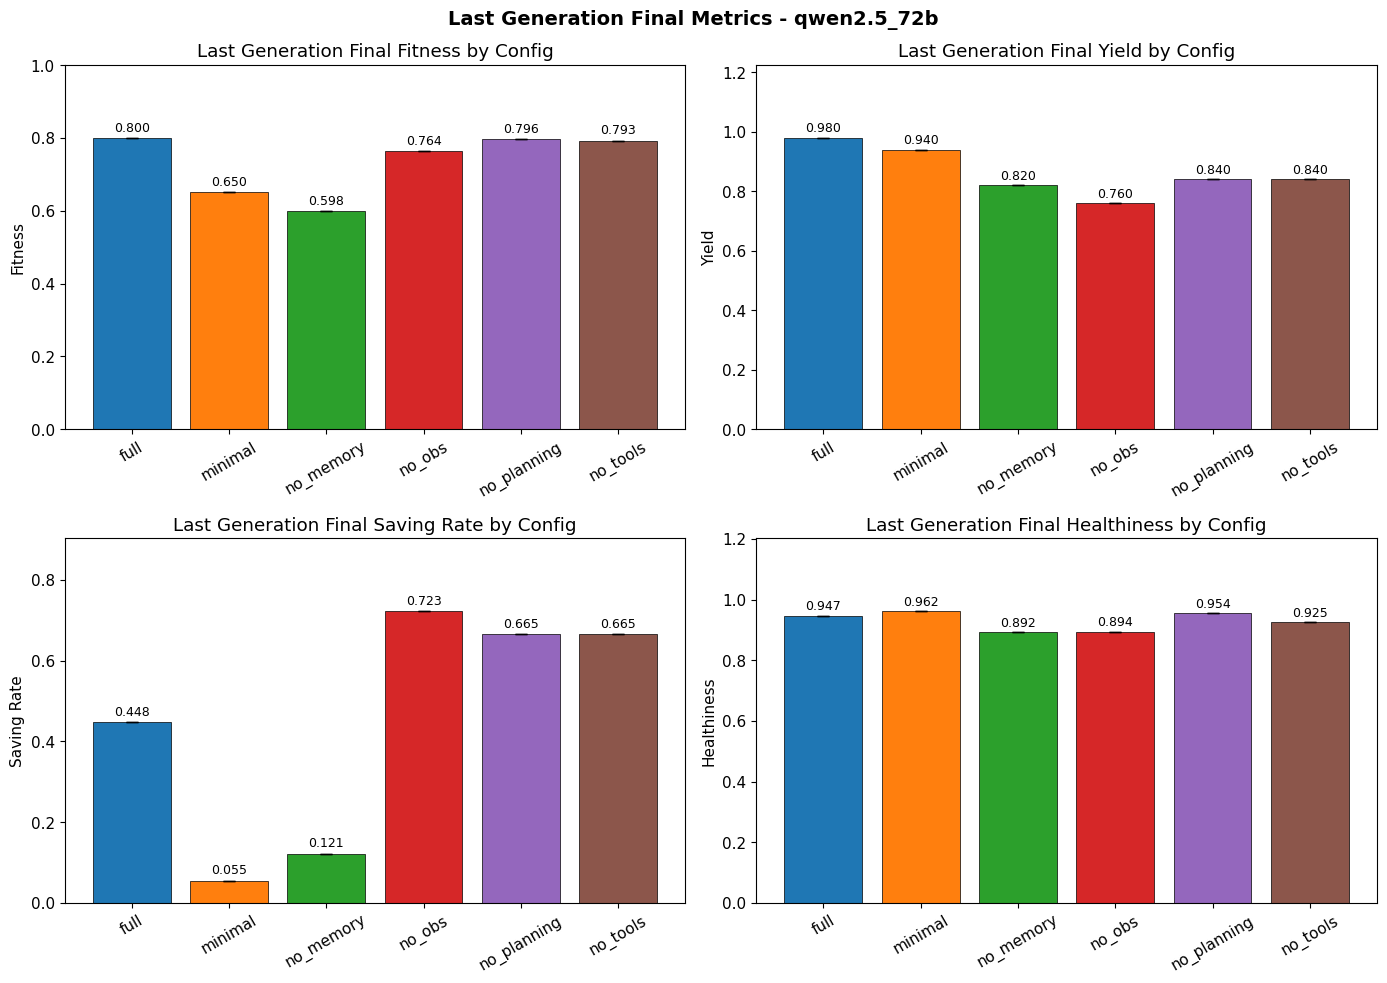

  Saved last_generation_bars.png


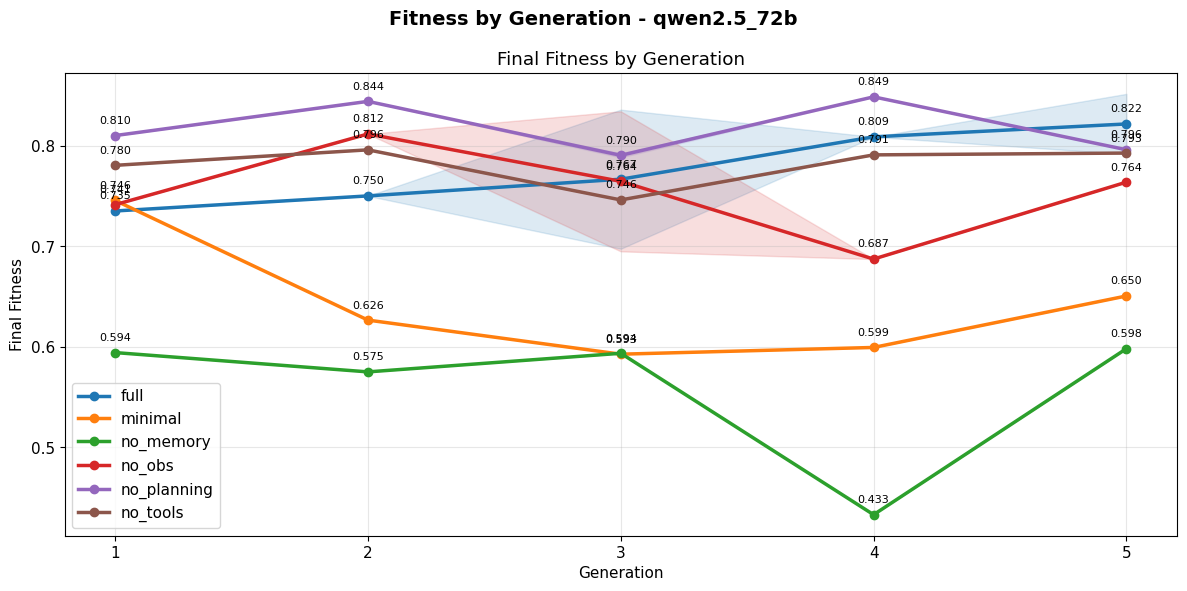

  Saved fitness_by_generation.png


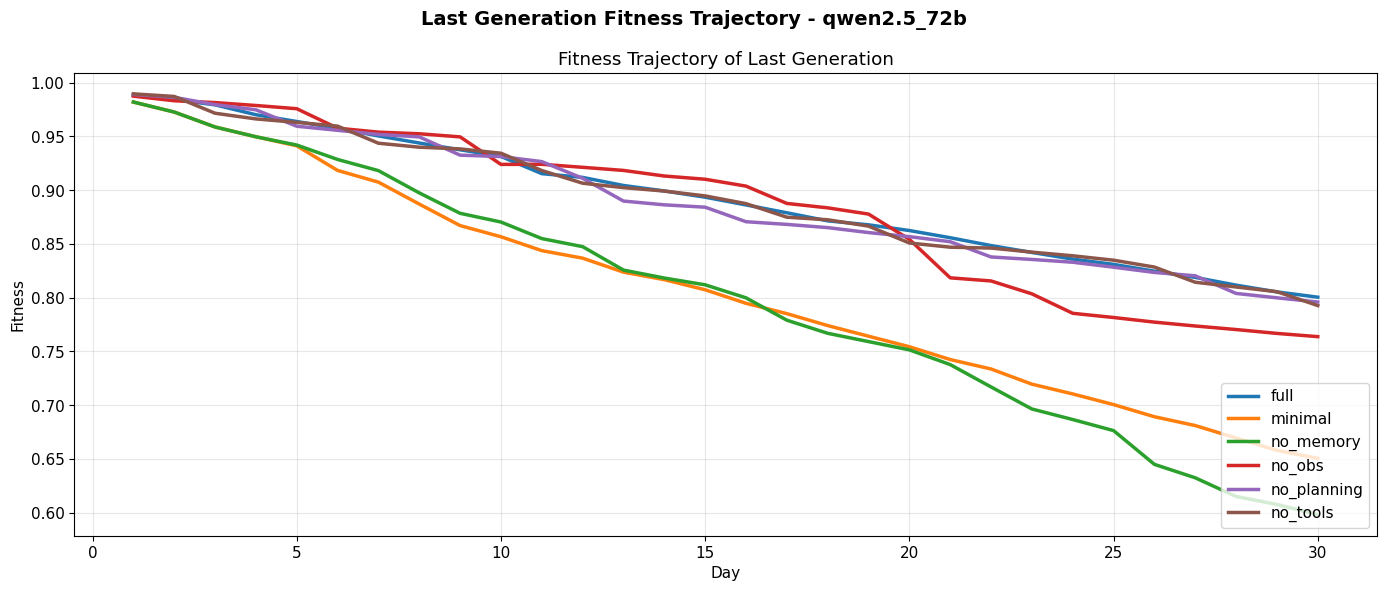

  Saved last_generation_trajectory.png


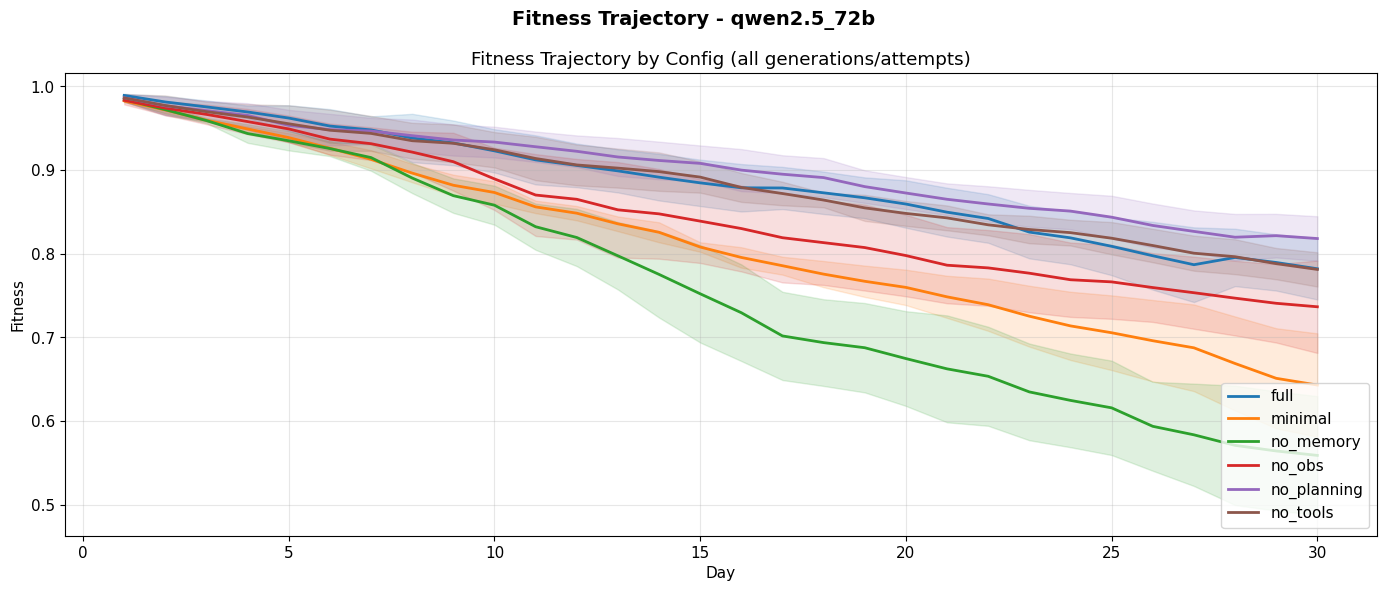

  Saved ablation_trajectories.png


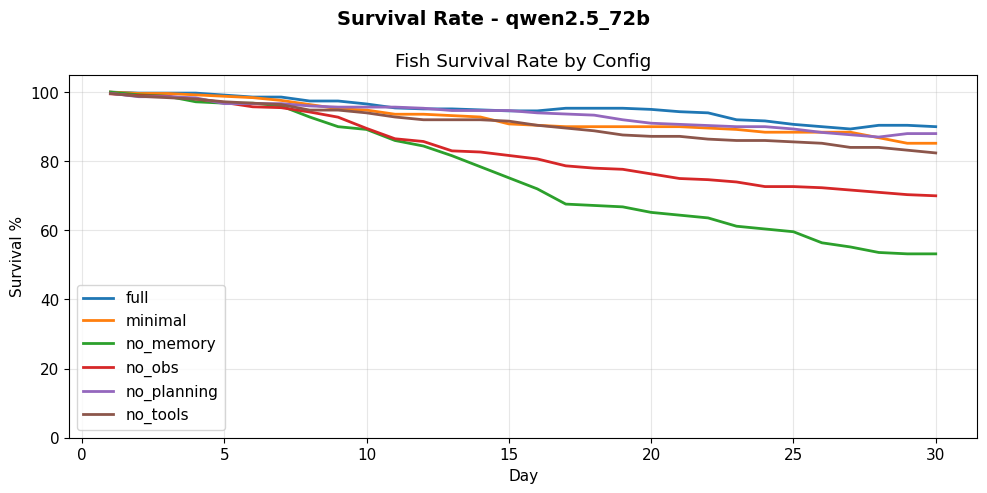

  Saved ablation_survival.png


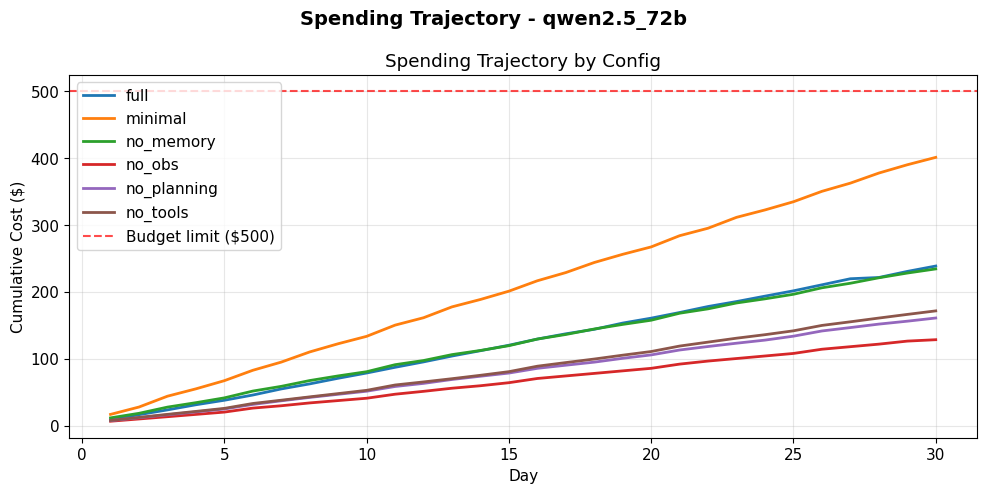

  Saved ablation_cost.png


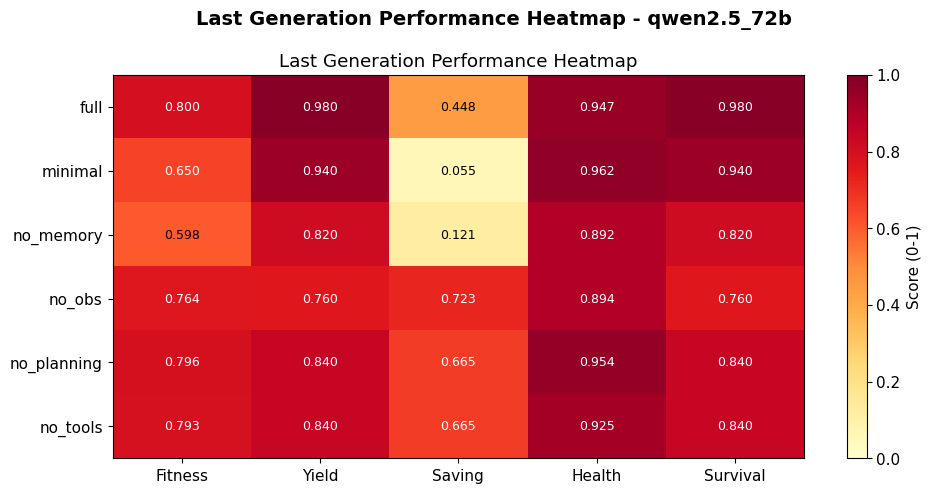

  Saved ablation_heatmap.png


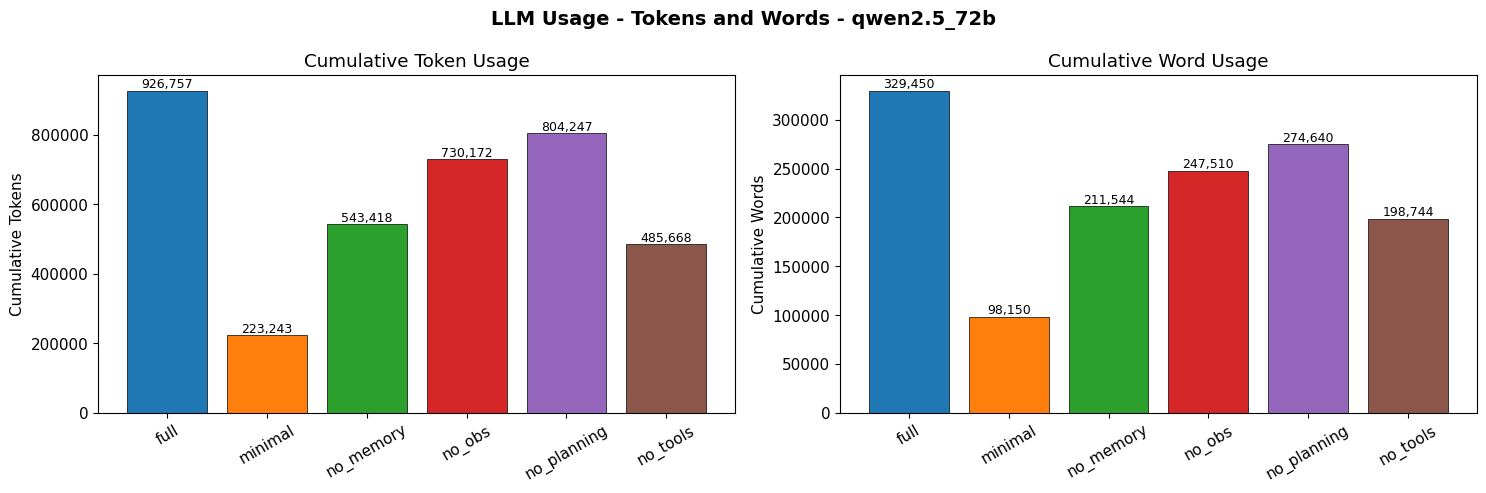

  Saved token_word_usage.png


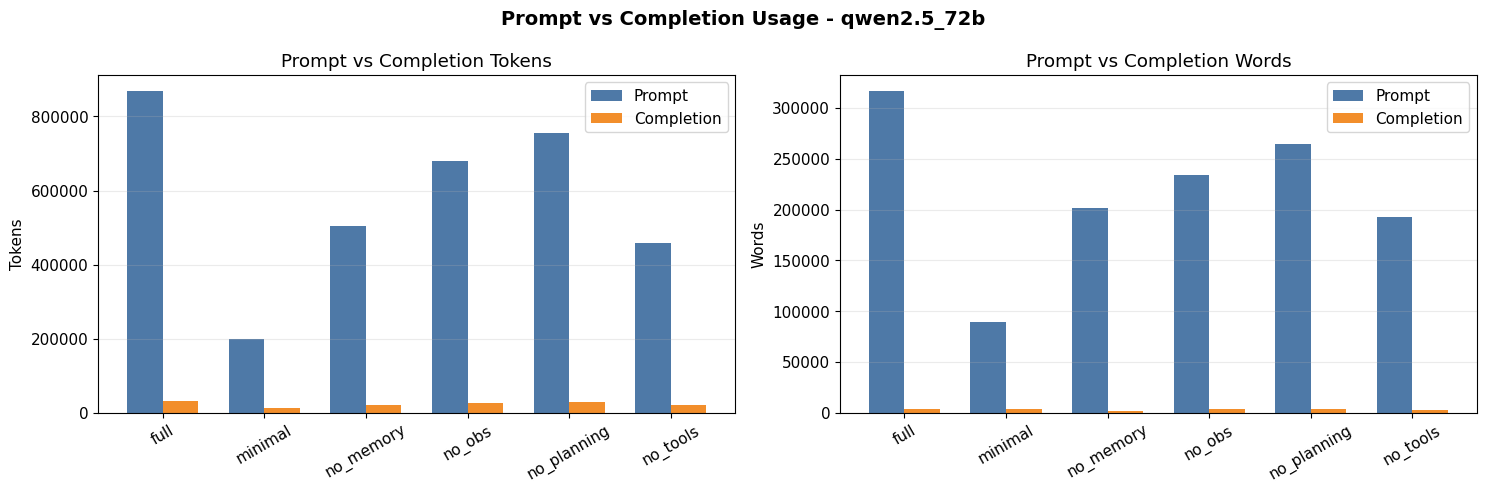

  Saved prompt_completion_usage.png


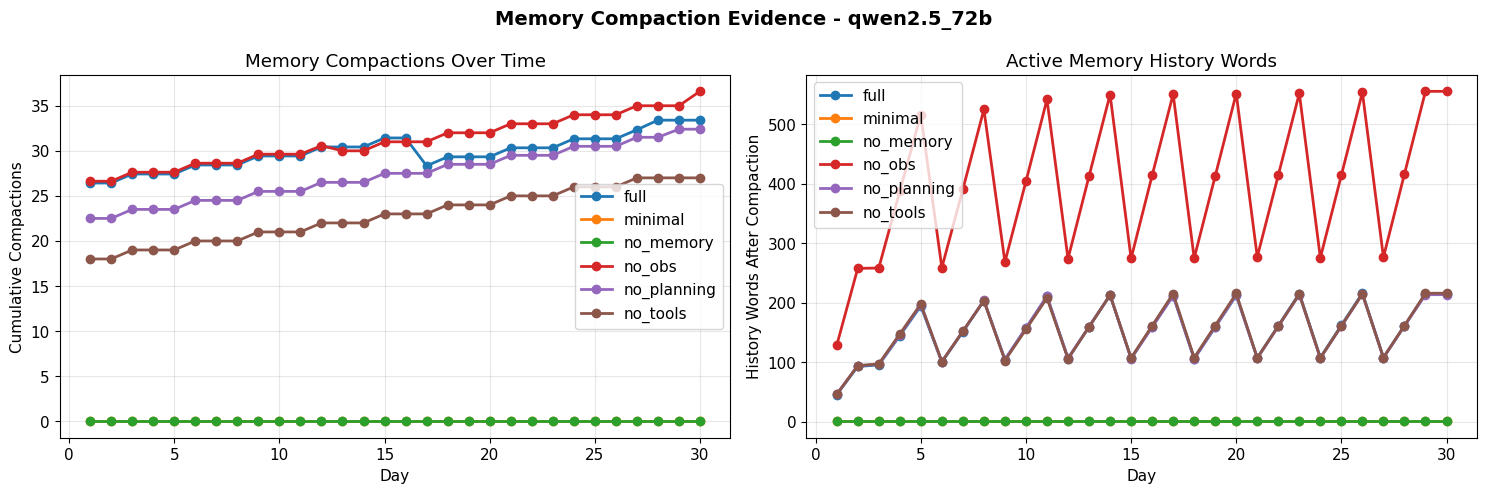

  Saved memory_compaction.png

  LAST GENERATION FINAL SUMMARY - qwen2.5_72b
            fitness             yield saving_ratio healthiness survival_pct    cost cumulative_tokens cumulative_words memory_compactions memory_history_words
               mean std     max  mean         mean        mean         mean    mean               max              max                max                 mean
config                                                                                                                                                        
full         0.8004 NaN  0.8004  0.98       0.4477      0.9471         98.0  276.15            926757           329450                 59                216.0
minimal      0.6505 NaN  0.6505  0.94       0.0550      0.9616         94.0  472.50            223243            98150                  0                  1.0
no_memory    0.5981 NaN  0.5981  0.82       0.1214      0.8920         82.0  439.30            543418           211544          

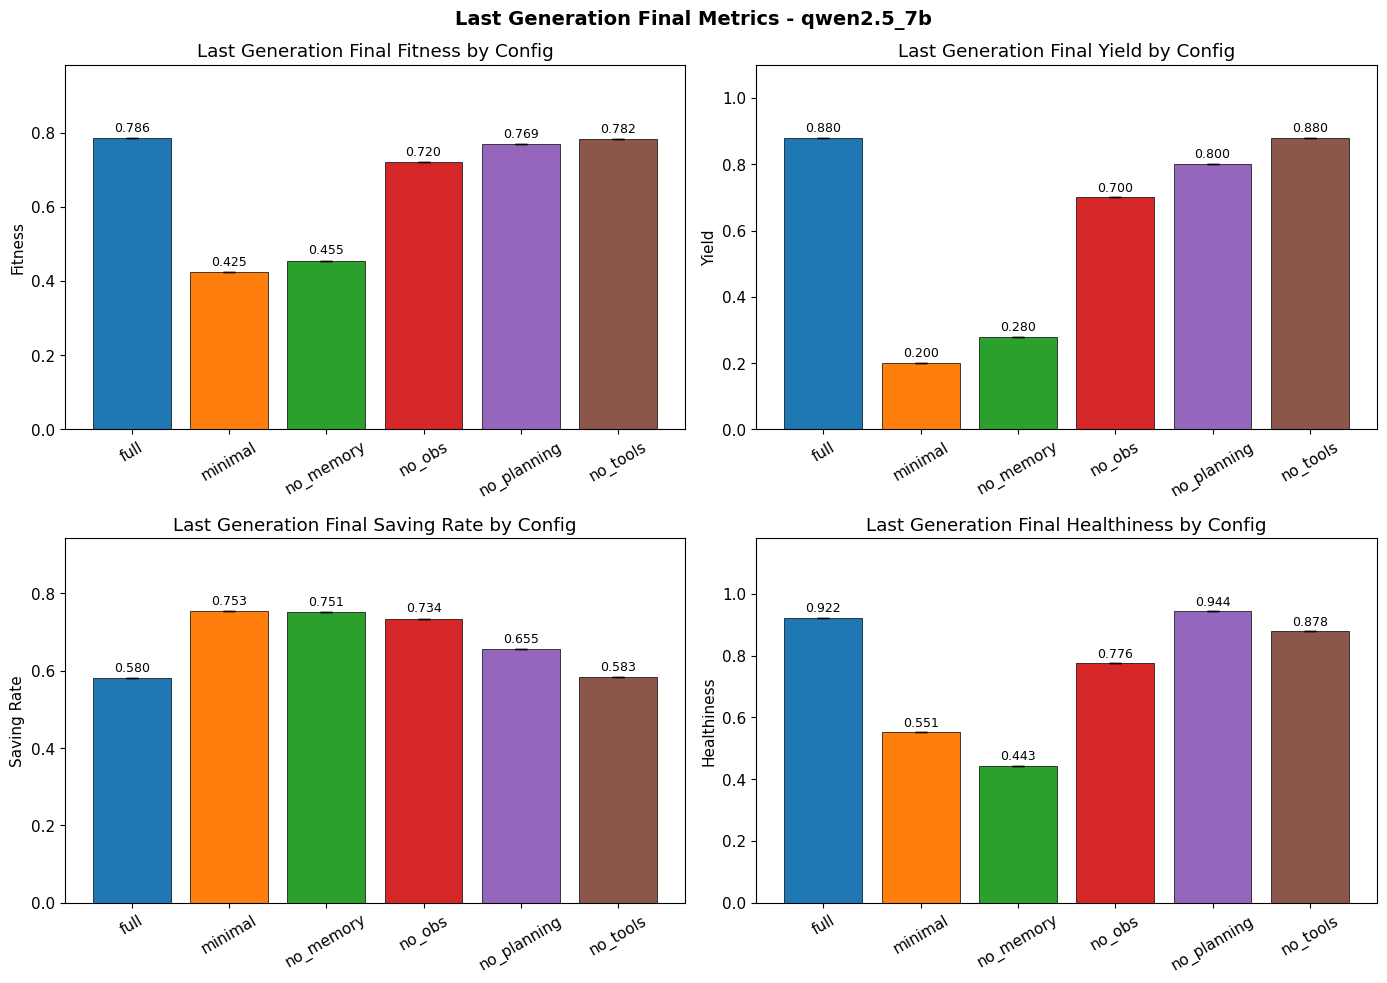

  Saved last_generation_bars.png


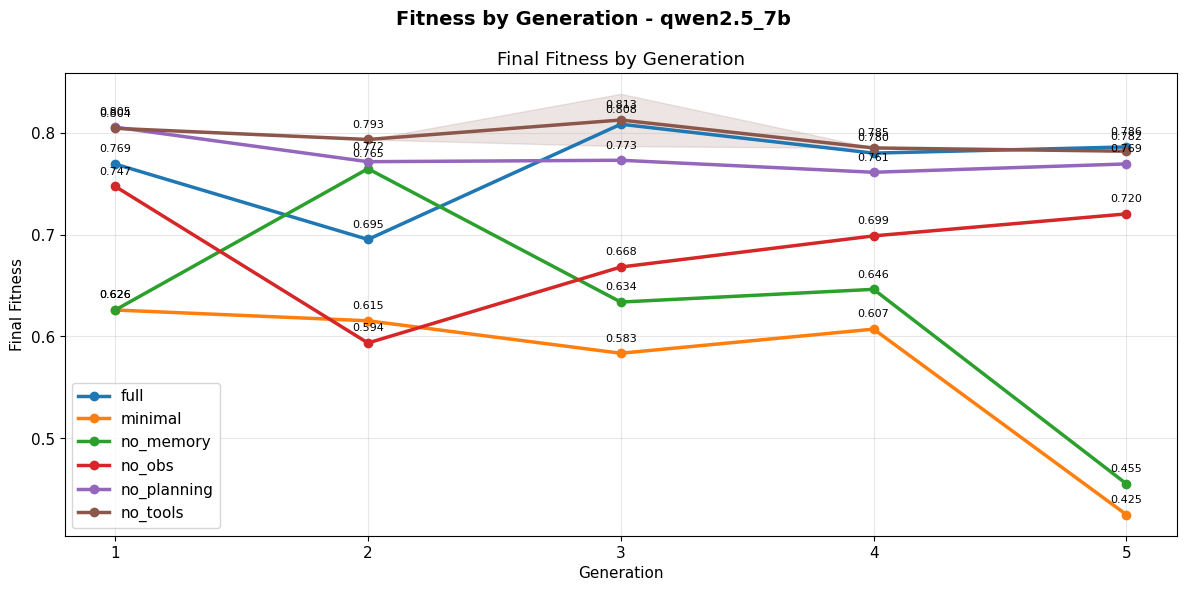

  Saved fitness_by_generation.png


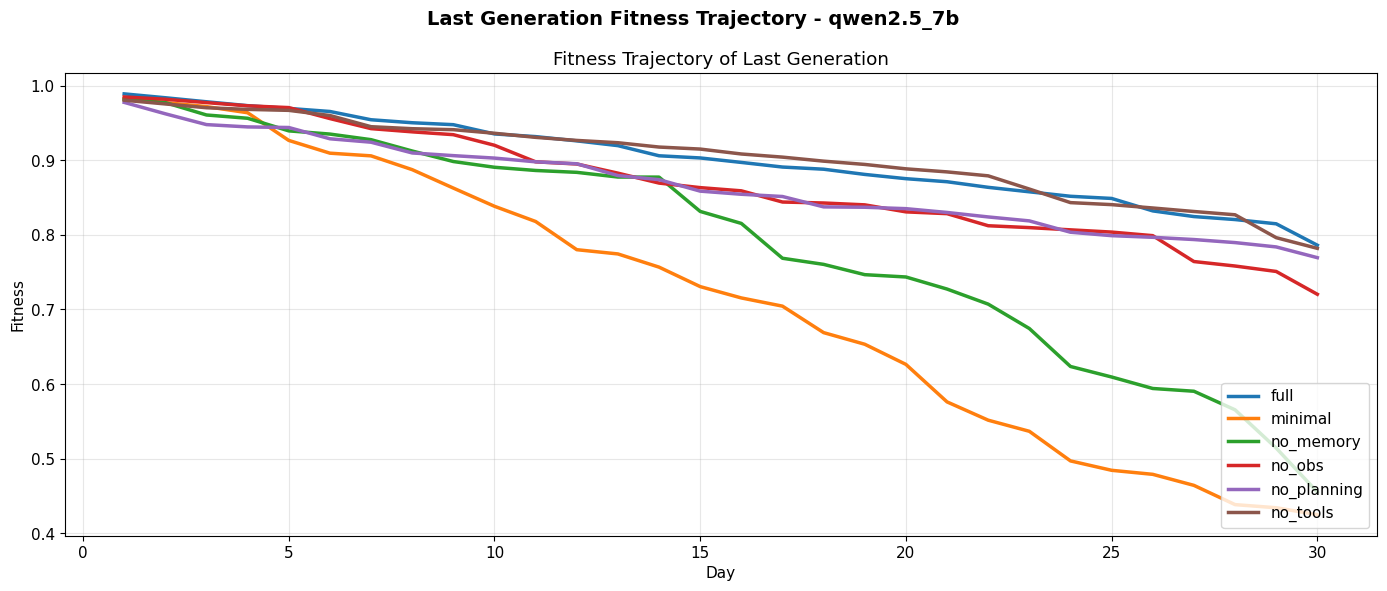

  Saved last_generation_trajectory.png


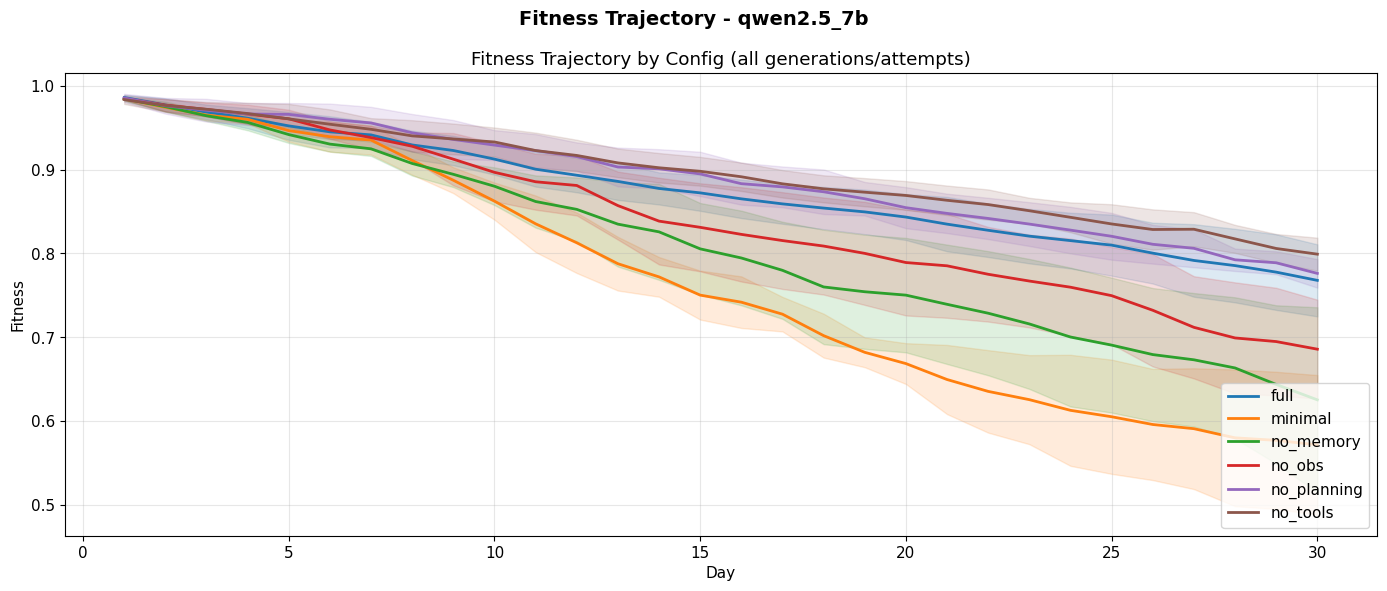

  Saved ablation_trajectories.png


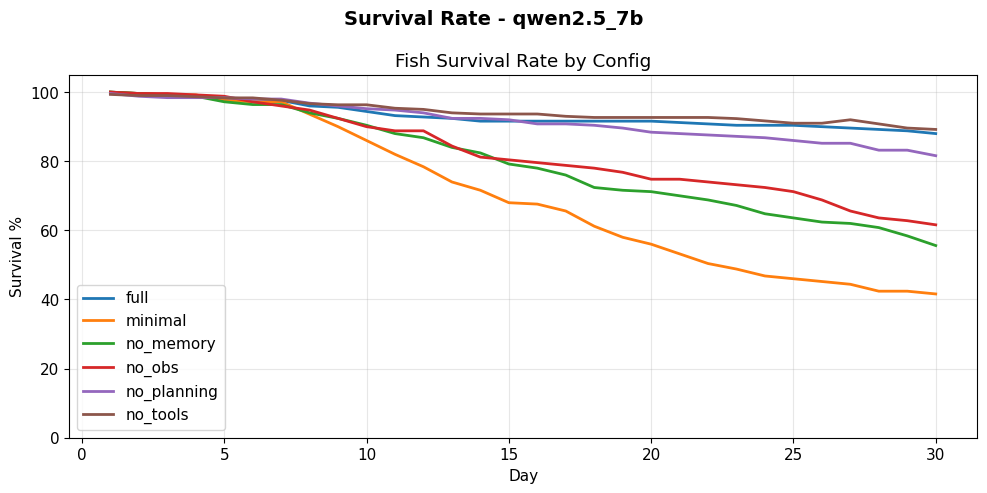

  Saved ablation_survival.png


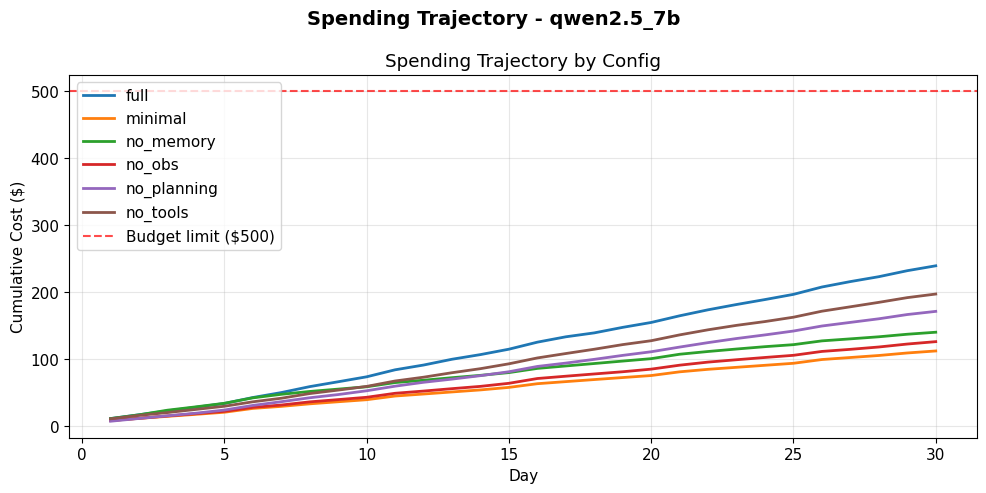

  Saved ablation_cost.png


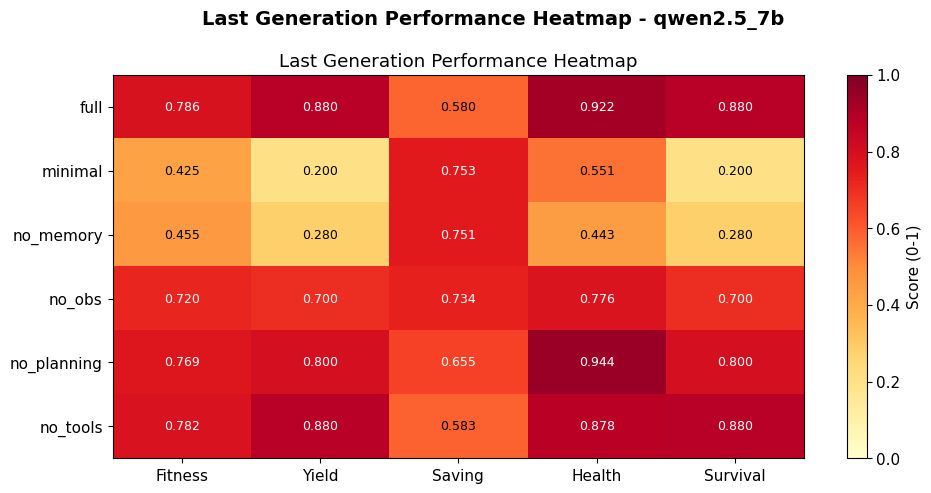

  Saved ablation_heatmap.png


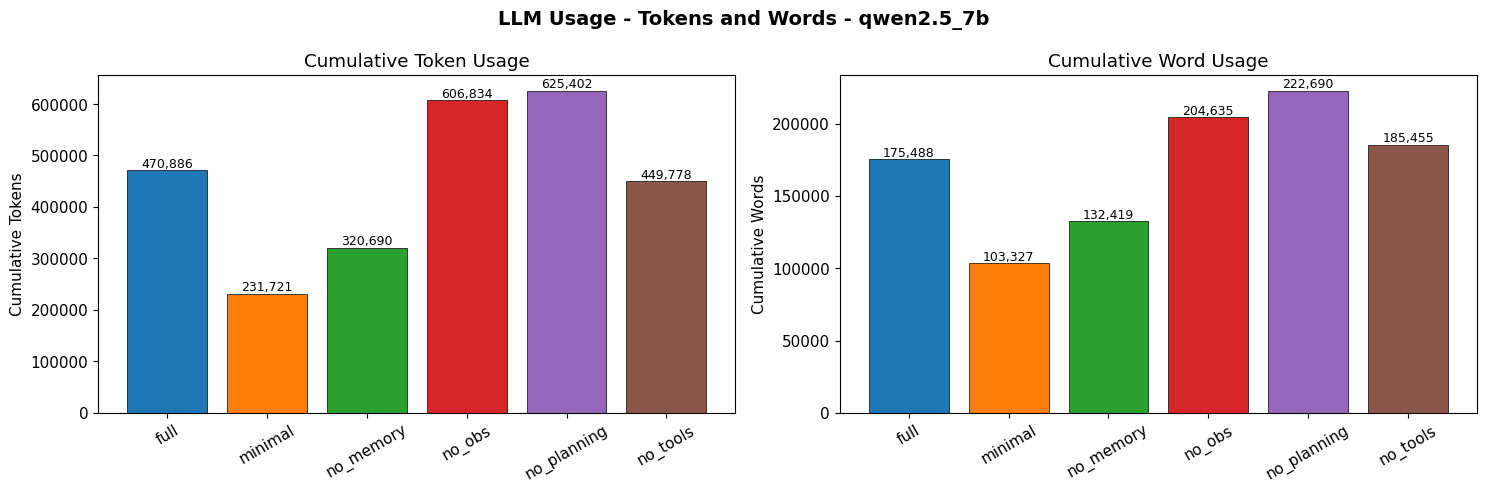

  Saved token_word_usage.png


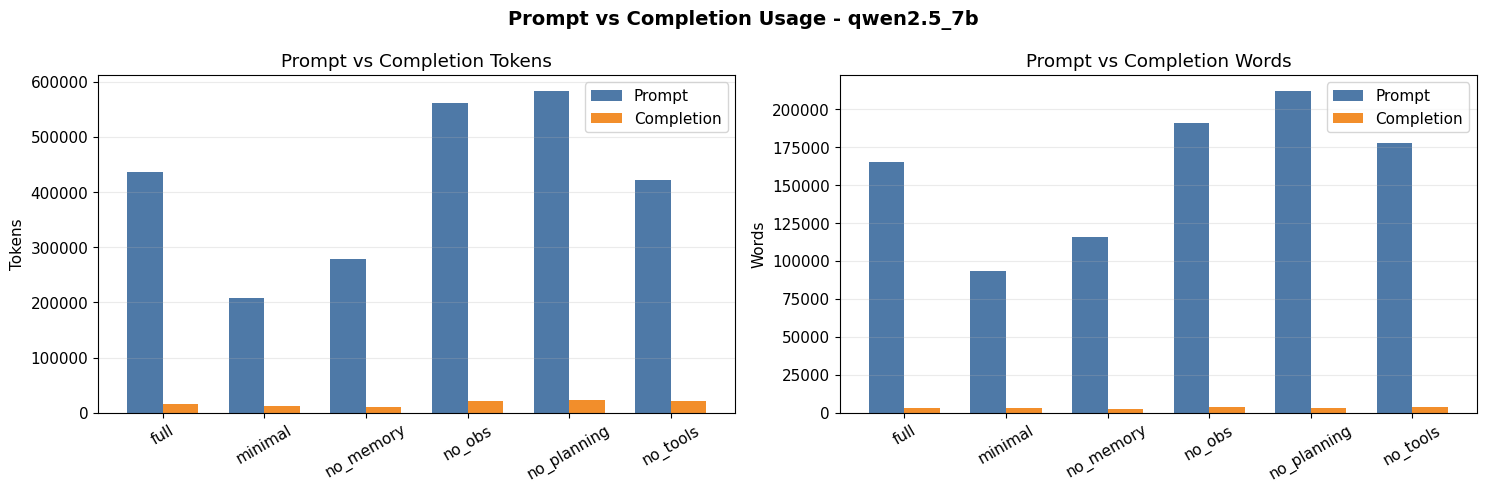

  Saved prompt_completion_usage.png


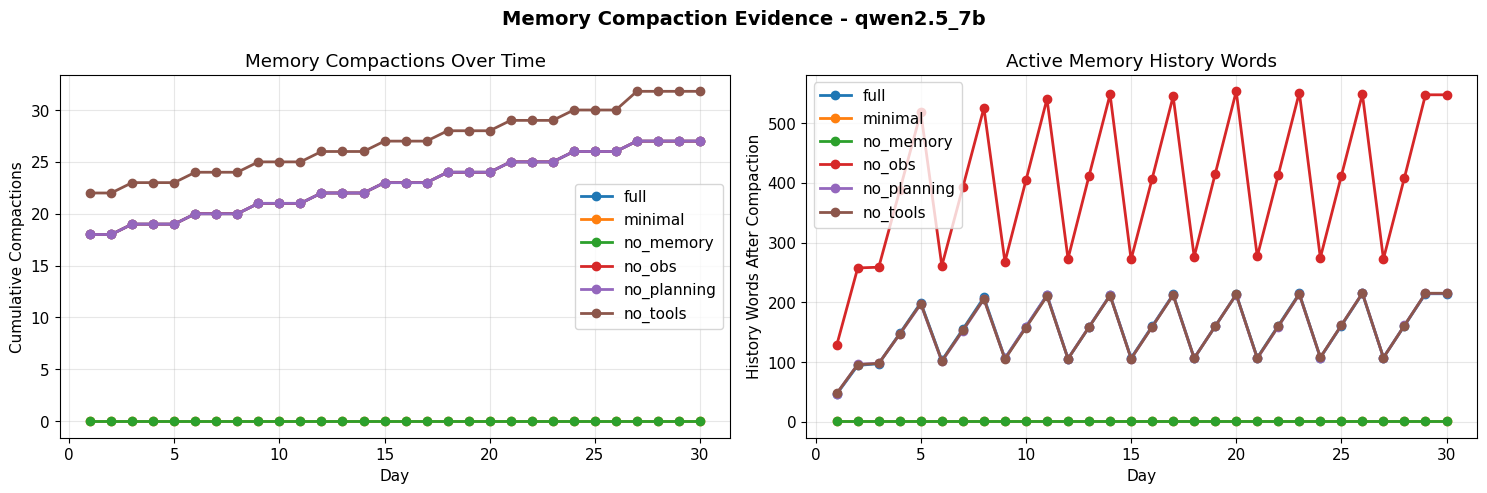

  Saved memory_compaction.png

  LAST GENERATION FINAL SUMMARY - qwen2.5_7b
            fitness             yield saving_ratio healthiness survival_pct    cost cumulative_tokens cumulative_words memory_compactions memory_history_words
               mean std     max  mean         mean        mean         mean    mean               max              max                max                 mean
config                                                                                                                                                        
full         0.7861 NaN  0.7861  0.88       0.5803      0.9220         88.0  209.85            470886           175488                 45                217.0
minimal      0.4248 NaN  0.4248  0.20       0.7534      0.5514         20.0  123.30            231721           103327                  0                  1.0
no_memory    0.4551 NaN  0.4551  0.28       0.7515      0.4426         28.0  124.25            320690           132419           

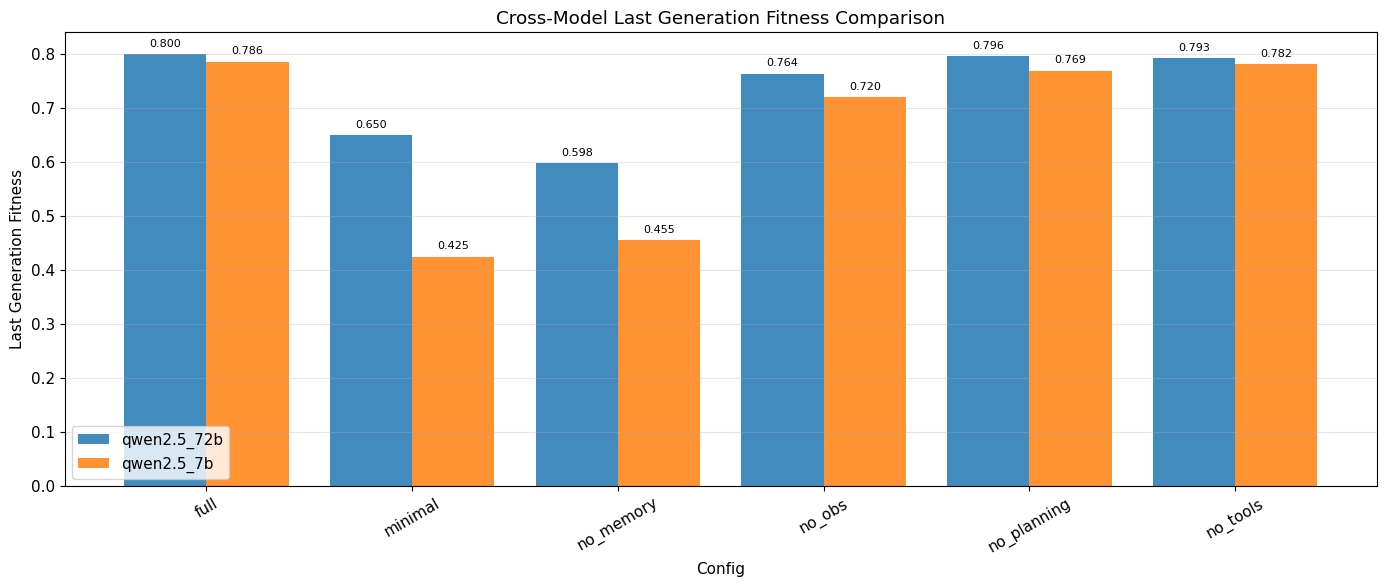

  Saved cross_model_last_generation_fitness.png
  Compressed: /content/AquaLLM/plots/plots_comparison.zip (70,267 bytes)

  plots_comparison.zip (70,267 bytes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  plots_qwen2.5_72b.zip (1,392,081 bytes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  plots_qwen2.5_7b.zip (1,276,039 bytes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All plots generated and downloaded.


In [488]:
# Cell 15: Ablation Analysis & Plots (per-model + compressed)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os, glob, zipfile

matplotlib.rcParams.update({'font.size': 11})

BASE_LOG_DIR = "/content/AquaLLM/logs"
BASE_PLOT_DIR = "/content/AquaLLM/plots"


def _compress_dir(dir_path, zip_path, extensions=None):
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for root, dirs, files in os.walk(dir_path):
            for fname in sorted(files):
                if extensions and not any(fname.endswith(ext) for ext in extensions):
                    continue
                fpath = os.path.join(root, fname)
                arcname = os.path.relpath(fpath, os.path.dirname(dir_path))
                zf.write(fpath, arcname)
    size = os.path.getsize(zip_path)
    print("  Compressed: {} ({:,} bytes)".format(zip_path, size))


def _numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def _generation_final(df):
    keys = ["config", "run", "generation"]
    if "attempt" in df.columns:
        keys.append("attempt")
    return df.sort_values(keys + ["day"]).groupby(keys, as_index=False).last()


def _last_generation_final(final):
    rows = []
    for (cfg, run), group in final.groupby(["config", "run"]):
        max_gen = group["generation"].max()
        g = group[group["generation"] == max_gen]

        if "attempt" in g.columns:
            max_attempt = g["attempt"].max()
            g = g[g["attempt"] == max_attempt]

        rows.append(g.sort_values("day").iloc[-1])
    return pd.DataFrame(rows).reset_index(drop=True)


def _last_generation_daily(df, last_final):
    parts = []
    for _, row in last_final.iterrows():
        mask = (
            (df["config"] == row["config"]) &
            (df["run"] == row["run"]) &
            (df["generation"] == row["generation"])
        )
        if "attempt" in df.columns and "attempt" in row:
            mask &= (df["attempt"] == row["attempt"])
        parts.append(df[mask].copy())
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, ignore_index=True)


def _safe_mean(df, cfg, col):
    if col not in df.columns:
        return 0
    vals = df[df["config"] == cfg][col].astype(float)
    return vals.mean() if len(vals) else 0


def _safe_max(df, cfg, col):
    if col not in df.columns:
        return 0
    vals = df[df["config"] == cfg][col].astype(float)
    return vals.max() if len(vals) else 0


def _safe_sum(df, cfg, col):
    if col not in df.columns:
        return 0
    vals = df[df["config"] == cfg][col].astype(float)
    return vals.sum() if len(vals) else 0


def generate_plots_for_model(model_dir_name, csv_path, plot_dir):
    os.makedirs(plot_dir, exist_ok=True)

    if not os.path.exists(csv_path):
        print("  No CSV found at {}. Skipping.".format(csv_path))
        return None

    df = pd.read_csv(csv_path)

    numeric_cols = [
        "run", "generation", "attempt", "day",
        "fitness", "yield", "saving_ratio", "healthiness",
        "survival_pct", "alive_count", "initial_count", "deaths_today",
        "cost", "saving",
        "food_interval", "food_quantity", "food_location",
        "probiotic_interval", "probiotic_quantity", "probiotic_location",
        "oxygen_interval", "oxygen_duration", "oxygen_location",
        "prompt_tokens", "completion_tokens", "cumulative_tokens",
        "prompt_words", "completion_words", "cumulative_words",
        "memory_compactions", "last_compaction_day",
        "memory_entries", "memory_history_words",
    ]
    df = _numeric(df, numeric_cols)

    print("\n  Loaded {} rows from {}".format(len(df), csv_path))
    print("  Configs: {}".format(df["config"].unique().tolist()))
    print("  Generations: {}".format(sorted(df["generation"].dropna().unique())))

    configs = sorted(df["config"].unique())
    cmap = plt.cm.tab10
    CONFIG_COLORS = {cfg: cmap(i) for i, cfg in enumerate(configs)}

    final = _generation_final(df)
    last_final = _last_generation_final(final)
    last_daily = _last_generation_daily(df, last_final)

    print("\n  LAST GENERATION FINAL PER CONFIG/RUN:")
    show_cols = ["config", "run", "generation"]
    if "attempt" in last_final.columns:
        show_cols.append("attempt")
    show_cols += ["fitness", "yield", "saving_ratio", "healthiness", "survival_pct", "cost"]
    print(last_final[show_cols].round(4).to_string(index=False))

    # 1. Last generation final metrics
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Last Generation Final Metrics - {}".format(model_dir_name), fontsize=14, fontweight='bold')
    axes = axes.flatten()

    for idx, metric, label in [
        (0, "fitness", "Fitness"),
        (1, "yield", "Yield"),
        (2, "saving_ratio", "Saving Rate"),
        (3, "healthiness", "Healthiness"),
    ]:
        ax = axes[idx]
        means = [_safe_mean(last_final, c, metric) for c in configs]
        stds = [
            last_final[last_final["config"] == c][metric].astype(float).std()
            if metric in last_final.columns else 0
            for c in configs
        ]
        stds = [0 if pd.isna(s) else s for s in stds]

        bars = ax.bar(
            configs, means, yerr=stds, capsize=4,
            color=[CONFIG_COLORS[c] for c in configs],
            edgecolor="black", linewidth=0.5,
        )
        ax.set_ylabel(label)
        ax.set_title("Last Generation Final {} by Config".format(label))
        ax.set_ylim(0, max(means) * 1.25 if max(means) > 0 else 1)
        for bar, m in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    "{:.3f}".format(m), ha="center", va="bottom", fontsize=9)
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "last_generation_bars.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved last_generation_bars.png")

    # 2. Fitness by generation
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle("Fitness by Generation - {}".format(model_dir_name), fontsize=14, fontweight='bold')

    gen_summary = final.groupby(["config", "generation"])["fitness"].agg(["mean", "std"]).reset_index()
    for cfg in configs:
        cfg_df = gen_summary[gen_summary["config"] == cfg].sort_values("generation")
        gens = cfg_df["generation"].astype(int)
        means = cfg_df["mean"].astype(float)
        stds = cfg_df["std"].astype(float).fillna(0)
        ax.plot(gens, means, marker="o", linewidth=2.5, label=cfg, color=CONFIG_COLORS[cfg])
        ax.fill_between(gens, means - stds, means + stds, color=CONFIG_COLORS[cfg], alpha=0.15)

        for x, y in zip(gens, means):
            ax.text(x, y + 0.01, "{:.3f}".format(y), ha="center", va="bottom", fontsize=8)

    ax.set_xlabel("Generation")
    ax.set_ylabel("Final Fitness")
    ax.set_title("Final Fitness by Generation")
    ax.set_xticks(sorted(final["generation"].dropna().unique().astype(int)))
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "fitness_by_generation.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved fitness_by_generation.png")

    # 3. Last generation trajectory
    if not last_daily.empty:
        fig, ax = plt.subplots(figsize=(14, 6))
        fig.suptitle("Last Generation Fitness Trajectory - {}".format(model_dir_name), fontsize=14, fontweight='bold')

        for cfg in configs:
            cfg_df = last_daily[last_daily["config"] == cfg]
            daily_mean = cfg_df.groupby("day")["fitness"].mean().astype(float)
            daily_std = cfg_df.groupby("day")["fitness"].std().astype(float).fillna(0)
            days = daily_mean.index
            ax.plot(days, daily_mean, label=cfg, color=CONFIG_COLORS[cfg], linewidth=2.5)
            ax.fill_between(days, daily_mean - daily_std, daily_mean + daily_std,
                            alpha=0.15, color=CONFIG_COLORS[cfg])

        ax.set_xlabel("Day")
        ax.set_ylabel("Fitness")
        ax.set_title("Fitness Trajectory of Last Generation")
        ax.legend(loc="lower right")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(plot_dir, "last_generation_trajectory.png"), dpi=150, bbox_inches="tight")
        plt.show()
        print("  Saved last_generation_trajectory.png")

    # 4. All-generation fitness trajectory
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.suptitle("Fitness Trajectory - {}".format(model_dir_name), fontsize=14, fontweight='bold')

    for cfg in configs:
        cfg_df = df[df["config"] == cfg]
        daily_mean = cfg_df.groupby("day")["fitness"].mean().astype(float)
        daily_std = cfg_df.groupby("day")["fitness"].std().astype(float).fillna(0)
        days = daily_mean.index
        ax.plot(days, daily_mean, label=cfg, color=CONFIG_COLORS[cfg], linewidth=2)
        ax.fill_between(days, daily_mean - daily_std, daily_mean + daily_std,
                        alpha=0.15, color=CONFIG_COLORS[cfg])

    ax.set_xlabel("Day")
    ax.set_ylabel("Fitness")
    ax.set_title("Fitness Trajectory by Config (all generations/attempts)")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "ablation_trajectories.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved ablation_trajectories.png")

    # 5. Survival
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle("Survival Rate - {}".format(model_dir_name), fontsize=14, fontweight='bold')

    for cfg in configs:
        cfg_df = df[df["config"] == cfg]
        daily_surv = cfg_df.groupby("day")["survival_pct"].mean().astype(float)
        ax.plot(daily_surv.index, daily_surv, label=cfg, color=CONFIG_COLORS[cfg], linewidth=2)

    ax.set_xlabel("Day")
    ax.set_ylabel("Survival %")
    ax.set_title("Fish Survival Rate by Config")
    ax.legend(loc="lower left")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "ablation_survival.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved ablation_survival.png")

    # 6. Cost
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle("Spending Trajectory - {}".format(model_dir_name), fontsize=14, fontweight='bold')

    for cfg in configs:
        cfg_df = df[df["config"] == cfg]
        daily_cost = cfg_df.groupby("day")["cost"].mean().astype(float)
        ax.plot(daily_cost.index, daily_cost, label=cfg, color=CONFIG_COLORS[cfg], linewidth=2)

    ax.axhline(y=500, color="red", linestyle="--", alpha=0.7, label="Budget limit ($500)")
    ax.set_xlabel("Day")
    ax.set_ylabel("Cumulative Cost ($)")
    ax.set_title("Spending Trajectory by Config")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "ablation_cost.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved ablation_cost.png")

    # 7. Last-generation heatmap
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle("Last Generation Performance Heatmap - {}".format(model_dir_name), fontsize=14, fontweight='bold')

    components = ["fitness", "yield", "saving_ratio", "healthiness", "survival_pct"]
    comp_labels = ["Fitness", "Yield", "Saving", "Health", "Survival"]

    matrix = []
    for cfg in configs:
        row = []
        for comp in components:
            val = _safe_mean(last_final, cfg, comp)
            if comp == "survival_pct":
                val /= 100
            row.append(val)
        matrix.append(row)

    matrix = np.array(matrix)
    im = ax.imshow(matrix, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(comp_labels)))
    ax.set_xticklabels(comp_labels)
    ax.set_yticks(range(len(configs)))
    ax.set_yticklabels(configs)
    for i in range(len(configs)):
        for j in range(len(comp_labels)):
            ax.text(j, i, "{:.3f}".format(matrix[i, j]),
                    ha="center", va="center", fontsize=9,
                    color="white" if matrix[i, j] > 0.6 else "black")
    plt.colorbar(im, ax=ax, label="Score (0-1)")
    ax.set_title("Last Generation Performance Heatmap")
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "ablation_heatmap.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved ablation_heatmap.png")

    # 8. Token and word usage totals
    has_token_word_cols = any(c in df.columns for c in [
        "cumulative_tokens", "cumulative_words", "prompt_tokens",
        "completion_tokens", "prompt_words", "completion_words",
    ])

    if has_token_word_cols:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle("LLM Usage - Tokens and Words - {}".format(model_dir_name),
                     fontsize=14, fontweight='bold')

        token_totals = [_safe_max(df, c, "cumulative_tokens") for c in configs]
        word_totals = [_safe_max(df, c, "cumulative_words") for c in configs]

        bars1 = axes[0].bar(configs, token_totals, color=[CONFIG_COLORS[c] for c in configs],
                            edgecolor="black", linewidth=0.5)
        axes[0].set_ylabel("Cumulative Tokens")
        axes[0].set_title("Cumulative Token Usage")
        axes[0].tick_params(axis='x', rotation=30)
        for bar, val in zip(bars1, token_totals):
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                         "{:,.0f}".format(val), ha="center", va="bottom", fontsize=9)

        bars2 = axes[1].bar(configs, word_totals, color=[CONFIG_COLORS[c] for c in configs],
                            edgecolor="black", linewidth=0.5)
        axes[1].set_ylabel("Cumulative Words")
        axes[1].set_title("Cumulative Word Usage")
        axes[1].tick_params(axis='x', rotation=30)
        for bar, val in zip(bars2, word_totals):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                         "{:,.0f}".format(val), ha="center", va="bottom", fontsize=9)

        plt.tight_layout()
        plt.savefig(os.path.join(plot_dir, "token_word_usage.png"), dpi=150, bbox_inches="tight")
        plt.show()
        print("  Saved token_word_usage.png")

        # Prompt vs completion totals
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle("Prompt vs Completion Usage - {}".format(model_dir_name),
                     fontsize=14, fontweight='bold')

        x = np.arange(len(configs))
        width = 0.35

        prompt_tok = [_safe_sum(df, c, "prompt_tokens") for c in configs]
        completion_tok = [_safe_sum(df, c, "completion_tokens") for c in configs]
        prompt_words = [_safe_sum(df, c, "prompt_words") for c in configs]
        completion_words = [_safe_sum(df, c, "completion_words") for c in configs]

        axes[0].bar(x - width/2, prompt_tok, width, label="Prompt", color="#4e79a7")
        axes[0].bar(x + width/2, completion_tok, width, label="Completion", color="#f28e2b")
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(configs, rotation=30)
        axes[0].set_ylabel("Tokens")
        axes[0].set_title("Prompt vs Completion Tokens")
        axes[0].legend()
        axes[0].grid(True, alpha=0.25, axis="y")

        axes[1].bar(x - width/2, prompt_words, width, label="Prompt", color="#4e79a7")
        axes[1].bar(x + width/2, completion_words, width, label="Completion", color="#f28e2b")
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(configs, rotation=30)
        axes[1].set_ylabel("Words")
        axes[1].set_title("Prompt vs Completion Words")
        axes[1].legend()
        axes[1].grid(True, alpha=0.25, axis="y")

        plt.tight_layout()
        plt.savefig(os.path.join(plot_dir, "prompt_completion_usage.png"), dpi=150, bbox_inches="tight")
        plt.show()
        print("  Saved prompt_completion_usage.png")

    # 9. Memory compaction evidence
    if "memory_compactions" in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle("Memory Compaction Evidence - {}".format(model_dir_name),
                     fontsize=14, fontweight='bold')

        for cfg in configs:
            cfg_df = df[df["config"] == cfg].copy()
            group_cols = ["generation", "attempt", "day"] if "attempt" in cfg_df.columns else ["generation", "day"]

            compact_by_day = cfg_df.groupby(group_cols)["memory_compactions"].max().reset_index()
            compact_mean = compact_by_day.groupby("day")["memory_compactions"].mean()

            axes[0].plot(compact_mean.index, compact_mean.values,
                         marker="o", label=cfg, color=CONFIG_COLORS[cfg], linewidth=2)

            if "memory_history_words" in cfg_df.columns:
                words_by_day = cfg_df.groupby(group_cols)["memory_history_words"].max().reset_index()
                words_mean = words_by_day.groupby("day")["memory_history_words"].mean()
                axes[1].plot(words_mean.index, words_mean.values,
                             marker="o", label=cfg, color=CONFIG_COLORS[cfg], linewidth=2)

        axes[0].set_xlabel("Day")
        axes[0].set_ylabel("Cumulative Compactions")
        axes[0].set_title("Memory Compactions Over Time")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        axes[1].set_xlabel("Day")
        axes[1].set_ylabel("History Words After Compaction")
        axes[1].set_title("Active Memory History Words")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        plt.tight_layout()
        plt.savefig(os.path.join(plot_dir, "memory_compaction.png"), dpi=150, bbox_inches="tight")
        plt.show()
        print("  Saved memory_compaction.png")

    # Summary tables
    print("\n" + "=" * 90)
    print("  LAST GENERATION FINAL SUMMARY - {}".format(model_dir_name))
    print("=" * 90)

    agg_dict = {
        "fitness": ["mean", "std", "max"],
        "yield": "mean",
        "saving_ratio": "mean",
        "healthiness": "mean",
        "survival_pct": "mean",
        "cost": "mean",
    }
    if "cumulative_tokens" in last_final.columns:
        agg_dict["cumulative_tokens"] = "max"
    if "cumulative_words" in last_final.columns:
        agg_dict["cumulative_words"] = "max"
    if "memory_compactions" in last_final.columns:
        agg_dict["memory_compactions"] = "max"
    if "memory_history_words" in last_final.columns:
        agg_dict["memory_history_words"] = "mean"

    summary = last_final.groupby("config").agg(agg_dict).round(4)
    print(summary.to_string())

    print("\n  RANKING BY LAST GENERATION FINAL FITNESS:")
    ranking = last_final.groupby("config")["fitness"].mean().astype(float).sort_values(ascending=False)
    for rank, (cfg, fit) in enumerate(ranking.items(), 1):
        print("    {}. {} - {:.4f}".format(rank, cfg, fit))

    print("\n" + "=" * 90)
    print("  TOKEN / WORD / COMPACTION SUMMARY - {}".format(model_dir_name))
    print("=" * 90)

    usage_rows = []
    for cfg in configs:
        row = {
            "config": cfg,
            "cumulative_tokens": _safe_max(df, cfg, "cumulative_tokens"),
            "cumulative_words": _safe_max(df, cfg, "cumulative_words"),
            "prompt_tokens_sum": _safe_sum(df, cfg, "prompt_tokens"),
            "completion_tokens_sum": _safe_sum(df, cfg, "completion_tokens"),
            "prompt_words_sum": _safe_sum(df, cfg, "prompt_words"),
            "completion_words_sum": _safe_sum(df, cfg, "completion_words"),
            "memory_compactions": _safe_max(df, cfg, "memory_compactions"),
            "final_memory_history_words": _safe_max(last_final, cfg, "memory_history_words"),
        }
        usage_rows.append(row)

    usage_df = pd.DataFrame(usage_rows)
    print(usage_df.round(2).to_string(index=False))

    print("\n" + "=" * 90)
    print("  FITNESS BY GENERATION SUMMARY - {}".format(model_dir_name))
    print("=" * 90)
    gen_table = final.groupby(["config", "generation"])["fitness"].agg(["mean", "std", "max"]).round(4)
    print(gen_table.to_string())

    return df


model_dfs = {}

model_dirs = sorted(glob.glob("{}/*/".format(BASE_LOG_DIR)))
if not model_dirs:
    legacy_csv = "{}/llm_results.csv".format(BASE_LOG_DIR)
    if os.path.exists(legacy_csv):
        model_dirs = [BASE_LOG_DIR + "/"]

for model_dir in model_dirs:
    model_dir = model_dir.rstrip("/")
    model_dir_name = os.path.basename(model_dir)

    csv_path = os.path.join(model_dir, "llm_results.csv")
    if not os.path.exists(csv_path):
        continue

    plot_dir = os.path.join(BASE_PLOT_DIR, model_dir_name)

    print("\n" + "=" * 70)
    print("  GENERATING PLOTS FOR: {}".format(model_dir_name))
    print("=" * 70)

    df = generate_plots_for_model(model_dir_name, csv_path, plot_dir)
    if df is not None:
        model_dfs[model_dir_name] = df

    plots_zip = "{}/plots_{}.zip".format(BASE_PLOT_DIR, model_dir_name)
    _compress_dir(plot_dir, plots_zip, extensions=[".png"])

# Cross-model comparison
if len(model_dfs) > 1:
    print("\n" + "=" * 70)
    print("  CROSS-MODEL COMPARISON")
    print("=" * 70)

    comparison_plot_dir = os.path.join(BASE_PLOT_DIR, "comparison")
    os.makedirs(comparison_plot_dir, exist_ok=True)

    model_names = sorted(model_dfs.keys())

    last_by_model = {}
    all_configs = set()
    for model_name, df in model_dfs.items():
        final = _generation_final(df)
        last_final = _last_generation_final(final)
        last_by_model[model_name] = last_final
        all_configs.update(last_final["config"].unique())
    all_configs = sorted(all_configs)

    fig, ax = plt.subplots(figsize=(14, 6))
    bar_width = 0.8 / len(model_names)
    x = np.arange(len(all_configs))

    for i, model_name in enumerate(model_names):
        last_final = last_by_model[model_name]
        means = [
            _safe_mean(last_final, c, "fitness")
            if c in last_final["config"].values else 0
            for c in all_configs
        ]
        bars = ax.bar(x + i * bar_width, means, bar_width, label=model_name, alpha=0.85)
        for bar, m in zip(bars, means):
            if m > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        "{:.3f}".format(m), ha="center", va="bottom", fontsize=8)

    ax.set_xlabel("Config")
    ax.set_ylabel("Last Generation Fitness")
    ax.set_title("Cross-Model Last Generation Fitness Comparison")
    ax.set_xticks(x + bar_width * (len(model_names) - 1) / 2)
    ax.set_xticklabels(all_configs, rotation=30)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(comparison_plot_dir, "cross_model_last_generation_fitness.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved cross_model_last_generation_fitness.png")

    comp_zip = "{}/plots_comparison.zip".format(BASE_PLOT_DIR)
    _compress_dir(comparison_plot_dir, comp_zip, extensions=[".png"])

# Download all plot zips once
print("\nDownloading plot archives...")
from google.colab import files
for path in sorted(glob.glob("{}/plots_*.zip".format(BASE_PLOT_DIR))):
    size = os.path.getsize(path)
    print("  {} ({:,} bytes)".format(os.path.basename(path), size))
    files.download(path)

print("\nAll plots generated and downloaded.")
